# Two body problem

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from datasets import init_dataloaders
import os
import json
import equinox as eqx
from networks import *
from forecasters import Forecaster
import pandas as pd
import seaborn as sns

In [2]:
dataset_name = 'twobody'
data_path = './data/twobody_curriculum/'
data_integration_method = "RK4"
duration = 100
dt_num = 0.01
_, _, test = init_dataloaders(dataset_name, data_integration_method, os.path.join(data_path, dataset_name+str(duration)), dt_num=dt_num, duration=duration)


In [4]:
def plot_trajectory(data_true, data_pred, title):
    plt.plot(data_true[0,:], data_true[1,:], label='True Trajectory', color='blue')
    plt.plot(data_pred[0,:], data_pred[1,:], label='Predicted Trajectory', color='orange')
    plt.xlabel('X Position')
    plt.ylabel('Y Position')
    plt.title(title)
    plt.legend()

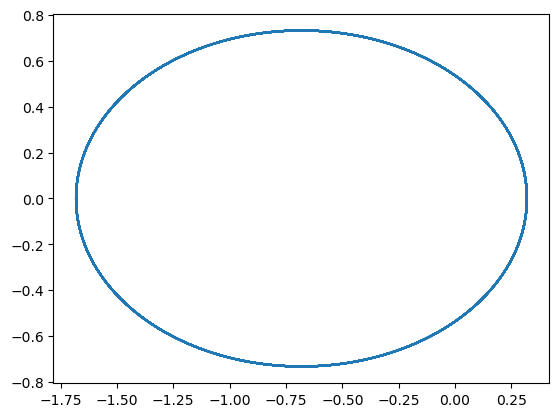

In [5]:
# iterate over dataset
for i, batch in enumerate(test):
    plt.plot(batch["states"][0][0,:], batch["states"][0][1,:]),
    break

In [3]:
def load_model(model_name,exp_name, data_path, model_phy_option, model_aug_option, dataset_name, integration_method, data_integration_method="RK4", dt_num=0.5, duration=40):
    """Compute trajectory losses and Fa loss for a given model, on its duration of training data."""
    # load test data 
    _, _, test = init_dataloaders(dataset_name, data_integration_method, os.path.join(data_path, dataset_name+str(duration)), dt_num=dt_num, duration=duration)

    # load model
    model_path = os.path.join(data_path, f"{exp_name}/{model_name}")
    print(model_path)
    with open(os.path.join(data_path, f'{exp_name}/hyperparameters.json'), 'r') as f:
        hyperparameters_dict = json.load(f)
    min_op = hyperparameters_dict['min_op']
    dt = hyperparameters_dict["dt"]
    dt_factor = int(dt/test.dataset.dt)
    print(dt, dt_factor)
    if dataset_name == 'pendulum':
        if model_phy_option == 'true': # true damped pendulum
            model_phy = PendulumParamPDE(is_damped=True, params=test.dataset.params, is_true=True)
        elif model_phy_option == 'complete': # damped pendulum
            model_phy = PendulumParamPDE(is_damped=True)
        else: 
            model_phy = PendulumParamPDE(is_damped=False)
    
        with open(model_path, "rb") as f:
            hyperparams = json.loads(f.readline().decode())
            mkey = jax.random.PRNGKey(0)
            model_aug = MLP(key=mkey, state_c=2, hidden=200)
            net = Forecaster(
                model_phy=model_phy,
                model_aug=model_aug,
                is_augmented=model_aug_option,
                is_phy=model_phy_option,
                dt=dt,
                num_steps=int(test.dataset.num_steps/dt_factor),
                integration_method=integration_method, # error scheme exp
            )
            model = eqx.tree_deserialise_leaves(f, net)
    elif dataset_name == "lorenz":
        model_phy = None # Neural ODE 
        with open(model_path, "rb") as f:
            hyperparams = json.loads(f.readline().decode())
            mkey, ikey = jax.random.split(jax.random.PRNGKey(0))
            model_aug = MLP(key=mkey, state_c=3, hidden=200)
            net = Forecaster(
                model_phy=model_phy,
                model_aug=model_aug,
                is_augmented=model_aug_option,
                is_phy=model_phy_option,
                dt=dt_factor * test.dataset.dt, # enabling comparison with GT for error scheme experiment 
                num_steps=int(test.dataset.num_steps / dt_factor), 
                integration_method=integration_method, # RK2 for error scheme experiment
            )
            model = eqx.tree_deserialise_leaves(f, net)

    elif dataset_name == "twobody":
        model_phy = None # Neural ODE 
        with open(model_path, "rb") as f:
            hyperparams = json.loads(f.readline().decode())
            mkey, ikey = jax.random.split(jax.random.PRNGKey(0))
            model_aug = MLP(key=mkey, state_c=4, hidden=200)
            net = Forecaster(
                model_phy=model_phy,
                model_aug=model_aug,
                is_augmented=model_aug_option,
                is_phy=model_phy_option,
                dt=dt_factor * test.dataset.dt, # enabling comparison with GT for error scheme experiment 
                num_steps=int(test.dataset.num_steps / dt_factor), 
                integration_method=integration_method, # RK2 for error scheme experiment
            )
            model = eqx.tree_deserialise_leaves(f, net)
    return model

In [4]:
from scipy.stats import entropy

def compute_metrics(data, dt):
    data["y_true"] = data["y_true"].apply(lambda x: np.array(x))
    data["y_pred"] = data["y_pred"].apply(lambda x: np.array(x))
    #data = compute_trajectories(F_model, y0_list, dt=0.5, t1=400)
    data["L2"] = data.apply(lambda x: np.mean(np.array((x["y_true"] - x["y_pred"])**2)), axis=1)
    data["L2_10s"] = data.apply(lambda x: np.mean(np.array((x["y_true"][:,:101] - x["y_pred"][:,:101])**2)), axis=1)
    data["L2_20s"] = data.apply(lambda x: np.mean(np.array((x["y_true"][:,:201] - x["y_pred"][:,:201])**2)), axis=1)
    data["L2_50s"] = data.apply(lambda x: np.mean(np.array((x["y_true"][:,:501] - x["y_pred"][:,:501])**2)), axis=1)

    # bins from true 
    data["x_min"] = data.apply(lambda x: np.min(x["y_true"][0]), axis=1)
    data["x_max"] = data.apply(lambda x: np.max(x["y_true"][0]), axis=1)
    data["y_min"] = data.apply(lambda x: np.min(x["y_true"][1]), axis=1)
    data["y_max"] = data.apply(lambda x: np.max(x["y_true"][1]), axis=1)
    # compute pdf
    data["x_pdf_true"] = data.apply(lambda x: np.histogram(x["y_true"][0], bins=50, range=(x["x_min"], x["x_max"]), density=True)[0], axis=1)
    data["x_pdf_pred"] = data.apply(lambda x: np.histogram(x["y_pred"][0], bins=50, range=(x["x_min"], x["x_max"]), density=True)[0], axis=1)
    data["y_pdf_true"] = data.apply(lambda x: np.histogram(x["y_true"][1], bins=50, range=(x["y_min"], x["y_max"]), density=True)[0], axis=1)
    data["y_pdf_pred"] = data.apply(lambda x: np.histogram(x["y_pred"][1], bins=50, range=(x["y_min"], x["y_max"]), density=True)[0], axis=1)
    # Add small epsilon to avoid log(0)
    epsilon = 1e-10
    for key in ["x_pdf_true", "x_pdf_pred", "y_pdf_true", "y_pdf_pred"]:
        data[key] = data[key].apply(lambda x: x + epsilon)

    # KL divergence
    data["KL_x"] = data.apply(lambda x: entropy(x["x_pdf_true"], x["x_pdf_pred"]), axis=1)
    data["KL_y"] = data.apply(lambda x: entropy(x["y_pdf_true"], x["y_pdf_pred"]), axis=1)

    return data

## Load models

In [7]:
### DEPRECATED twobody_curriculum_dt0.1 : too big for good GT
# path_none_aug1 = '/Users/mayajanvier/jax-phynity/data/twobody_curriculum/none_aug_1_5_sqjjkugz/model_8.666e-06_longrun_100.json'
# path_none_aug5 = '/Users/mayajanvier/jax-phynity/data/twobody_curriculum/none_aug_5_9_nn7jwd9d/model_1.873e-04_longrun_100.json'
# path_none_aug10 = '/Users/mayajanvier/jax-phynity/data/twobody_curriculum/none_aug_10_12_vfm4hxed/model_7.667e-04_longrun_100.json'

# path_lipsupX5_l1 = '/Users/mayajanvier/jax-phynity/data/twobody_curriculum/none_Fa_prime_supX_aug_5_13_eqe5cguq/model_8.838e-03_longrun_100.json'


In [8]:
### DEPRECATED twobody_curriculum_dt0.1 : too big for good GT
# results_none_aug1 = pd.read_json(path_none_aug1).T 
# results_none_aug5 = pd.read_json(path_none_aug5).T
# results_none_aug10 = pd.read_json(path_none_aug10).T
# results_lipsupX5_l1 = pd.read_json(path_lipsupX5_l1).T
# results_lipsupX5_l1["y_pred"] = results_lipsupX5_l1["y_pred"].apply(lambda x: np.array(x))
# results_lipsupX5_l1["y_true"] = results_lipsupX5_l1["y_true"].apply(lambda x: np.array(x))

In [5]:
# none aug
path_none_aug1 = "/Users/mayajanvier/jax-phynity/data/twobody_curriculum/none_aug_1.0_1_gn2n5qyl/model_1.410e-05_longrun_100.json"
path_none_aug5 = "/Users/mayajanvier/jax-phynity/data/twobody_curriculum/none_aug_5.0_8_lx1pq403/model_1.150e-04_longrun_100.json"
path_none_aug5_nocurr = "/Users/mayajanvier/jax-phynity/data/twobody_curriculum/none_aug_5.0_9_zg4ol5lo/model_4.262e-05_longrun_100.json"
path_none_aug10 = "/Users/mayajanvier/jax-phynity/data/twobody_curriculum/none_aug_10.0_14_4l85q0jy/model_5.856e-04_longrun_100.json"
path_none_aug10_nocurr = "/Users/mayajanvier/jax-phynity/data/twobody_curriculum/none_aug_10.0_13_md9btd50/model_3.659e-04_longrun_100.json"
path_none_aug03 = "/Users/mayajanvier/jax-phynity/data/twobody_curriculum/none_aug_0.3_19_mckyyoty/model_9.967e-04_longrun_100.json"
path_none_aug20_nocurr = "/Users/mayajanvier/jax-phynity/data/twobody_curriculum/none_aug_20.0_23_4p236z0x/model_9.428e-04_longrun_100.json"
path_none_aug1_epoch = "/Users/mayajanvier/jax-phynity/data/twobody_curriculum/none_aug_1.0_31_ei2hve4t/model_2.907e-06_longrun_100.json"

# lipsup 5 
path_lipsupX_5_l1 = "/Users/mayajanvier/jax-phynity/data/twobody_curriculum/none_Fa_prime_supX_aug_5.0_23_w2p03e19/model_9.676e-03_longrun_100.json"
path_lipsupX_5_l100 = "/Users/mayajanvier/jax-phynity/data/twobody_curriculum/none_Fa_prime_supX_aug_5.0_24_pti1raje/model_6.825e-04_longrun_100.json"
path_lipsupX_5_l1000 = "/Users/mayajanvier/jax-phynity/data/twobody_curriculum/none_Fa_prime_supX_aug_5.0_43_tu0v8iai/model_5.106e-05_longrun_100.json"
path_lipsupX_5_l10tau10 = "/Users/mayajanvier/jax-phynity/data/twobody_curriculum/none_Fa_prime_supX_aug_5.0_25_x7erzvcp/model_1.068e-03_longrun_100.json"
path_lipsupX_5_l100_norm = "/Users/mayajanvier/jax-phynity/data/twobody_curriculum/none_Fa_prime_supX_aug_5.0_26_yck8cpdv/model_4.033e-05_longrun_100.json"
path_lipsupX_5_l1000_norm = "/Users/mayajanvier/jax-phynity/data/twobody_curriculum/none_Fa_prime_supX_aug_5.0_45_m6ot7e30/model_4.532e-05_longrun_100.json"
path_lipsupX_5_l10_norm = "/Users/mayajanvier/jax-phynity/data/twobody_curriculum/none_Fa_prime_supX_aug_5.0_46_go438o3a/model_3.241e-04_longrun_100.json"
parg_lipsupX_5_l500_norm = "/Users/mayajanvier/jax-phynity/data/twobody_curriculum/none_Fa_prime_supX_aug_5.0_47_19kcpwiz/model_5.000e-05_longrun_100.json"
path_lipsupX_5_l50t50_norm = "/Users/mayajanvier/jax-phynity/data/twobody_curriculum/none_Fa_prime_supX_aug_5.0_48_qw0xsvvz/model_4.078e-05_longrun_100.json"
path_lipsipX_5_l200_norm = "/Users/mayajanvier/jax-phynity/data/twobody_curriculum/none_Fa_prime_supX_aug_5.0_49_ed0givge/model_5.878e-05_longrun_100.json"
path_lipsupX_5_l50_norm = "/Users/mayajanvier/jax-phynity/data/twobody_curriculum/none_Fa_prime_supX_aug_5.0_50_3bid901x/model_6.098e-05_longrun_100.json"
# lipsup 1
path_lipsupX_1_l100_norm = "/Users/mayajanvier/jax-phynity/data/twobody_curriculum/none_Fa_prime_supX_aug_1.0_27_osd1rx3f/model_3.539e-05_longrun_100.json"
path_lipsupX_1_l1000_norm = "/Users/mayajanvier/jax-phynity/data/twobody_curriculum/none_Fa_prime_supX_aug_1.0_28_cqrzsk0g/model_1.205e-05_longrun_100.json"
path_lipsupX_1_l1_norm ="/Users/mayajanvier/jax-phynity/data/twobody_curriculum/none_Fa_prime_supX_aug_1.0_29_iy9gkzex/model_5.705e-03_longrun_100.json"
path_lipsupX_1_l10_norm = "/Users/mayajanvier/jax-phynity/data/twobody_curriculum/none_Fa_prime_supX_aug_1.0_30_rndrxk7q/model_1.120e-03_longrun_100.json"
path_lipsupX_1_l10_t1_norm = "/Users/mayajanvier/jax-phynity/data/twobody_curriculum/none_Fa_prime_supX_aug_1.0_33_hve7onu4/model_9.140e-04_longrun_100.json"
path_lipsupX_1_l10_t10_norm ="/Users/mayajanvier/jax-phynity/data/twobody_curriculum/none_Fa_prime_supX_aug_1.0_34_yuyva9d2/model_4.005e-05_longrun_100.json"
path_lipsupX_1_l1_t1_norm = "/Users/mayajanvier/jax-phynity/data/twobody_curriculum/none_Fa_prime_supX_aug_1.0_35_a9o3jkt6/model_2.461e-03_longrun_100.json"
path_lipsupX_1_l10_t05_norm = "/Users/mayajanvier/jax-phynity/data/twobody_curriculum/none_Fa_prime_supX_aug_1.0_36_9jmealsq/model_2.270e-04_longrun_100.json"
path_lipsupX_1_l10_t2_norm = "/Users/mayajanvier/jax-phynity/data/twobody_curriculum/none_Fa_prime_supX_aug_1.0_37_ycunk46w/model_8.357e-04_longrun_100.json"
path_lipsupX_1_l10_t1_norm_epoch = "/Users/mayajanvier/jax-phynity/data/twobody_curriculum/none_Fa_prime_supX_aug_1.0_38_wqqdmftn/model_6.877e-04_longrun_100.json"
path_lipsupX_1_l10_t1000_norm = "/Users/mayajanvier/jax-phynity/data/twobody_curriculum/none_Fa_prime_supX_aug_1.0_52_vlz7a4du/model_4.465e-06_longrun_100.json"

path_none_aug1_init = "/Users/mayajanvier/jax-phynity/data/twobody/none_aug_1.0_1_vco0t1ky/model_6.189e-05_longrun_100.json"
path_none_aug03_init = "/Users/mayajanvier/jax-phynity/data/twobody/none_aug_0.3_8_br8vy6m9/model_9.144e-05_longrun_100.json"
path_lipsupX03_l10_init = "/Users/mayajanvier/jax-phynity/data/twobody/none_Fa_prime_supX_aug_0.3_9_hjaxy1y3/model_2.050e-02_longrun_100.json"
path_lipsupX03_l1000_init ="/Users/mayajanvier/jax-phynity/data/twobody/none_Fa_prime_supX_aug_0.3_10_v32xtk8o/model_1.199e-03_longrun_100.json"
path_lipsupX03_l10t10_init = "/Users/mayajanvier/jax-phynity/data/twobody/none_Fa_prime_supX_aug_0.3_11_qh6kzsmh/model_1.085e-02_longrun_100.json"
path_lipsupX03_l100_t100_init = "/Users/mayajanvier/jax-phynity/data/twobody/none_Fa_prime_supX_aug_0.3_12_qnzpukes/model_4.957e-03_longrun_100.json"
path_lipsupX03_l1000t10_init = "/Users/mayajanvier/jax-phynity/data/twobody/none_Fa_prime_supX_aug_0.3_13_26qtxb42/model_1.173e-03_longrun_100.json"
path_lipsupX03_l100000_init = "/Users/mayajanvier/jax-phynity/data/twobody/none_Fa_prime_supX_aug_0.3_14_uac56789/model_1.207e-04_longrun_100.json"
path_lipsupX03_l100_init = "/Users/mayajanvier/jax-phynity/data/twobody/none_Fa_prime_supX_aug_0.3_15_k3248ahe/model_7.377e-03_longrun_100.json"
path_lipsupX1_l100_init = "/Users/mayajanvier/jax-phynity/data/twobody/none_Fa_prime_supX_aug_1_19_qyopf9iy/model_2.596e-04_longrun_100.json"
path_lipsupX1_l10000_init = "/Users/mayajanvier/jax-phynity/data/twobody/none_Fa_prime_supX_aug_1_20_0hg4zbjz/model_2.334e-05_longrun_100.json"

In [10]:
results_none_aug1 = pd.read_json(path_none_aug1).T
results_none_aug5 = pd.read_json(path_none_aug5).T
results_none_aug5_nocurr = pd.read_json(path_none_aug5_nocurr).T
results_none_aug10 = pd.read_json(path_none_aug10).T
results_none_aug10_nocurr = pd.read_json(path_none_aug10_nocurr).T
results_none_aug03 = pd.read_json(path_none_aug03).T
results_none_aug20_nocurr = pd.read_json(path_none_aug20_nocurr).T
results_lipsupX_5_l1 = pd.read_json(path_lipsupX_5_l1).T
results_lipsupX_5_l100 = pd.read_json(path_lipsupX_5_l100).T
results_lipsupX_5_l10tau10 = pd.read_json(path_lipsupX_5_l10tau10).T
results_lipsupX_5_l100_norm = pd.read_json(path_lipsupX_5_l100_norm).T
results_lipsupX_1_l100_norm = pd.read_json(path_lipsupX_1_l100_norm).T
results_lipsupX_1_l1000_norm = pd.read_json(path_lipsupX_1_l1000_norm).T
results_lipsipX_1_l1_norm = pd.read_json(path_lipsupX_1_l1_norm).T
results_lipsupX_1_l10_norm = pd.read_json(path_lipsupX_1_l10_norm).T
results_lipsupX_1_l10t1_norm  =pd.read_json(path_lipsupX_1_l10_t1_norm).T
results_lipsupX_1_l10t10_norm = pd.read_json(path_lipsupX_1_l10_t10_norm).T
results_lipsupX_1_l1t1_norm = pd.read_json(path_lipsupX_1_l1_t1_norm).T

In [11]:
results_none_aug1_epoch = pd.read_json(path_none_aug1_epoch).T
results_lipsupX_1_l10t05_norm = pd.read_json(path_lipsupX_1_l10_t05_norm).T
results_lipsupX_1_l10t2_norm = pd.read_json(path_lipsupX_1_l10_t2_norm).T
results_lipsupX_1_l10t1_norm_epoch = pd.read_json(path_lipsupX_1_l10_t1_norm).T
results_none_aug1_init = pd.read_json(path_none_aug1_init).T
results_none_aug03_init = pd.read_json(path_none_aug03_init).T
results_lipsupX03_l10_init = pd.read_json(path_lipsupX03_l10_init).T
results_lipsupX03_l1000_init = pd.read_json(path_lipsupX03_l1000_init).T
results_lipsupX03_l10t10_init = pd.read_json(path_lipsupX03_l10t10_init).T
results_lipsupX03_l100t100_init = pd.read_json(path_lipsupX03_l100_t100_init).T
results_lipsupX03_l1000t10_init = pd.read_json(path_lipsupX03_l1000t10_init).T
results_lipsupX03_l100000_init = pd.read_json(path_lipsupX03_l100000_init).T
results_lipsupX03_l100_init = pd.read_json(path_lipsupX03_l100_init).T
results_lipsupX1_l100_init = pd.read_json(path_lipsupX1_l100_init).T

In [12]:
results_lipsupX1_l10000_init = pd.read_json(path_lipsupX1_l10000_init).T
results_lipsupX5_l1000 = pd.read_json(path_lipsupX_5_l1000).T
results_lipsupX5_l1000_norm = pd.read_json(path_lipsupX_5_l1000_norm).T
results_lipsupX5_l10_norm = pd.read_json(path_lipsupX_5_l10_norm).T
results_lipsupX5_l500_norm = pd.read_json(parg_lipsupX_5_l500_norm).T   
results_lipsupX5_l50t50_norm = pd.read_json(path_lipsupX_5_l50t50_norm).T
results_lipsupX5_l200_norm = pd.read_json(path_lipsipX_5_l200_norm).T
results_lipsupX5_l50_norm = pd.read_json(path_lipsupX_5_l50_norm).T
results_lipsupX1_l10t1000_norm = pd.read_json(path_lipsupX_1_l10_t1000_norm).T

In [13]:
data_none_aug1 = compute_metrics(results_none_aug1, dt=0.1)
data_none_aug5 = compute_metrics(results_none_aug5, dt=0.1)
data_none_aug5_nocurr = compute_metrics(results_none_aug5_nocurr, dt=0.1)
data_none_aug10 = compute_metrics(results_none_aug10, dt=0.1)
data_none_aug10_nocurr = compute_metrics(results_none_aug10_nocurr, dt=0.1)
data_none_aug03 = compute_metrics(results_none_aug03, dt=0.1)
data_none_aug20_nocurr = compute_metrics(results_none_aug20_nocurr, dt=0.1)
data_lipsupX5_l1 = compute_metrics(results_lipsupX_5_l1, dt=0.1)
data_lipsupX5_l100 = compute_metrics(results_lipsupX_5_l100, dt=0.1)
data_lipsupX5_l10tau10 = compute_metrics(results_lipsupX_5_l10tau10, dt=0.1)
data_lipsupX5_l100_norm = compute_metrics(results_lipsupX_5_l100_norm, dt=0.1)
data_lipsupX1_l100_norm = compute_metrics(results_lipsupX_1_l100_norm, dt=0.1)
data_lipsupX1_l1000_norm = compute_metrics(results_lipsupX_1_l1000_norm, dt=0.1)
data_lipsupX1_l1_norm = compute_metrics(results_lipsipX_1_l1_norm, dt=0.1)
data_lipsupX1_l10_norm = compute_metrics(results_lipsupX_1_l10_norm, dt=0.1)
data_lipsupX1_l10t1_norm = compute_metrics(results_lipsupX_1_l10t1_norm, dt=0.1)
data_lipsupX1_l10t10_norm = compute_metrics(results_lipsupX_1_l10t10_norm, dt=0.1)
data_none_aug1_epoch = compute_metrics(results_none_aug1_epoch, dt=0.1)
data_lipsupX1_l1t1_norm = compute_metrics(results_lipsipX_1_l1_norm, dt=0.1)
data_lipsupX1_l10t05_norm = compute_metrics(results_lipsupX_1_l10t05_norm, dt=0.1)
data_lipsupX1_l10t2_norm = compute_metrics(results_lipsupX_1_l10t2_norm, dt=0.1)
data_lipsupX1_l10t1_norm_epoch = compute_metrics(results_lipsupX_1_l10t1_norm_epoch, dt=0.1)

# init variees 
data_none_aug1_init = compute_metrics(results_none_aug1_init, dt=0.1)
data_none_aug03_init = compute_metrics(results_none_aug03_init, dt=0.1)
data_lipsupX03_l10_init = compute_metrics(results_lipsupX03_l10_init, dt=0.1)
data_lipsupX03_l1000_init = compute_metrics(results_lipsupX03_l1000_init, dt=0.1)
data_lipsupX03_l10t10_init = compute_metrics(results_lipsupX03_l10t10_init, dt=0.1)
data_lipsupX03_l100t100_init = compute_metrics(results_lipsupX03_l100t100_init, dt=0.1)
data_lipsupX03_l1000t10_init = compute_metrics(results_lipsupX03_l1000t10_init, dt=0.1)
data_lipsupX03_l100000_init = compute_metrics(results_lipsupX03_l100000_init, dt=0.1)
data_lipsupX03_l100_init = compute_metrics(results_lipsupX03_l100_init, dt=0.1)
data_lipsupX1_l100_init = compute_metrics(results_lipsupX1_l100_init, dt=0.1)
data_lipsupX1_l10000_init = compute_metrics(results_lipsupX1_l10000_init, dt=0.1)
data_lipsupX5_l1000 = compute_metrics(results_lipsupX5_l1000, dt=0.1)
data_lipsupX5_l1000_norm = compute_metrics(results_lipsupX5_l1000_norm, dt=0.1)
data_lipsupX5_l10_norm = compute_metrics(results_lipsupX5_l10_norm, dt=0.1)
data_lipsupX5_l500_norm = compute_metrics(results_lipsupX5_l500_norm, dt=0.1)
data_lipsupX5_l50t50_norm = compute_metrics(results_lipsupX5_l50t50_norm, dt=0.1)
data_lipsupX5_l200_norm = compute_metrics(results_lipsupX5_l200_norm, dt=0.1)

In [22]:
data_lipsupX5_l50_norm = compute_metrics(results_lipsupX5_l50_norm, dt=0.1)
data_lipsupX1_l10t1000_norm = compute_metrics(results_lipsupX1_l10t1000_norm, dt=0.1)

In [14]:
# models
data_path = "data/twobody_curriculum"
model_none_aug03 = load_model("model_9.967e-04.eqx", "none_aug_0.3_19_mckyyoty", data_path, "none", True, "twobody", "RK4", "RK4", dt_num=0.01, duration=100)
model_none_aug1 = load_model("model_1.410e-05.eqx", "none_aug_1.0_1_gn2n5qyl", data_path, "none", True, "twobody", "RK4", "RK4", dt_num=0.01, duration=100)
model_none_aug5_nocurr = load_model("model_4.262e-05.eqx", "none_aug_5.0_9_zg4ol5lo", data_path, "none", True, "twobody", "RK4", "RK4", dt_num=0.01, duration=100)
model_none_aug10_nocurr = load_model("model_3.659e-04.eqx", "none_aug_10.0_13_md9btd50", data_path, "none", True, "twobody", "RK4", "RK4", dt_num=0.01, duration=100)
model_lipsupX5_l100 = load_model("model_6.825e-04.eqx", "none_Fa_prime_supX_aug_5.0_24_pti1raje", data_path, "none", True, "twobody", "RK4", "RK4", dt_num=0.01, duration=100)
model_none_aug20_nocurr =load_model("model_9.428e-04.eqx", "none_aug_20.0_23_4p236z0x", data_path, "none", True, "twobody", "RK4", "RK4", dt_num=0.01, duration=100)
model_lipsupX5_l100_norm = load_model("model_4.033e-05.eqx", "none_Fa_prime_supX_aug_5.0_26_yck8cpdv", data_path, "none", True, "twobody", "RK4", "RK4", dt_num=0.01, duration=100)
model_lipsupX1_l100_norm = load_model("model_3.539e-05.eqx", "none_Fa_prime_supX_aug_1.0_27_osd1rx3f", data_path, "none", True, "twobody", "RK4", "RK4", dt_num=0.01, duration=100)
model_lipsupX1_l1000_norm = load_model("model_1.205e-05.eqx", "none_Fa_prime_supX_aug_1.0_28_cqrzsk0g", data_path, "none", True, "twobody", "RK4", "RK4", dt_num=0.01, duration=100)
model_lipsupX1_l1_norm = load_model("model_5.705e-03.eqx", "none_Fa_prime_supX_aug_1.0_29_iy9gkzex", data_path, "none", True, "twobody", "RK4", "RK4", dt_num=0.01, duration=100)
model_lipsupX1_l10_norm = load_model("model_1.120e-03.eqx", "none_Fa_prime_supX_aug_1.0_30_rndrxk7q", data_path, "none", True, "twobody", "RK4", "RK4", dt_num=0.01, duration=100)
model_lipsupX1_l10t1_norm = load_model("model_9.140e-04.eqx", "none_Fa_prime_supX_aug_1.0_33_hve7onu4", data_path, "none", True, "twobody", "RK4", "RK4", dt_num=0.01, duration=100)
model_none_aug1_epoch = load_model("model_2.907e-06.eqx", "none_aug_1.0_31_ei2hve4t", data_path, "none", True, "twobody", "RK4", "RK4", dt_num=0.01, duration=100)
model_lipsupX1_l1t1_norm = load_model("model_2.461e-03.eqx", "none_Fa_prime_supX_aug_1.0_35_a9o3jkt6", data_path, "none", True, "twobody", "RK4", "RK4", dt_num=0.01, duration=100)
model_lipsupX1_l10t05_norm = load_model("model_2.270e-04.eqx", "none_Fa_prime_supX_aug_1.0_36_9jmealsq", data_path, "none", True, "twobody", "RK4", "RK4", dt_num=0.01, duration=100)
model_lipsupX1_l10t2_norm = load_model("model_8.357e-04.eqx", "none_Fa_prime_supX_aug_1.0_37_ycunk46w", data_path, "none", True, "twobody", "RK4", "RK4", dt_num=0.01, duration=100)
model_lipsupX1_l10t1_norm_epoch = load_model("model_6.877e-04.eqx", "none_Fa_prime_supX_aug_1.0_38_wqqdmftn", data_path, "none", True, "twobody", "RK4", "RK4", dt_num=0.01, duration=100)
model_lipsupX5_l10_norm  = load_model("model_3.241e-04.eqx", "none_Fa_prime_supX_aug_5.0_46_go438o3a", data_path, "none", True, "twobody", "RK4", "RK4", dt_num=0.01, duration=100)
model_lipsupX5_l500_norm = load_model("model_5.000e-05.eqx", "none_Fa_prime_supX_aug_5.0_47_19kcpwiz", data_path, "none", True, "twobody", "RK4", "RK4", dt_num=0.01, duration=100)
model_lipsupX5_l50t50_norm = load_model("model_4.078e-05.eqx", "none_Fa_prime_supX_aug_5.0_48_qw0xsvvz", data_path, "none", True, "twobody", "RK4", "RK4", dt_num=0.01, duration=100)

data/twobody_curriculum/none_aug_0.3_19_mckyyoty/model_9.967e-04.eqx
0.1 10
data/twobody_curriculum/none_aug_1.0_1_gn2n5qyl/model_1.410e-05.eqx
0.1 10
data/twobody_curriculum/none_aug_5.0_9_zg4ol5lo/model_4.262e-05.eqx
0.1 10
data/twobody_curriculum/none_aug_10.0_13_md9btd50/model_3.659e-04.eqx
0.1 10
data/twobody_curriculum/none_Fa_prime_supX_aug_5.0_24_pti1raje/model_6.825e-04.eqx
0.1 10
data/twobody_curriculum/none_aug_20.0_23_4p236z0x/model_9.428e-04.eqx
0.1 10
data/twobody_curriculum/none_Fa_prime_supX_aug_5.0_26_yck8cpdv/model_4.033e-05.eqx
0.1 10
data/twobody_curriculum/none_Fa_prime_supX_aug_1.0_27_osd1rx3f/model_3.539e-05.eqx
0.1 10
data/twobody_curriculum/none_Fa_prime_supX_aug_1.0_28_cqrzsk0g/model_1.205e-05.eqx
0.1 10
data/twobody_curriculum/none_Fa_prime_supX_aug_1.0_29_iy9gkzex/model_5.705e-03.eqx
0.1 10
data/twobody_curriculum/none_Fa_prime_supX_aug_1.0_30_rndrxk7q/model_1.120e-03.eqx
0.1 10
data/twobody_curriculum/none_Fa_prime_supX_aug_1.0_33_hve7onu4/model_9.140e-04.e

In [15]:
data_path_init = "data/twobody"
model_none_aug1_init = load_model("model_6.189e-05.eqx", "none_aug_1.0_1_vco0t1ky", data_path_init, "none", True, "twobody", "RK4", "RK4", dt_num=0.01, duration=100)
model_none_aug03_init = load_model("model_9.144e-05.eqx", "none_aug_0.3_8_br8vy6m9", data_path_init, "none", True, "twobody", "RK4", "RK4", dt_num=0.01, duration=100)
model_lipsupX03_l10_init = load_model("model_2.050e-02.eqx", "none_Fa_prime_supX_aug_0.3_9_hjaxy1y3", data_path_init, "none", True, "twobody", "RK4", "RK4", dt_num=0.01, duration=100)
model_lipsupX03_l1000_init = load_model("model_1.199e-03.eqx", "none_Fa_prime_supX_aug_0.3_10_v32xtk8o", data_path_init, "none", True, "twobody", "RK4", "RK4", dt_num=0.01, duration=100)
model_lipsupX03_l10t0_init = load_model("model_1.085e-02.eqx", "none_Fa_prime_supX_aug_0.3_11_qh6kzsmh", data_path_init, "none", True, "twobody", "RK4", "RK4", dt_num=0.01, duration=100)
model_lipsupX03_l100t00_init = load_model("model_4.957e-03.eqx", "none_Fa_prime_supX_aug_0.3_12_qnzpukes", data_path_init, "none", True, "twobody", "RK4", "RK4", dt_num=0.01, duration=100)
model_lipsupX03_l100000_init = load_model("model_1.207e-04.eqx", "none_Fa_prime_supX_aug_0.3_14_uac56789", data_path_init, "none", True, "twobody", "RK4", "RK4", dt_num=0.01, duration=100)
model_lipsupX03_l100_init = load_model("model_7.377e-03.eqx", "none_Fa_prime_supX_aug_0.3_15_k3248ahe", data_path_init, "none", True, "twobody", "RK4", "RK4", dt_num=0.01, duration=100)


data/twobody/none_aug_1.0_1_vco0t1ky/model_6.189e-05.eqx
0.1 10
data/twobody/none_aug_0.3_8_br8vy6m9/model_9.144e-05.eqx
0.1 10
data/twobody/none_Fa_prime_supX_aug_0.3_9_hjaxy1y3/model_2.050e-02.eqx
0.1 10
data/twobody/none_Fa_prime_supX_aug_0.3_10_v32xtk8o/model_1.199e-03.eqx
0.1 10
data/twobody/none_Fa_prime_supX_aug_0.3_11_qh6kzsmh/model_1.085e-02.eqx
0.1 10
data/twobody/none_Fa_prime_supX_aug_0.3_12_qnzpukes/model_4.957e-03.eqx
0.1 10
data/twobody/none_Fa_prime_supX_aug_0.3_14_uac56789/model_1.207e-04.eqx
0.1 10
data/twobody/none_Fa_prime_supX_aug_0.3_15_k3248ahe/model_7.377e-03.eqx
0.1 10


## Trajectories


### Restricted learning domain (close init points)

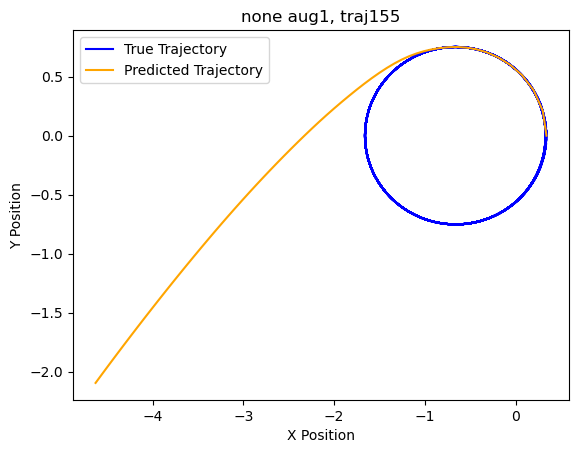

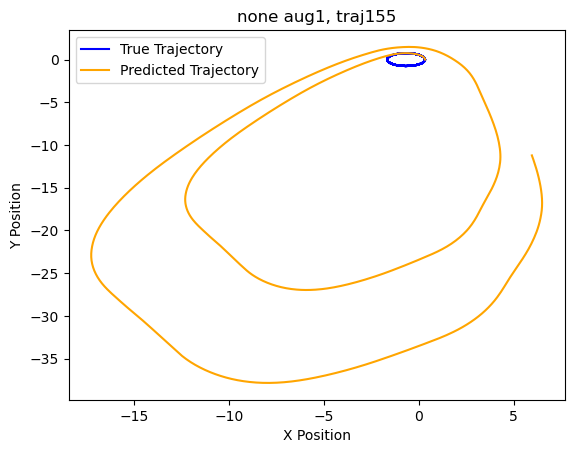

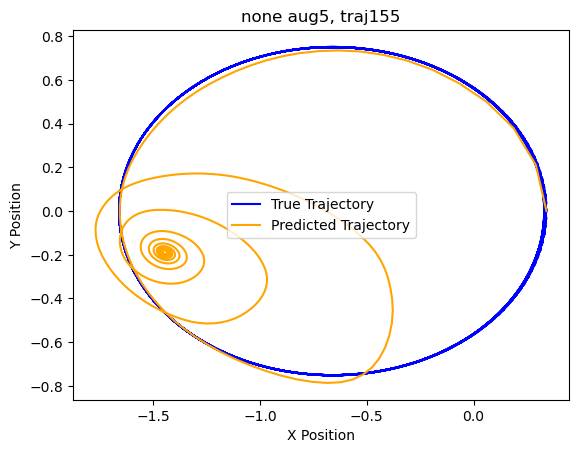

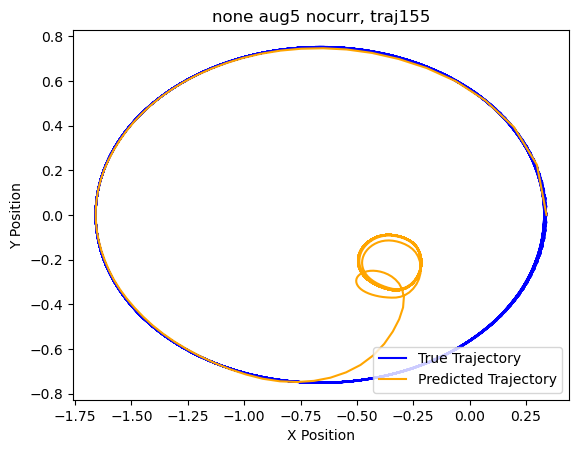

In [58]:
k=155
plot_trajectory(data_none_aug1["y_true"][k], data_none_aug1["y_pred"][k][:,:int(1/0.1)+50], title=f"none aug1, traj{k}")
plt.figure()
plot_trajectory(data_none_aug1["y_true"][k], data_none_aug1["y_pred"][k][:,:], title=f"none aug1, traj{k}")
plt.figure()
plot_trajectory(data_none_aug5["y_true"][k], data_none_aug5["y_pred"][k][:,:], title=f"none aug5, traj{k}")
plt.figure()
plot_trajectory(data_none_aug5_nocurr["y_true"][k], data_none_aug5_nocurr["y_pred"][k][:,:], title=f"none aug5 nocurr, traj{k}")

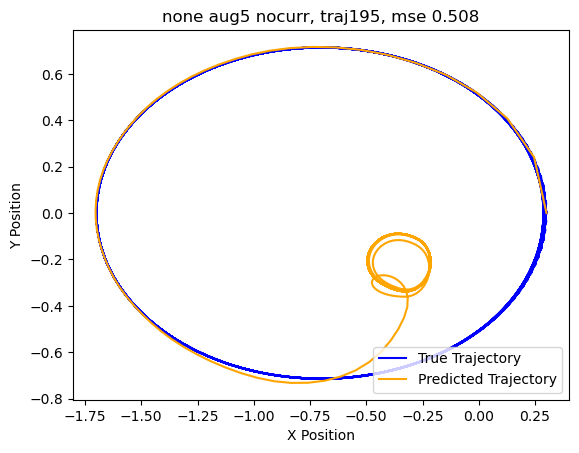

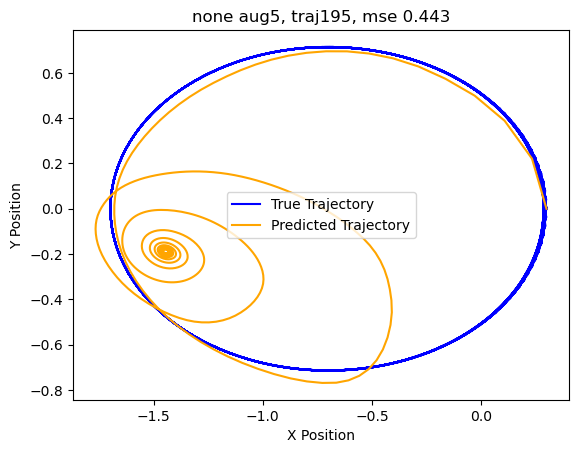

In [70]:
k=data_none_aug5_nocurr["L2"].idxmax()
plot_trajectory(data_none_aug5_nocurr["y_true"][k], data_none_aug5_nocurr["y_pred"][k][:,:], title=f"none aug5 nocurr, traj{k}, mse {data_none_aug5_nocurr['L2'][k]:.3f}")
plt.figure()
plot_trajectory(data_none_aug5["y_true"][k], data_none_aug5["y_pred"][k][:,:], title=f"none aug5, traj{k}, mse {data_none_aug5['L2'][k]:.3f}")


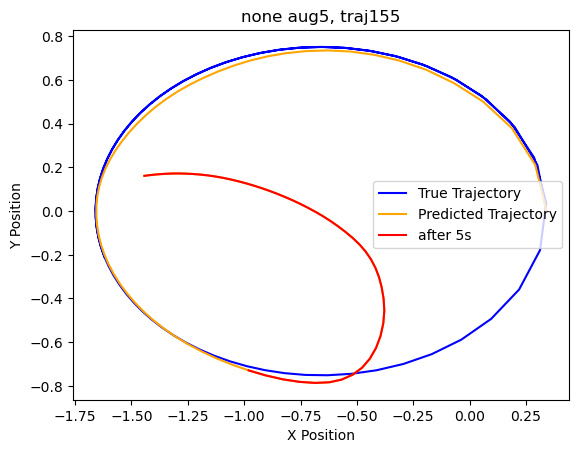

In [54]:
plot_trajectory(data_none_aug5["y_true"][k][:,:int(5/0.1)+50], data_none_aug5["y_pred"][k][:,:int(5/0.1)+50], title=f"none aug5, traj{k}")
plt.plot(data_none_aug5["y_pred"][k][0,int(5/0.1):int(5/0.1)+50],data_none_aug5["y_pred"][k][1,int(5/0.1):int(5/0.1)+50], label="after 5s", color="red")
plt.legend()

#### Converging: after seeing one period

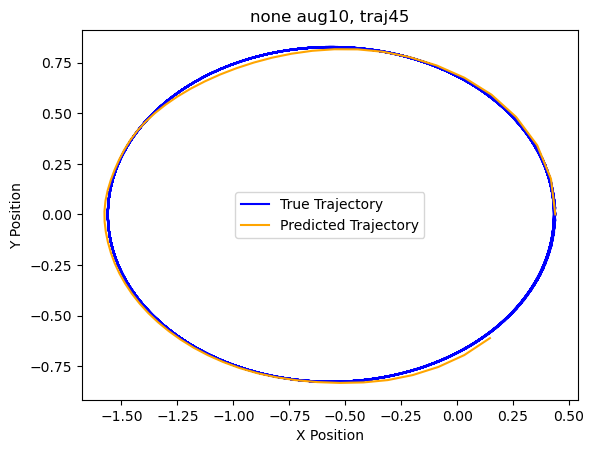

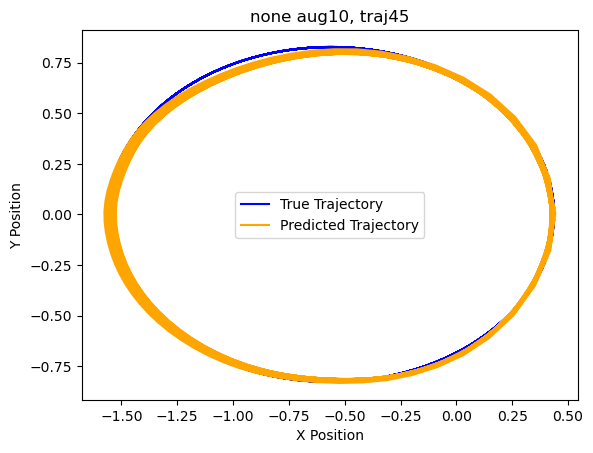

In [20]:
k=45
plot_trajectory(data_none_aug10_nocurr["y_true"][k], data_none_aug10_nocurr["y_pred"][k][:,:int(1/0.1)+50], title=f"none aug10, traj{k}")
plt.figure()
plot_trajectory(data_none_aug10_nocurr["y_true"][k], data_none_aug10_nocurr["y_pred"][k][:,:], title=f"none aug10, traj{k}")

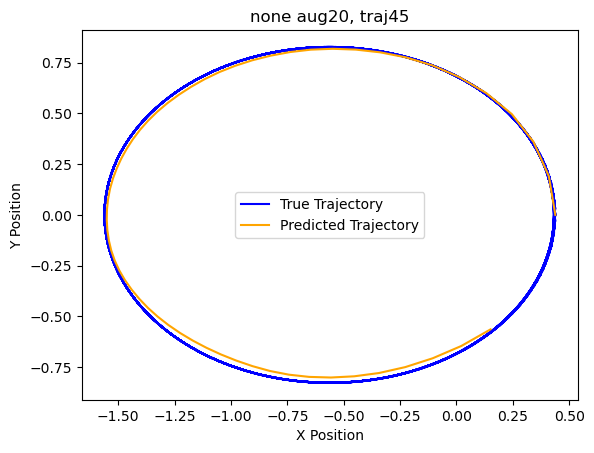

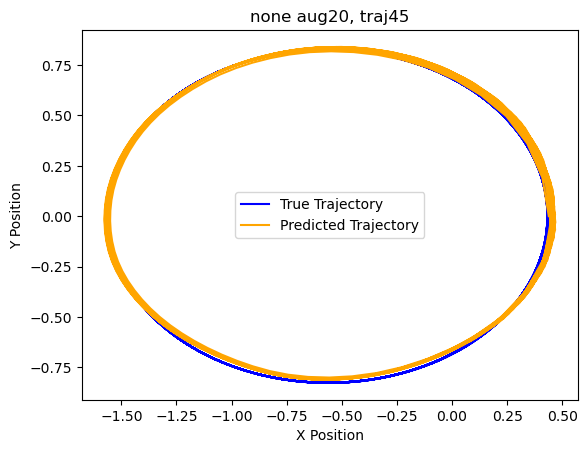

In [21]:
k=45
plot_trajectory(data_none_aug20_nocurr["y_true"][k], data_none_aug20_nocurr["y_pred"][k][:,:int(1/0.1)+50], title=f"none aug20, traj{k}")
plt.figure()
plot_trajectory(data_none_aug20_nocurr["y_true"][k], data_none_aug20_nocurr["y_pred"][k][:,:], title=f"none aug20, traj{k}")

#### Diverging: offline regime 

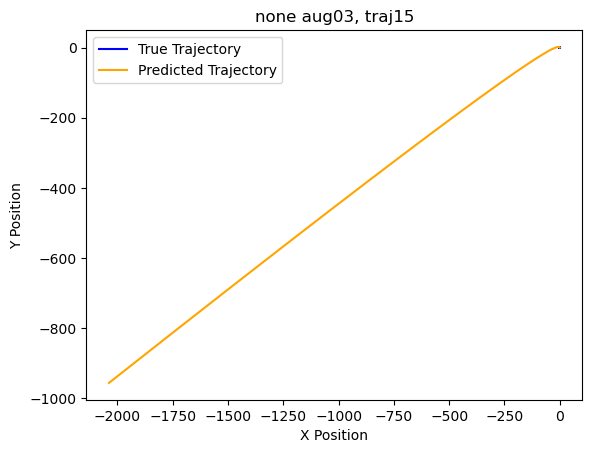

In [110]:
plot_trajectory(data_none_aug03["y_true"][k], data_none_aug03["y_pred"][k], title=f"none aug03, traj{k}")

Text(0.5, 1.0, 'State L2 error over time')

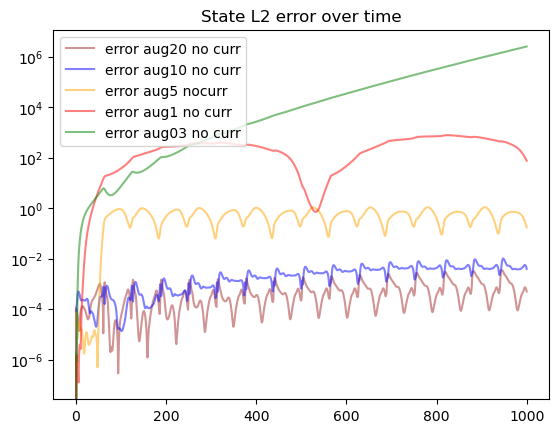

In [12]:
k=15
plt.plot(((data_none_aug20_nocurr["y_true"][k][:2]-data_none_aug20_nocurr["y_pred"][k][:2])**2).mean(axis=0), label="error aug20 no curr", color="brown", alpha=0.5)
plt.plot(((data_none_aug10_nocurr["y_true"][k][:2]-data_none_aug10_nocurr["y_pred"][k][:2])**2).mean(axis=0), label="error aug10 no curr", color="blue", alpha=0.5)
#plt.plot(((data_none_aug10["y_true"][k][:2]-data_none_aug10["y_pred"][k][:2])**2).mean(axis=0), label="error aug10 curr", color="blue", linestyle='dashed')
#plt.plot(((data_none_aug5["y_true"][k][:2]-data_none_aug5["y_pred"][k][:2])**2).mean(axis=0), label="error aug5", color="orange", linestyle='dashed')
plt.plot(((data_none_aug5_nocurr["y_true"][k][:2]-data_none_aug5_nocurr["y_pred"][k][:2])**2).mean(axis=0), label="error aug5 nocurr", color="orange", alpha=0.5)
# 1s
plt.plot(((data_none_aug1["y_true"][k][:2]-data_none_aug1["y_pred"][k][:2])**2).mean(axis=0), label="error aug1 no curr", color="red", alpha=0.5)
# 3 steps (offline)
plt.plot(((data_none_aug03["y_true"][k][:2]-data_none_aug03["y_pred"][k][:2])**2).mean(axis=0), label="error aug03 no curr", color="green", alpha=0.5)
plt.yscale('log')
plt.legend()
plt.title("State L2 error over time")

Text(0.5, 1.0, 'Trajectories of different models')

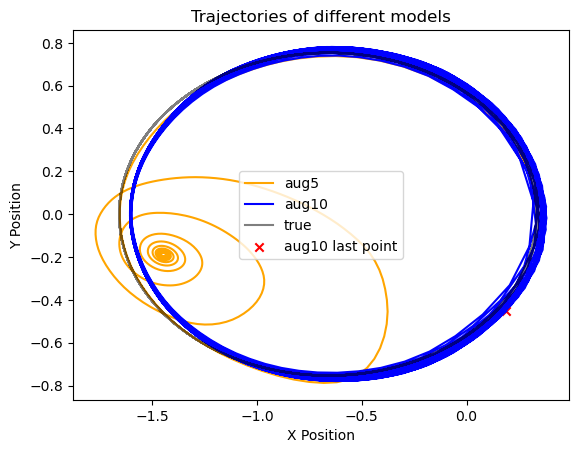

In [122]:
#plt.plot(data_none_aug03["y_pred"][k][0,:200], data_none_aug03["y_pred"][k][1,:200], label="aug03", color="green")
#plt.plot(data_none_aug1["y_pred"][k][0,:200], data_none_aug1["y_pred"][k][1,:200], label="aug1", color="red")
plt.plot(data_none_aug5["y_pred"][k][0,:], data_none_aug5["y_pred"][k][1,:], label="aug5", color="orange")
#plt.plot(data_none_aug5_nocurr["y_pred"][k][0,:], data_none_aug5_nocurr["y_pred"][k][1,:], label="aug5 nocurr", color="blue")
plt.plot(data_none_aug10["y_pred"][k][0,:], data_none_aug10["y_pred"][k][1,:], label="aug10", color="blue")
#plt.plot(data_none_aug10_nocurr["y_pred"][k][0,:], data_none_aug10_nocurr["y_pred"][k][1,:], label="aug10 nocurr", color="black")
plt.plot(data_none_aug1["y_true"][k][0,:], data_none_aug1["y_true"][k][1,:], label="true", color="black", alpha=0.5)
plt.scatter(data_none_aug10["y_pred"][k][0,-1], data_none_aug10["y_pred"][k][1,-1], label="aug10 last point", color="red", marker='x')
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.legend()
plt.title("Trajectories of different models")

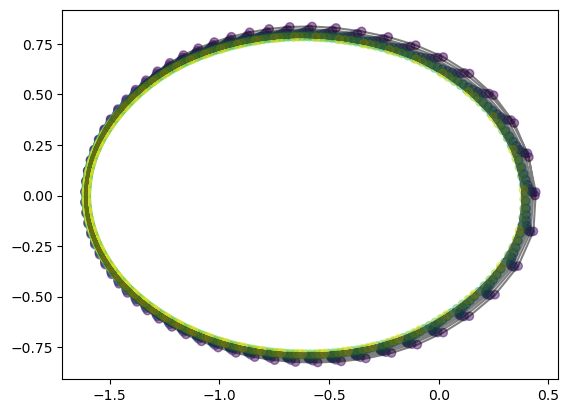

In [144]:
# plot with cmap time
plt.figure()
k=45
times = np.arange(0, data_none_aug10["y_pred"][k].shape[1]*0.1, 0.1)
#plt.scatter(data_none_aug1["y_pred"][k][0,:], data_none_aug1["y_pred"][k][1,:], c=times, cmap='viridis', label="aug1", alpha=0.5)
#plt.scatter(data_none_aug5["y_pred"][k][0,:], data_none_aug5["y_pred"][k][1,:], c=times, cmap='viridis', label="aug5", alpha=0.5)
plt.scatter(data_none_aug10["y_pred"][k][0,:], data_none_aug10["y_pred"][k][1,:], c=times, cmap='viridis', label="aug10", alpha=0.5)
plt.plot(data_none_aug10["y_pred"][k][0,:], data_none_aug10["y_pred"][k][1,:], label="pred", color="black", alpha=0.5)


#### Energy collapse regime

<Figure size 640x480 with 0 Axes>

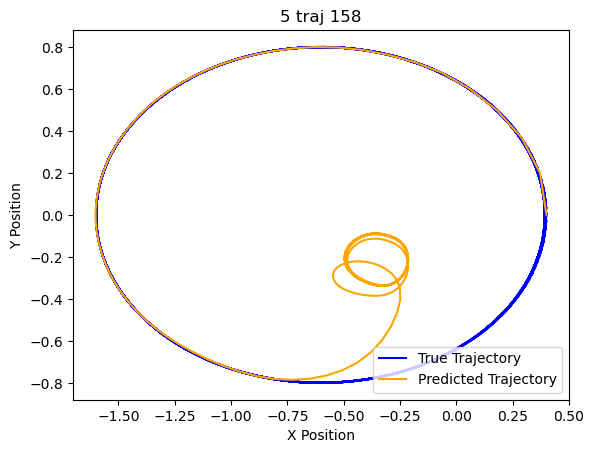

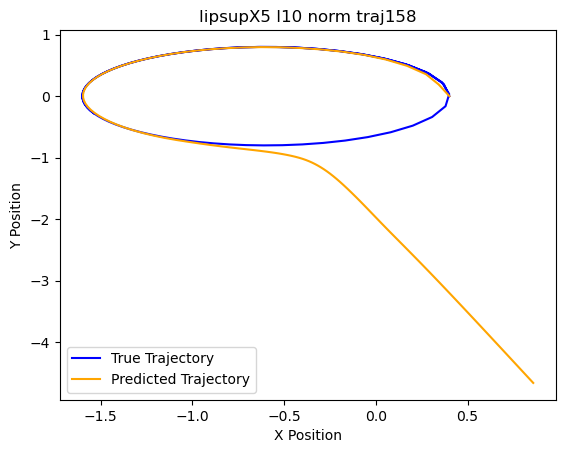

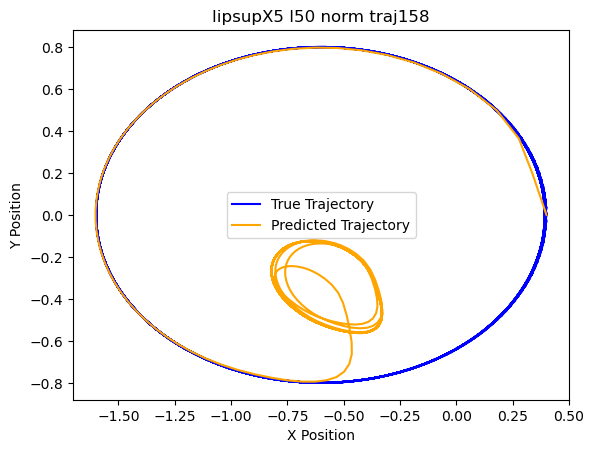

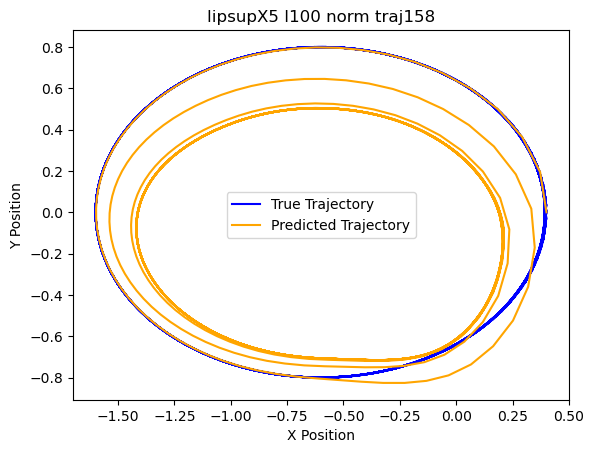

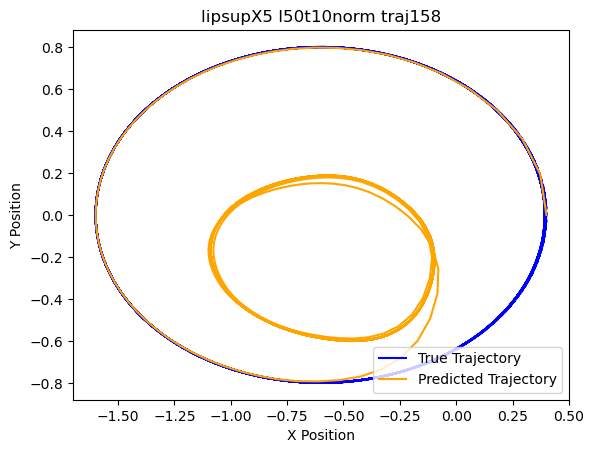

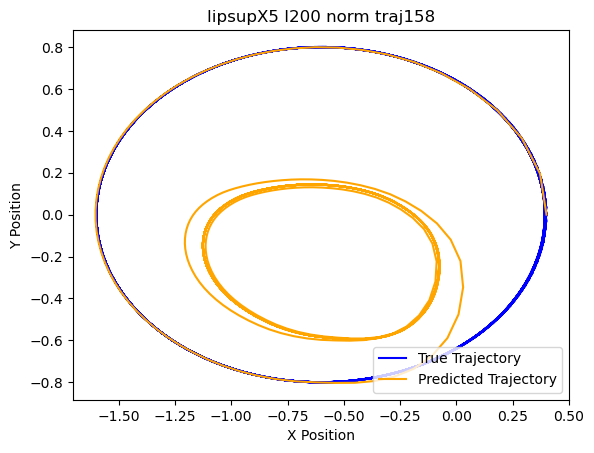

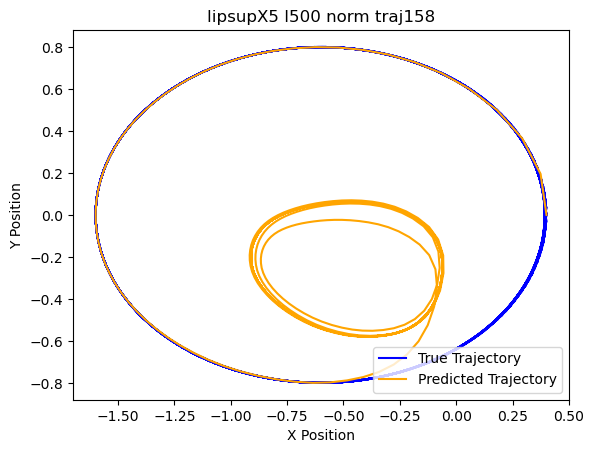

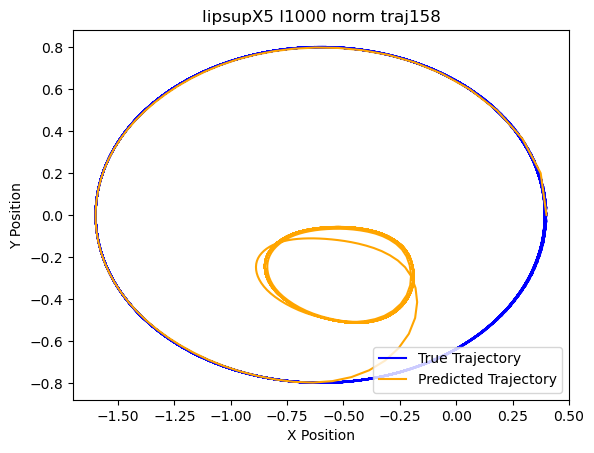

<Figure size 640x480 with 0 Axes>

In [112]:

# plot_trajectory(data_lipsupX5_l1["y_true"][k], data_lipsupX5_l1["y_pred"][k], f"lipsupX5 l1 traj{k}")
# plt.figure()
k=158
plot_trajectory(data_none_aug5_nocurr["y_true"][k], data_none_aug5_nocurr["y_pred"][k], f"5 traj {k}")
plt.figure()
# plot_trajectory(data_none_aug5["y_true"][k], data_none_aug5["y_pred"][k], f"5 traj {k}")
# plt.figure()
# plot_trajectory(data_lipsupX5_l100["y_true"][k][:,:101], data_lipsupX5_l100["y_pred"][k][:,:101], f"lipsupX5 l100 traj{k}")
# plt.figure()
# plot_trajectory(data_lipsupX5_l1000["y_true"][k], data_lipsupX5_l1000["y_pred"][k], f"lipsupX5 l1000 traj{k}")
# plt.figure()
plot_trajectory(data_lipsupX5_l10_norm["y_true"][k][:,:101], data_lipsupX5_l10_norm["y_pred"][k][:,:101], f"lipsupX5 l10 norm traj{k}")
plt.figure()
plot_trajectory(data_lipsupX5_l50_norm["y_true"][k][:,:], data_lipsupX5_l50_norm["y_pred"][k][:,:], f"lipsupX5 l50 norm traj{k}")
plt.figure()
plot_trajectory(data_lipsupX5_l100_norm["y_true"][k], data_lipsupX5_l100_norm["y_pred"][k], f"lipsupX5 l100 norm traj{k}")
plt.figure()
plot_trajectory(data_lipsupX5_l50t50_norm["y_true"][k], data_lipsupX5_l50t50_norm["y_pred"][k], f"lipsupX5 l50t10norm traj{k}")
plt.figure()
plot_trajectory(data_lipsupX5_l200_norm["y_true"][k], data_lipsupX5_l200_norm["y_pred"][k], f"lipsupX5 l200 norm traj{k}")
plt.figure()
plot_trajectory(data_lipsupX5_l500_norm["y_true"][k], data_lipsupX5_l500_norm["y_pred"][k], f"lipsupX5 l500 norm traj{k}")
plt.figure()
plot_trajectory(data_lipsupX5_l1000_norm["y_true"][k], data_lipsupX5_l1000_norm["y_pred"][k], f"lipsupX5 l1000 norm traj{k}")
plt.figure()

# plot_trajectory(data_lipsupX5_l10tau10["y_true"][k][:,:], data_lipsupX5_l10tau10["y_pred"][k][:,:], f"lipsupX5 l10tau10 traj{k}")
# plt.figure()

# plot_trajectory(data_none_aug03["y_true"][k], data_none_aug03["y_pred"][k], f"none aug03 traj{k}")
# plt.figure()



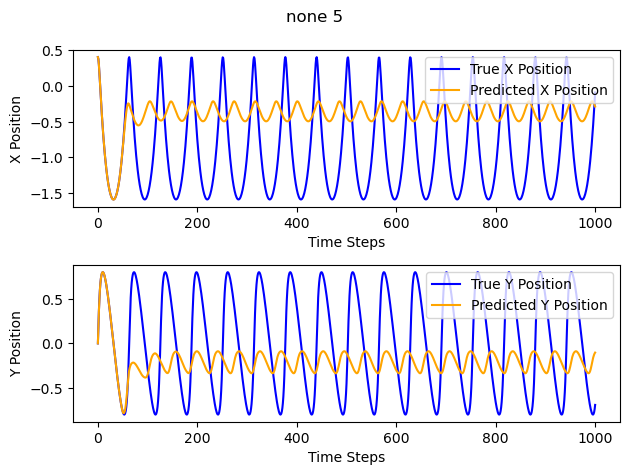

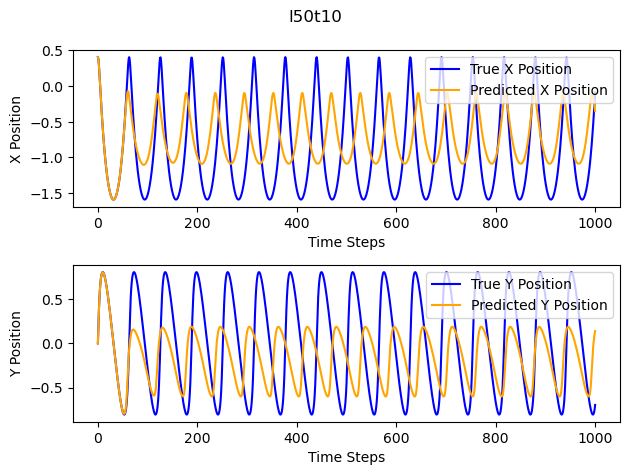

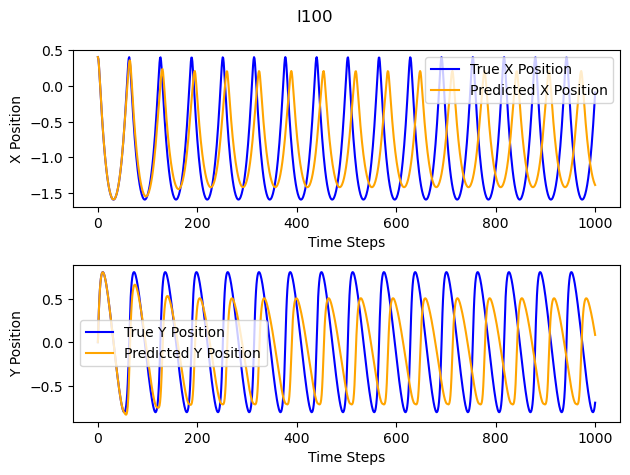

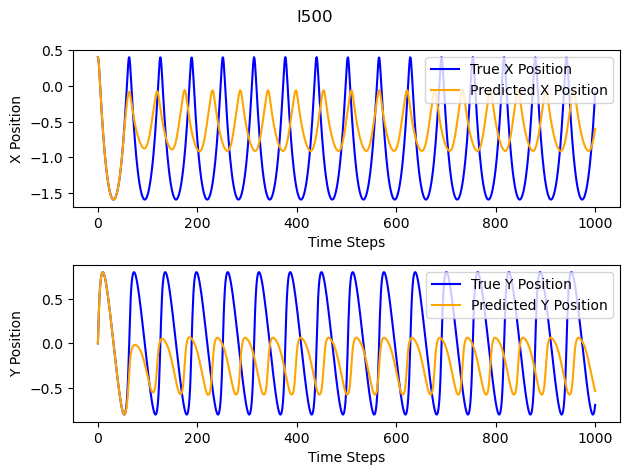

In [94]:
plot_xy(data_none_aug5_nocurr["y_true"][k], data_none_aug5_nocurr["y_pred"][k], f"none 5")
plot_xy(data_lipsupX5_l50t50_norm["y_true"][k], data_lipsupX5_l50t50_norm["y_pred"][k], f"l50t10")
plot_xy(data_lipsupX5_l100_norm["y_true"][k], data_lipsupX5_l100_norm["y_pred"][k], f"l100")
plot_xy(data_lipsupX5_l500_norm["y_true"][k], data_lipsupX5_l500_norm["y_pred"][k], f"l500")

In [69]:
data_lipsupX5_l1000_norm["L2_10s"].mean(), data_lipsupX5_l100_norm["L2_10s"].mean(),data_lipsupX5_l50t50_norm["L2_10s"].mean(), data_none_aug5_nocurr["L2_10s"].mean()

(0.13451035870020767,
 0.021621959795846003,
 0.08607489220374127,
 0.20271904952963082)

/var/folders/hd/6gcp429169ldrntwtps0b1_m0000gp/T/ipykernel_2374/1114190509.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=15)
/var/folders/hd/6gcp429169ldrntwtps0b1_m0000gp/T/ipykernel_2374/1114190509.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=15)


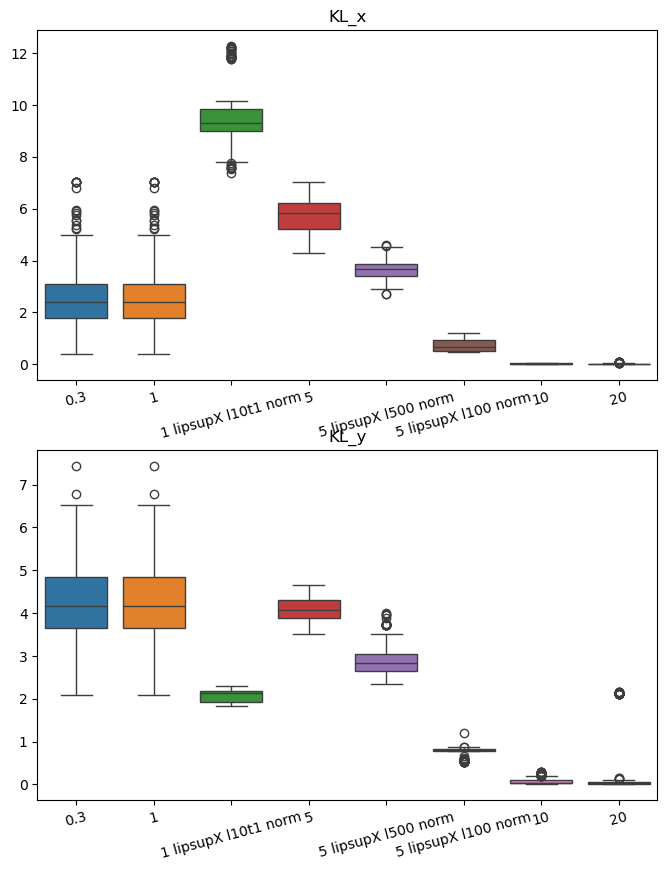

In [103]:
fig, ax = plt.subplots(2,figsize=(8, 10))
for i, name in enumerate(["KL_x", "KL_y"]):
    sns.boxplot(pd.DataFrame({
        "0.3": data_none_aug1[name],
        "1": data_none_aug1[name],
        "1 lipsupX l10t1 norm": data_lipsupX1_l10t1_norm[name],
        "5": data_none_aug5_nocurr[name],
        #"5 lipsupX l50t10 norm": data_lipsupX5_l50t50_norm[name],
        "5 lipsupX l500 norm": data_lipsupX5_l500_norm[name],
        "5 lipsupX l100 norm": data_lipsupX5_l100_norm[name],
        #"5 lipsupX l1000 norm": data_lipsupX5_l1000_norm[name],
        "10": data_none_aug10_nocurr[name],
        "20": data_none_aug20_nocurr[name],
    }), ax=ax[i])
    ax[i].set_title(name)
    # orient the x-axis labels
    ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=15)
   #ax[i].set_xticklabels(rotation=15)

### Full learning domain: various init points (White paper)

#### Diverging: offline

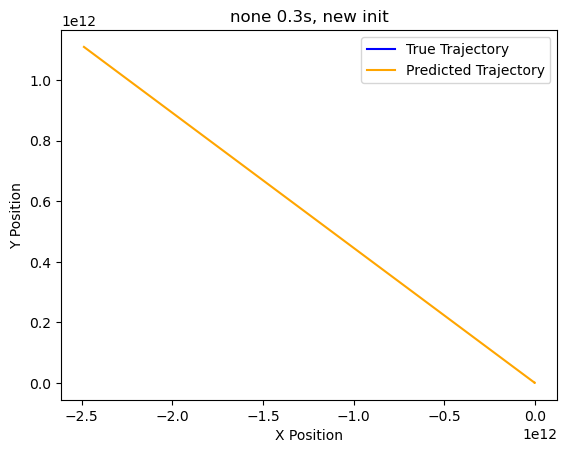

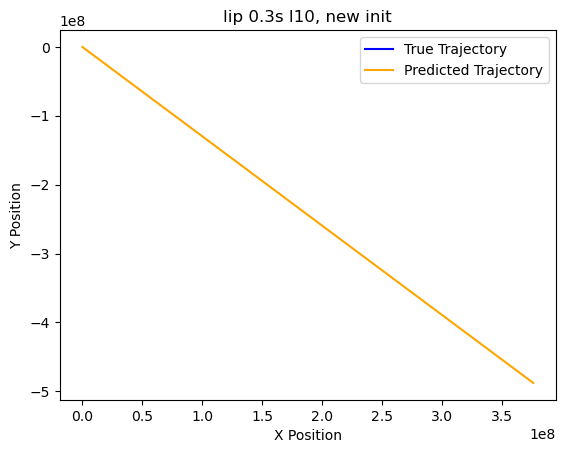

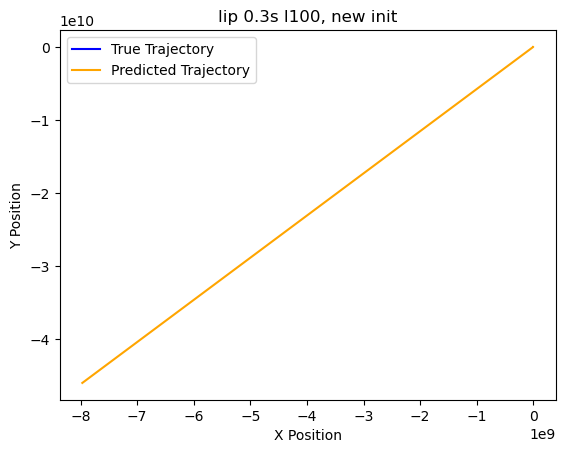

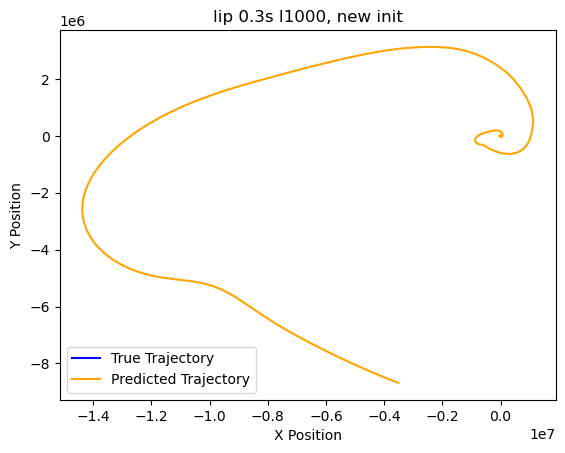

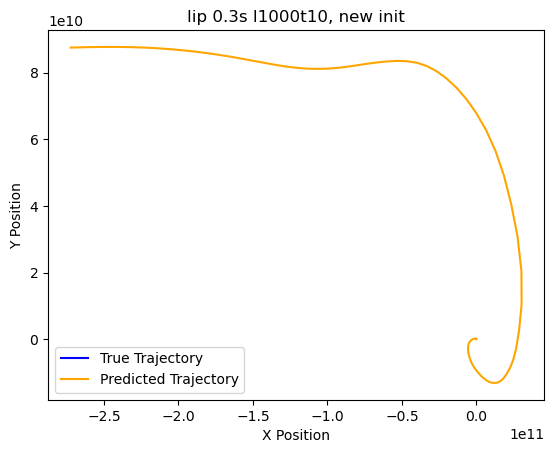

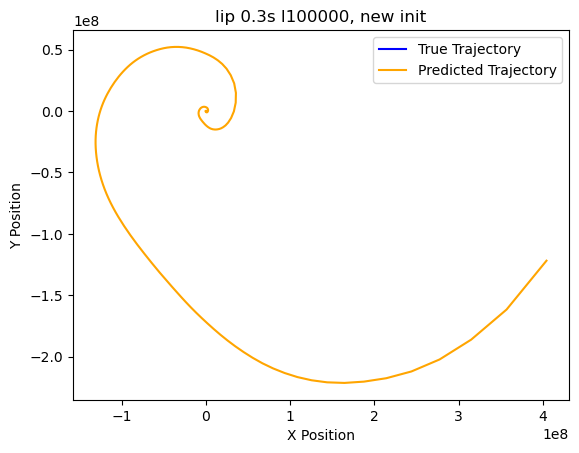

In [93]:
time=1001
k=56
plot_trajectory(data_none_aug03_init["y_true"][k][:,:time], data_none_aug03_init["y_pred"][k][:,:time], "none 0.3s, new init")
plt.figure()
plot_trajectory(data_lipsupX03_l10_init["y_true"][k][:,:time], data_lipsupX03_l10_init["y_pred"][k][:,:time], "lip 0.3s l10, new init")
plt.figure()
plot_trajectory(data_lipsupX03_l100_init["y_true"][k][:,:time], data_lipsupX03_l100_init["y_pred"][k][:,:time], "lip 0.3s l100, new init")
plt.figure()
plot_trajectory(data_lipsupX03_l1000_init["y_true"][k][:,:time], data_lipsupX03_l1000_init["y_pred"][k][:,:time], "lip 0.3s l1000, new init")
plt.figure()
plot_trajectory(data_lipsupX03_l1000t10_init["y_true"][k][:,:time], data_lipsupX03_l1000t10_init["y_pred"][k][:,:time], "lip 0.3s l1000t10, new init")
plt.figure()
plot_trajectory(data_lipsupX03_l100000_init["y_true"][k][:,:time], data_lipsupX03_l100000_init["y_pred"][k][:,:time], "lip 0.3s l100000, new init")

# plot_trajectory(data_lipsupX03_l10t10_init["y_true"][k][:,:time], data_lipsupX03_l10t10_init["y_pred"][k][:,:time], "lip 0.3s l10t10, new init")
# plt.figure()
# plot_trajectory(data_lipsupX03_l100t100_init["y_true"][k][:,:time], data_lipsupX03_l100t100_init["y_pred"][k][:,:time], "lip 0.3s l100t100, new init")


In [386]:
data_none_aug03_init["L2_50s"].mean(), data_lipsupX03_l100000_init["L2_50s"].mean(), data_lipsupX03_l1000_init["L2_50s"].mean()

(1.4523705568059224e+21, 3811336.896510758, 173571.58163942993)

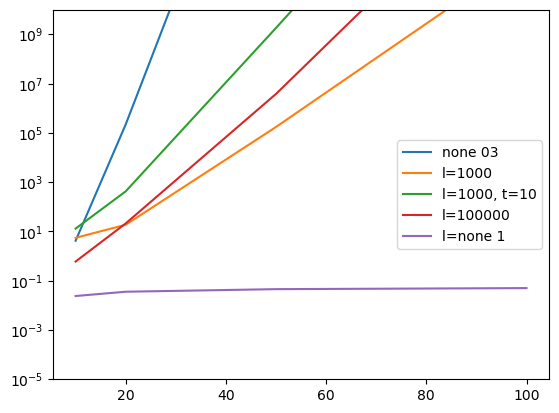

In [401]:
plt.plot([10,20,50,100], [data_none_aug03_init[f"L2_{k}s"].mean() for k in [10,20,50]]+[data_none_aug03_init["L2"].mean()],label= "none 03")
plt.plot([10,20,50,100], [data_lipsupX03_l1000_init[f"L2_{k}s"].mean() for k in [10,20,50]]+[data_lipsupX03_l1000_init["L2"].mean()] , label="l=1000")
plt.plot([10,20,50,100], [data_lipsupX03_l1000t10_init[f"L2_{k}s"].mean() for k in [10,20,50]]+[data_lipsupX03_l1000t10_init["L2"].mean()] , label="l=1000, t=10")

plt.plot([10,20,50,100], [data_lipsupX03_l100000_init[f"L2_{k}s"].mean() for k in [10,20,50]]+[data_lipsupX03_l100000_init["L2"].mean()], label="l=100000")
plt.plot([10,20,50,100], [data_none_aug1_init[f"L2_{k}s"].mean() for k in [10,20,50]]+[data_none_aug1_init["L2"].mean()], label="l=none 1")
plt.ylim(1e-5,1e10)
plt.yscale("log")
plt.legend()

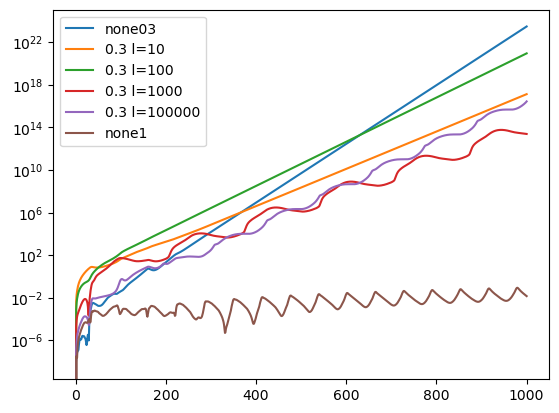

In [430]:
k=169
labels = ["none03","0.3 l=10","0.3 l=100", "0.3 l=1000", "0.3 l=100000", "none1"]
datas = [data_none_aug03_init,data_lipsupX03_l10_init,data_lipsupX03_l100_init, data_lipsupX03_l1000_init, data_lipsupX03_l100000_init, data_none_aug1_init]
for i,data in enumerate(datas):
    plt.plot(((data["y_true"][k][:2,:]-data["y_pred"][k][:2,:])**2).mean(axis=0), label=labels[i])

plt.yscale("log")
#plt.xlim(0,60)
plt.legend()

In [366]:
data_lipsupX03_l1000_init["L2"].mean(), data_none_aug03_init["L2"].mean()

(1706306304030.172, 7.872524016658234e+47)

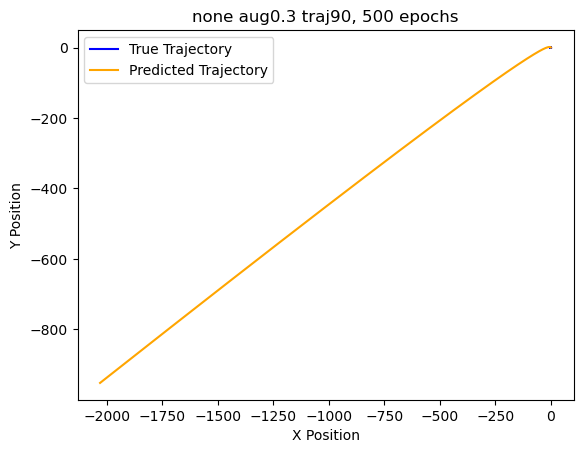

In [320]:
k=90
plot_trajectory(data_none_aug03["y_true"][k][:,:time], data_none_aug03["y_pred"][k][:,:time], f"none aug0.3 traj{k}, 500 epochs")


<Figure size 640x480 with 0 Axes>

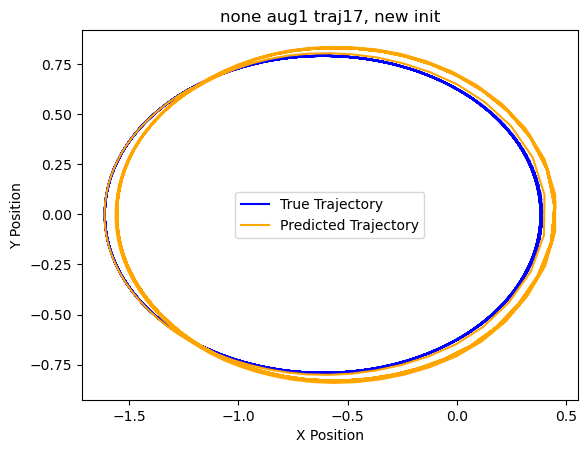

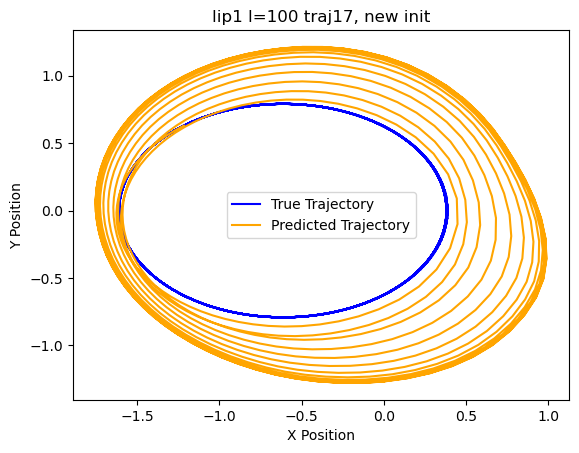

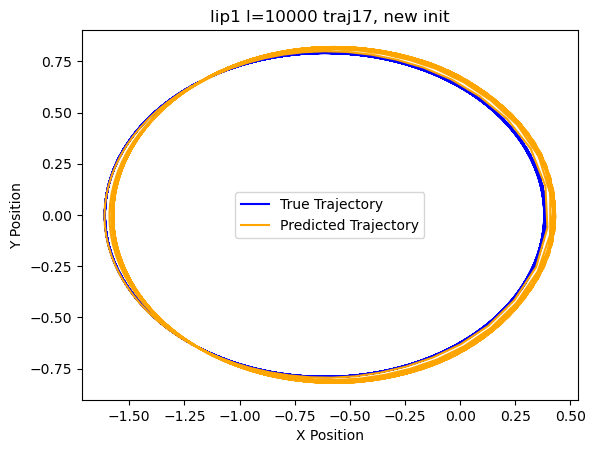

<Figure size 640x480 with 0 Axes>

In [465]:
time=1001
k=17
plot_trajectory(data_none_aug1_init["y_true"][k][:,:time], data_none_aug1_init["y_pred"][k][:,:time], f"none aug1 traj{k}, new init")
plt.figure()
plot_trajectory(data_lipsupX1_l100_init["y_true"][k][:,:time], data_lipsupX1_l100_init["y_pred"][k][:,:time], f"lip1 l=100 traj{k}, new init")
plt.figure()
plot_trajectory(data_lipsupX1_l10000_init["y_true"][k][:,:time], data_lipsupX1_l10000_init["y_pred"][k][:,:time], f"lip1 l=10000 traj{k}, new init")
plt.figure()

In [467]:
data_lipsupX1_l10000_init["L2_10s"].mean(), data_none_aug1_init["L2_10s"].mean()

(0.010653327480253072, 0.02392541052015083)

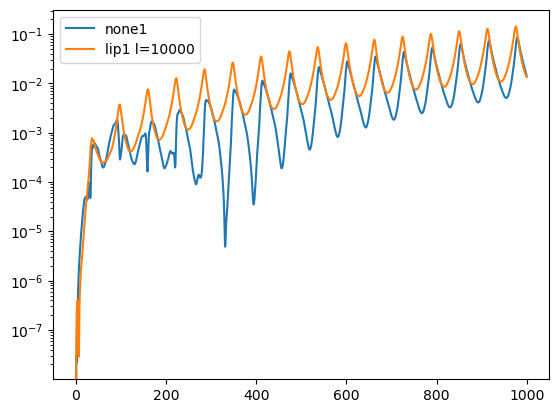

In [468]:
k=169
labels = ["none1", "lip1 l=10000"]
datas = [ data_none_aug1_init, data_lipsupX1_l10000_init]
for i,data in enumerate(datas):
    plt.plot(((data["y_true"][k][:2,:]-data["y_pred"][k][:2,:])**2).mean(axis=0), label=labels[i])

plt.yscale("log")
#plt.xlim(0,60)
plt.legend()

### Resticted learning domain

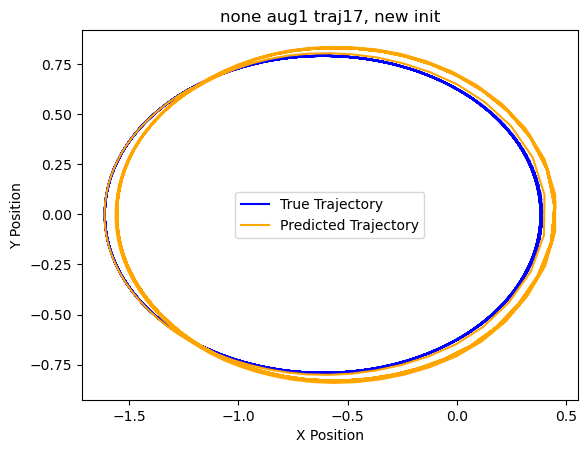

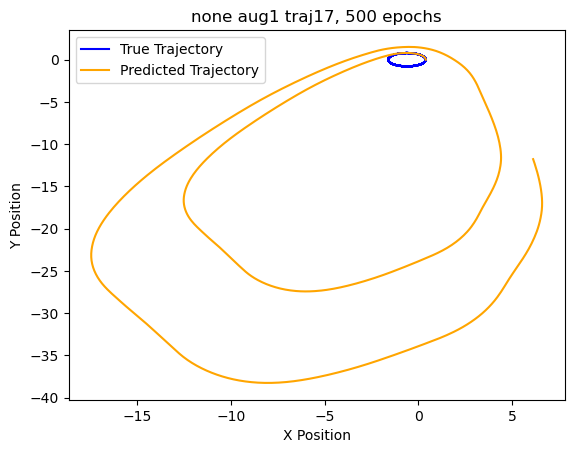

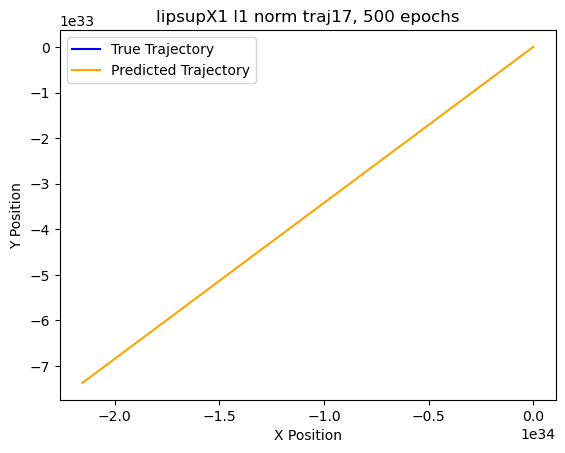

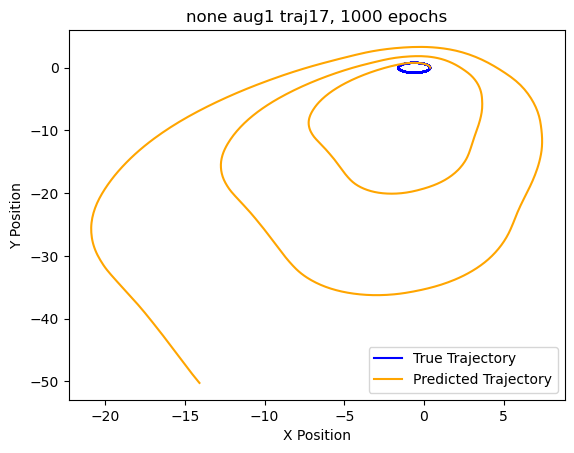

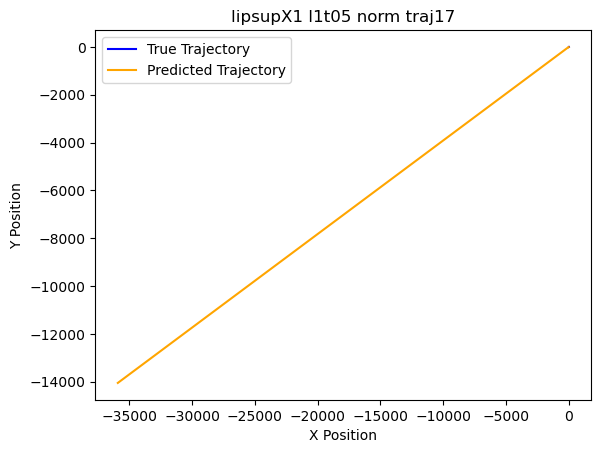

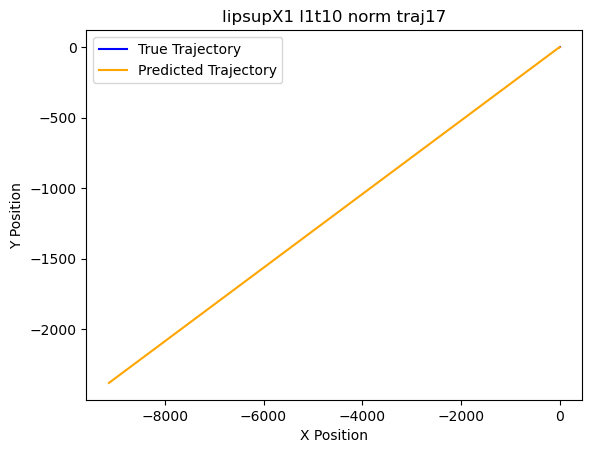

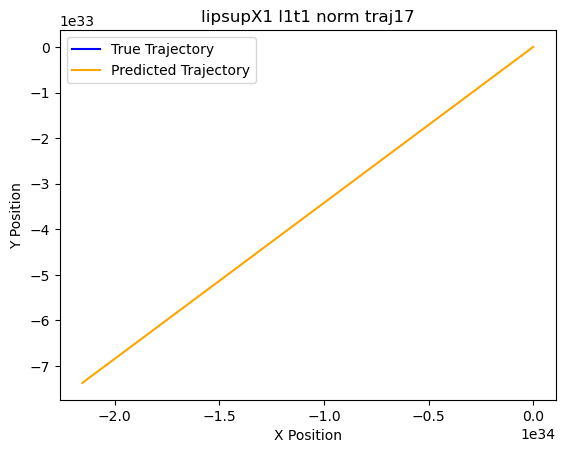

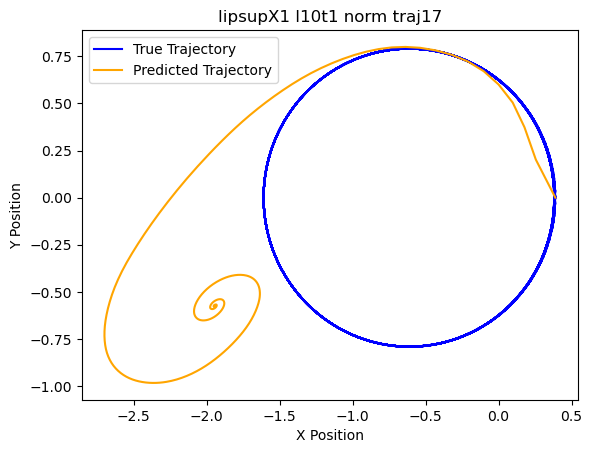

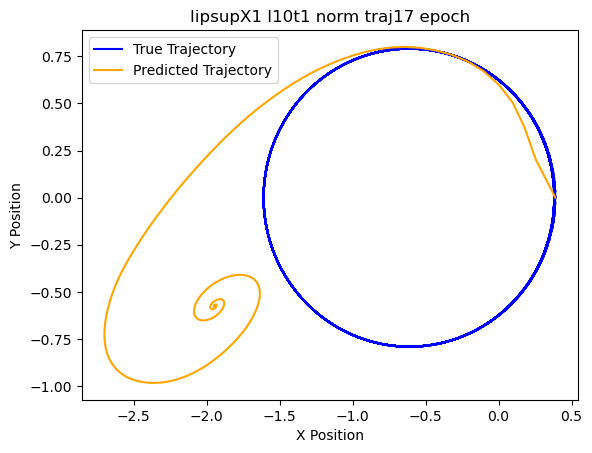

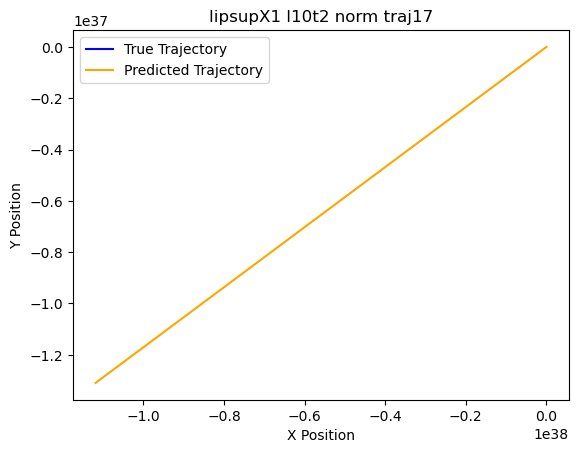

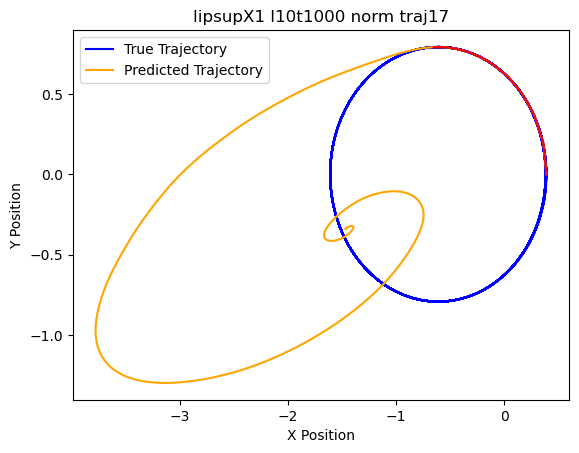

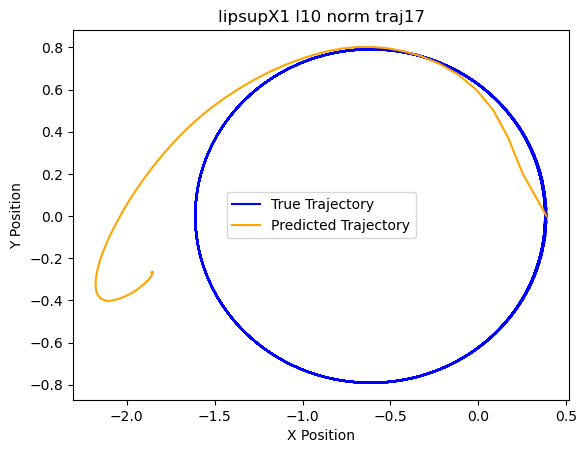

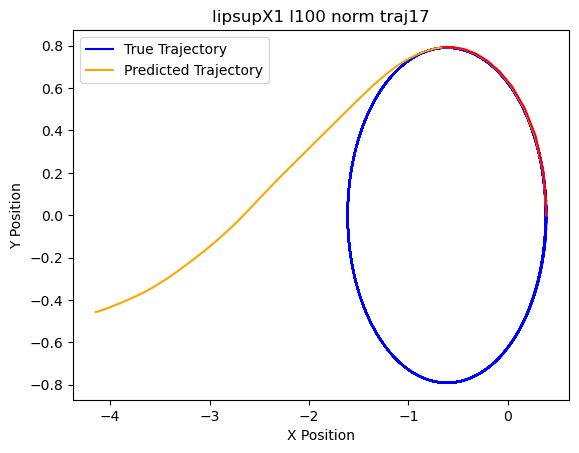

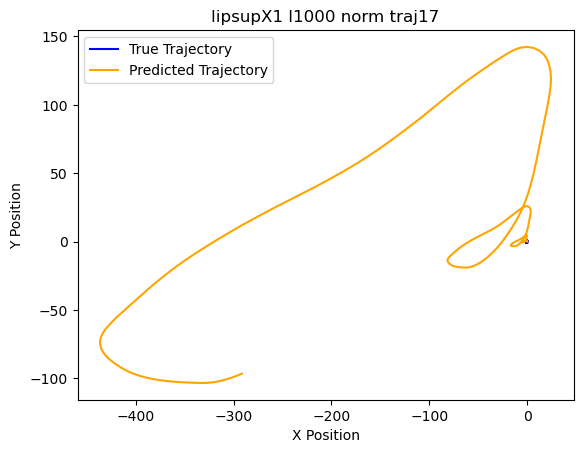

In [27]:
time=1001
k=17
plot_trajectory(data_none_aug1_init["y_true"][k][:,:time], data_none_aug1_init["y_pred"][k][:,:time], f"none aug1 traj{k}, new init")
plt.figure()
plot_trajectory(data_none_aug1["y_true"][k][:,:time], data_none_aug1["y_pred"][k][:,:time], f"none aug1 traj{k}, 500 epochs")
plt.figure()
plot_trajectory(data_lipsupX1_l1_norm["y_true"][k][:,:time], data_lipsupX1_l1_norm["y_pred"][k][:,:time], f"lipsupX1 l1 norm traj{k}, 500 epochs")
plt.figure()
plot_trajectory(data_none_aug1_epoch["y_true"][k][:,:time], data_none_aug1_epoch["y_pred"][k][:,:time], f"none aug1 traj{k}, 1000 epochs")
plt.figure()
plot_trajectory(data_lipsupX1_l10t05_norm["y_true"][k][:,:time], data_lipsupX1_l10t05_norm["y_pred"][k][:,:time], f"lipsupX1 l1t05 norm traj{k}")
plt.figure()
plot_trajectory(data_lipsupX1_l10t10_norm["y_true"][k][:,:time], data_lipsupX1_l10t10_norm["y_pred"][k][:,:time], f"lipsupX1 l1t10 norm traj{k}")
plt.figure()
plot_trajectory(data_lipsupX1_l1t1_norm["y_true"][k][:,:time], data_lipsupX1_l1t1_norm["y_pred"][k][:,:time], f"lipsupX1 l1t1 norm traj{k}")
plt.figure()
plot_trajectory(data_lipsupX1_l10t1_norm["y_true"][k][:,:time], data_lipsupX1_l10t1_norm["y_pred"][k][:,:time], f"lipsupX1 l10t1 norm traj{k}")
plt.figure()
plot_trajectory(data_lipsupX1_l10t1_norm_epoch["y_true"][k][:,:time], data_lipsupX1_l10t1_norm_epoch["y_pred"][k][:,:time], f"lipsupX1 l10t1 norm traj{k} epoch")
plt.figure()
plot_trajectory(data_lipsupX1_l10t2_norm["y_true"][k][:,:time], data_lipsupX1_l10t2_norm["y_pred"][k][:,:time], f"lipsupX1 l10t2 norm traj{k}")
plt.figure()
plot_trajectory(data_lipsupX1_l10t1000_norm["y_true"][k][:,:time], data_lipsupX1_l10t1000_norm["y_pred"][k][:,:time], f"lipsupX1 l10t1000 norm traj{k}")
plt.plot(data_lipsupX1_l10t1000_norm["y_pred"][k][0,:11], data_lipsupX1_l10t1000_norm["y_pred"][k][1,:11],color="red", label="1s pred")
plt.figure()
# plot_trajectory(data_lipsupX1_l10t10_norm["y_true"][k][:,:time], data_lipsupX1_l10t10_norm["y_pred"][k][:,:time], f"lipsupX1 l10t10 norm traj{k}")
# plt.figure()
# plot_trajectory(data_lipsupX1_l1_norm["y_true"][k][:,:time], data_lipsupX1_l1_norm["y_pred"][k][:,:time], f"lipsupX1 l1 norm traj{k}")
# plt.figure()
plot_trajectory(data_lipsupX1_l10_norm["y_true"][k][:,:time], data_lipsupX1_l10_norm["y_pred"][k][:,:time], f"lipsupX1 l10 norm traj{k}")
plt.figure()
plot_trajectory(data_lipsupX1_l100_norm["y_true"][k][:,:time], data_lipsupX1_l100_norm["y_pred"][k][:,:time], f"lipsupX1 l100 norm traj{k}")
plt.plot(data_none_aug1["y_pred"][k][0,:11], data_none_aug1["y_pred"][k][1,:11], color="red")

plt.figure()
plot_trajectory(data_lipsupX1_l1000_norm["y_true"][k][:,:time], data_lipsupX1_l1000_norm["y_pred"][k][:,:time], f"lipsupX1 l1000 norm traj{k}")


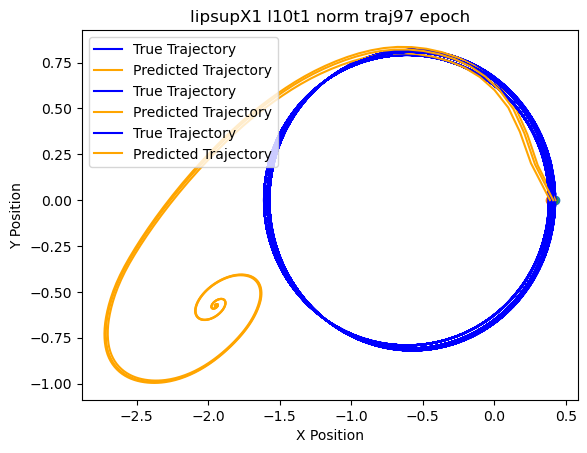

In [192]:
for k in [1,65,97]:
    plt.scatter(data_lipsupX1_l10t1_norm["y_true"][k][0,0], data_lipsupX1_l10t1_norm["y_true"][k][1,0])
    plot_trajectory(data_lipsupX1_l10t1_norm_epoch["y_true"][k][:,:time], data_lipsupX1_l10t1_norm_epoch["y_pred"][k][:,:time], f"lipsupX1 l10t1 norm traj{k} epoch")


In [30]:
def plot_xy(true, pred, title):
    fig, ax = plt.subplots(2)
    ax[0].plot(true[0,:], label='True X Position', color='blue')
    ax[0].plot(pred[0,:], label='Predicted X Position', color='orange')
    ax[0].set_xlabel('Time Steps')
    ax[0].set_ylabel('X Position')
    ax[0].legend()
    ax[1].plot(true[1,:], label='True Y Position', color='blue')
    ax[1].plot(pred[1,:], label='Predicted Y Position', color='orange')
    ax[1].set_xlabel('Time Steps')
    ax[1].set_ylabel('Y Position')
    ax[1].legend()
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

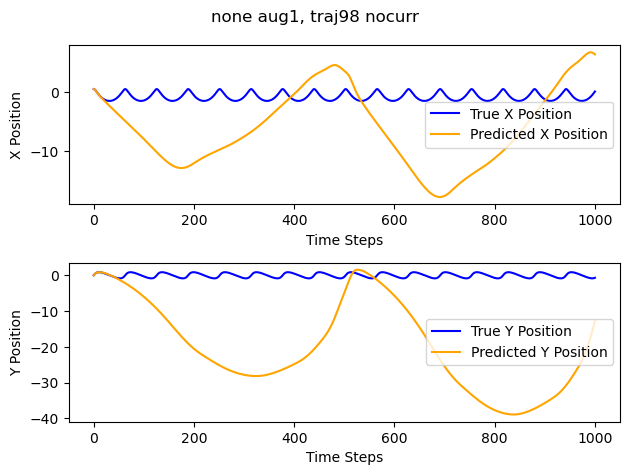

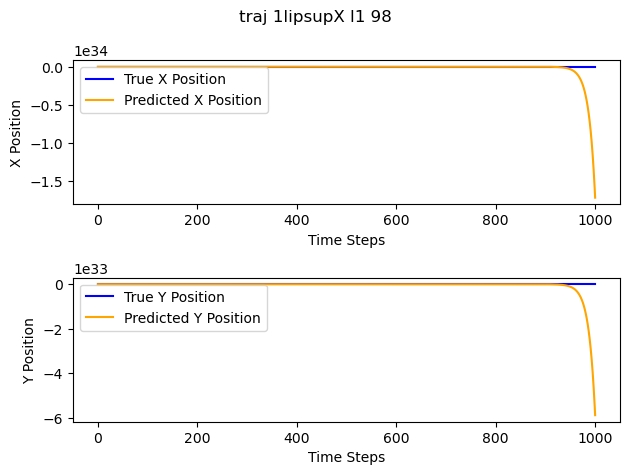

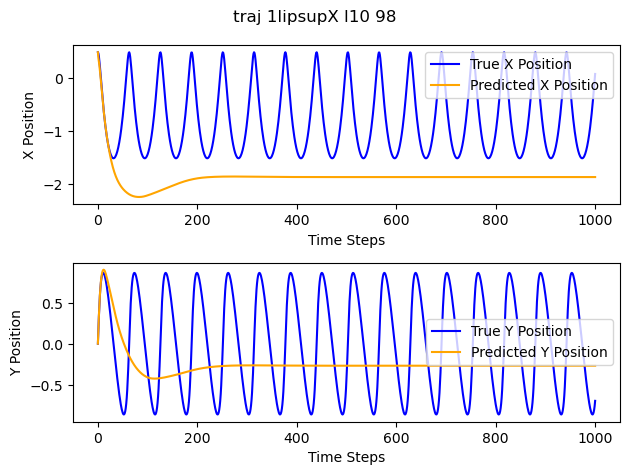

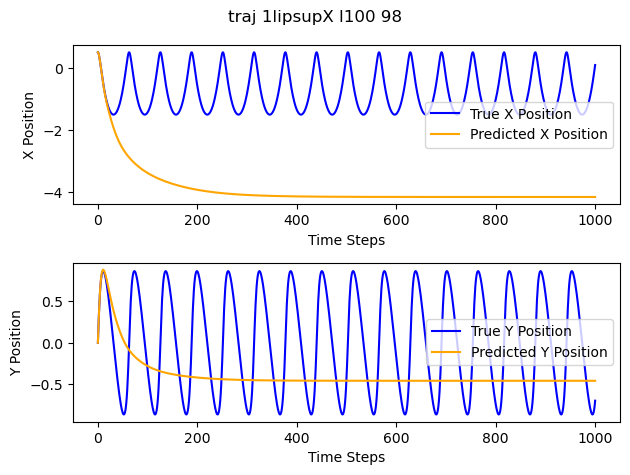

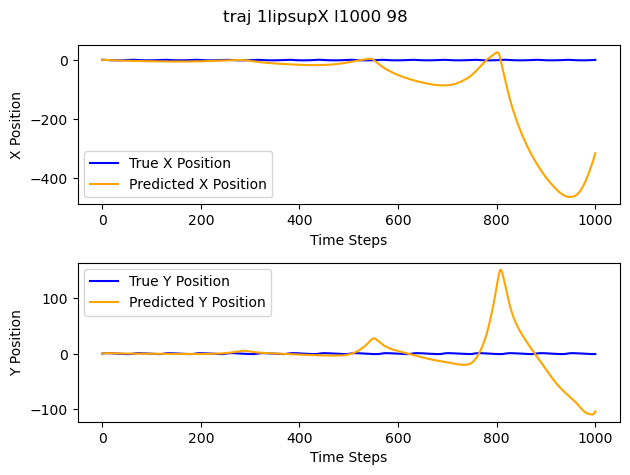

In [25]:
k=98
plot_xy(data_none_aug1["y_true"][k], data_none_aug1["y_pred"][k], title=f"none aug1, traj{k} nocurr")
plot_xy(data_lipsupX1_l1_norm["y_true"][k], data_lipsupX1_l1_norm["y_pred"][k], f"traj 1lipsupX l1 {k}")
plot_xy(data_lipsupX1_l10_norm["y_true"][k], data_lipsupX1_l10_norm["y_pred"][k], f"traj 1lipsupX l10 {k}")
plot_xy(data_lipsupX1_l100_norm["y_true"][k], data_lipsupX1_l100_norm["y_pred"][k], f"traj 1lipsupX l100 {k}")
plot_xy(data_lipsupX1_l1000_norm["y_true"][k], data_lipsupX1_l1000_norm["y_pred"][k], f"traj 1lipsupX l1000 {k}")


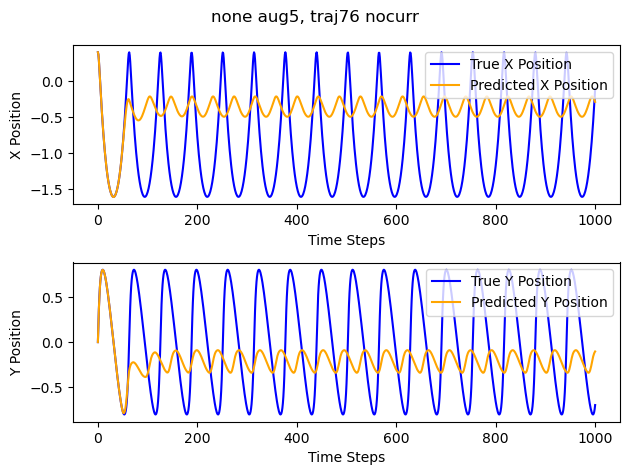

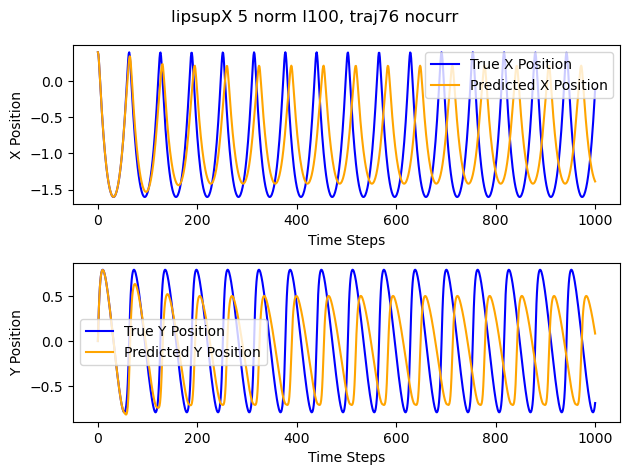

In [68]:
k=76
plot_xy(data_none_aug5_nocurr["y_true"][k], data_none_aug5_nocurr["y_pred"][k], title=f"none aug5, traj{k} nocurr")
#plot_xy(data_none_aug5["y_true"][k], data_none_aug5["y_pred"][k], title=f"none aug5, traj{k}")
plot_xy(data_lipsupX5_l100_norm["y_true"][k], data_lipsupX5_l100_norm["y_pred"][k], title=f"lipsupX 5 norm l100, traj{k} nocurr" )

here collapse

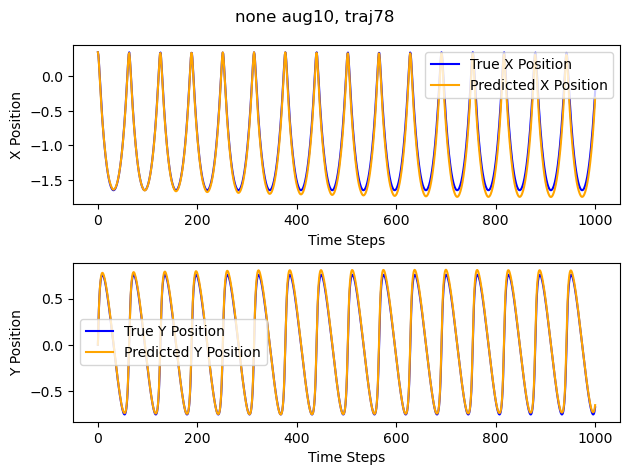

In [142]:
plot_xy(data_none_aug10_nocurr["y_true"][k], data_none_aug10_nocurr["y_pred"][k], title=f"none aug10, traj{k}")

ici plus deviation, est ce que c'est uniquement erreur de schéma qui s'accumule ? (comparer F et f_theta pour savoir)

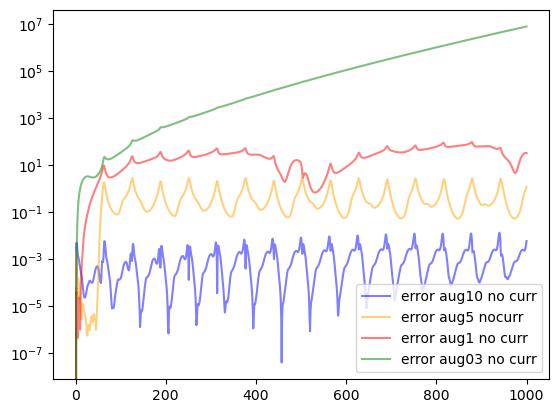

In [116]:
k=15
plt.plot(((data_none_aug10_nocurr["y_true"][k][2:4]-data_none_aug10_nocurr["y_pred"][k][2:4])**2).mean(axis=0), label="error aug10 no curr", color="blue", alpha=0.5)
#plt.plot(((data_none_aug10["y_true"][k][:2]-data_none_aug10["y_pred"][k][:2])**2).mean(axis=0), label="error aug10 curr", color="blue", linestyle='dashed')
#plt.plot(((data_none_aug5["y_true"][k][:2]-data_none_aug5["y_pred"][k][:2])**2).mean(axis=0), label="error aug5", color="orange", linestyle='dashed')
plt.plot(((data_none_aug5_nocurr["y_true"][k][2:4]-data_none_aug5_nocurr["y_pred"][k][2:4])**2).mean(axis=0), label="error aug5 nocurr", color="orange", alpha=0.5)
# 1s
plt.plot(((data_none_aug1["y_true"][k][2:4]-data_none_aug1["y_pred"][k][2:4])**2).mean(axis=0), label="error aug1 no curr", color="red", alpha=0.5)
# 3 steps (offline)
plt.plot(((data_none_aug03["y_true"][k][2:4]-data_none_aug03["y_pred"][k][2:4])**2).mean(axis=0), label="error aug03 no curr", color="green", alpha=0.5)
plt.yscale('log')
plt.legend()
plt.title("Velocity L2 error over time")

- faudrait comparer avec leur methodes des chunks pour voir si ca fait mieux que online pur
- curriculum pas forcement mieux (peut etre le plus continu)
- regime de collapse pour 5s, 10s moins mais tendance a "perdre de l'énergie" et tomber au centre (cercles de plus en plus petits)

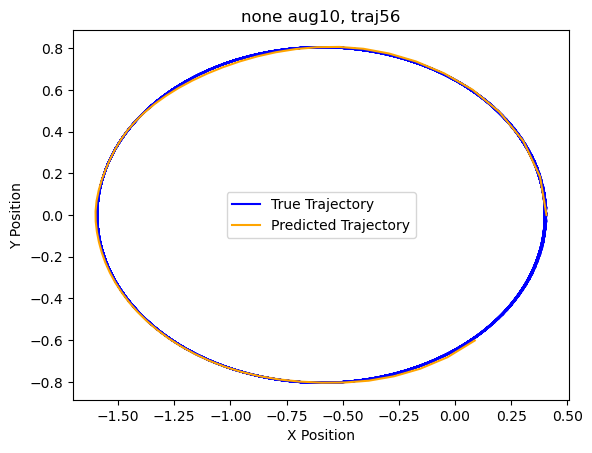

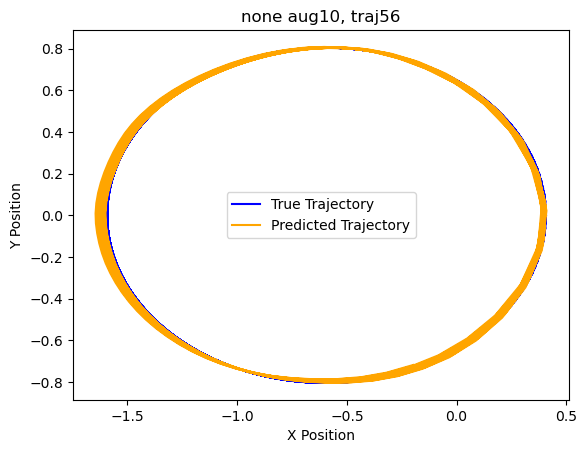

In [15]:
k=56
plot_trajectory(data_none_aug10_nocurr["y_true"][k], data_none_aug10_nocurr["y_pred"][k][:,:int(1/0.1)+50], title=f"none aug10, traj{k}")
plt.figure()
plot_trajectory(data_none_aug10_nocurr["y_true"][k], data_none_aug10_nocurr["y_pred"][k][:,:], title=f"none aug10, traj{k}")

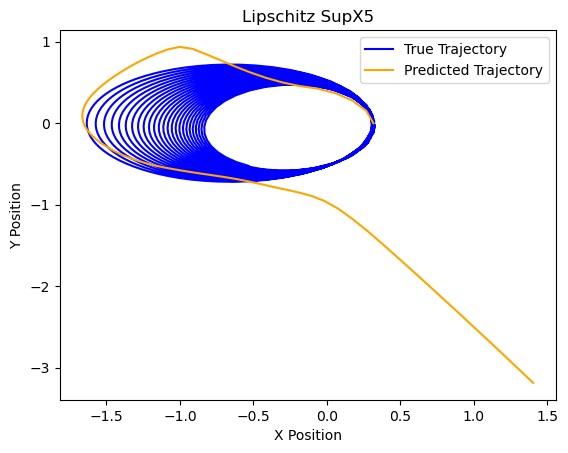

In [72]:
# k=198
# plot_trajectory(results_lipsupX5_l1["y_true"][k], results_lipsupX5_l1["y_pred"][k][:,:71], title="Lipschitz SupX5")

In [49]:
# data_none_aug1 = compute_metrics(results_none_aug1, compute_phy=False)
# data_none_aug5 = compute_metrics(results_none_aug5, compute_phy=False)
# data_none_aug10 = compute_metrics(results_none_aug10, compute_phy=False)
# data_lipsupX5_l1 = compute_metrics(results_lipsupX5_l1, compute_phy=False)

TypeError: unsupported operand type(s) for -: 'float' and 'NoneType'

<Figure size 640x480 with 0 Axes>

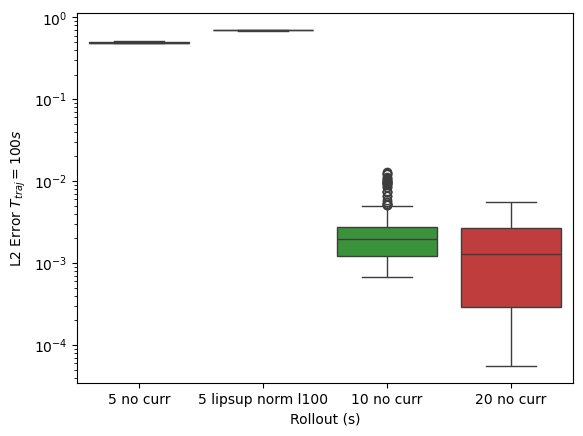

<Figure size 640x480 with 0 Axes>

In [37]:
sns.boxplot(pd.DataFrame({
    #"1": data_none_aug1["L2"],
    #"5": data_none_aug5["L2"],
    "5 no curr": data_none_aug5_nocurr["L2"],
    #"10": data_none_aug10["L2"],
    "5 lipsup norm l100": data_lipsupX5_l100_norm["L2"],
    "10 no curr": data_none_aug10_nocurr["L2"],
    "20 no curr": data_none_aug20_nocurr["L2"],
}))
plt.yscale("log")
plt.xlabel("Rollout (s)")
plt.ylabel(r"L2 Error $T_{traj}=100s$")
plt.figure()

# sns.boxplot(pd.DataFrame({
#     "5": data_none_aug5_nocurr["L2"],
#     "10": data_none_aug10_nocurr["L2"],
# }))
# plt.yscale("log")
# plt.xlabel("Rollout (s)")
# plt.ylabel(r"L2 Error $T_{traj}=100s$, NO CURR")

Curriculum useless here as signal is periodic. 

In [82]:
data_none_aug5["y_true"][k].shape

(4, 1001)

## $F_\theta$

In [33]:
def make_jacobian_norm_fn(model):
    """Returns a batched, JIT-compiled function to compute Jacobian norms."""
    # JIT compile jacobian computation
    jac_fn = jax.jit(jax.jacfwd(model))

    def jacobian_norm(y0):
        return jnp.linalg.norm(jac_fn(y0))

    return jax.vmap(jacobian_norm)  # vectorized over batch of y0

def compute_jacobian_test(model, y, bool_true=False):
    if bool_true:
        jacobian_norms_fn = make_jacobian_norm_fn(model)
    else:
        jacobian_norms_fn = make_jacobian_norm_fn(model.model_aug)
    return jacobian_norms_fn(y)  # y shape: (N, features)

In [34]:
def get_yL_states(dataframe, type='lorenz', bool_true=True):
    y_list = []
    if type == "pendulum":
        for i,data in enumerate(dataframe):
            states = jnp.array(data['states'])
            for j in range(states.shape[2]):
                y_list.append(states[0,:,j])
            # if i == 24:
            #     break
    elif type in ["lorenz","twobody"]:
        if bool_true:
            states = dataframe['y_true']
        else:
            states = dataframe['y_pred']
        for i in range(states.shape[0]):
            #print(states.shape, states[i].shape)
            for j in range(states[0].shape[1]):
            #print(states.shape)
                y_list.append(states[i][:,j])
    y_list = np.array(y_list)
    print(y_list.shape, y_list[0].shape)
    return y_list

In [36]:
from loss import F_twobody
y_list = get_yL_states(data_none_aug03, 'twobody', True)

(200200, 4) (4,)


In [37]:
Ftheta03 = jax.vmap(model_none_aug03.model_aug)(jnp.array(y_list))
Ftheta1 = jax.vmap(model_none_aug1.model_aug)(jnp.array(y_list))
Ftheta5 = jax.vmap(model_none_aug5_nocurr.model_aug)(jnp.array(y_list))
Ftheta10 = jax.vmap(model_none_aug10_nocurr.model_aug)(jnp.array(y_list))
Ftheta5_lipsupX_l100 = jax.vmap(model_lipsupX5_l100.model_aug)(jnp.array(y_list))
Ftheta20 = jax.vmap(model_none_aug20_nocurr.model_aug)(jnp.array(y_list))
Ftheta5_lipsupX_l100_norm = jax.vmap(model_lipsupX5_l100_norm.model_aug)(jnp.array(y_list))
Ftrue = jax.vmap(F_twobody)(jnp.array(y_list))

In [38]:
Ftheta1_lipsupX_l100_norm = jax.vmap(model_lipsupX1_l100_norm.model_aug)(jnp.array(y_list))
Ftheta1_lipsupX_l1000_norm = jax.vmap(model_lipsupX1_l1000_norm.model_aug)(jnp.array(y_list))
Ftheta1_lipsupX_l10_norm = jax.vmap(model_lipsupX1_l10_norm.model_aug)(jnp.array(y_list))
Ftheta1_lipsupX_l1_norm = jax.vmap(model_lipsupX1_l1_norm.model_aug)(jnp.array(y_list))

Ftheta1_epoch = jax.vmap(model_none_aug1_epoch.model_aug)(jnp.array(y_list))

In [43]:
Ftheta1_lipsupX_l10t1_norm = jax.vmap(model_lipsupX1_l10t1_norm.model_aug)(jnp.array(y_list))

In [114]:
np.mean(np.abs(Ftheta03-Ftrue)), np.mean(np.abs(Ftheta1-Ftrue)), np.mean(np.abs(Ftheta5-Ftrue)), np.mean(np.abs(Ftheta10-Ftrue))

(1.3418711, 0.4311158, 0.09860799, 0.04702746)

In [39]:
y_np = np.array(y_list)

In [442]:
# y init
y_list_init = get_yL_states(data_none_aug03_init, 'twobody', True)
y_np_init = np.array(y_list_init)

(200200, 4) (4,)


In [40]:
jacs_true = compute_jacobian_test(F_twobody, jnp.array(y_np),True)
jacs_none_aug03 = compute_jacobian_test(model_none_aug03,jnp.array(y_np))
jacs_none_aug1 =compute_jacobian_test(model_none_aug1,jnp.array(y_np))
jacs_none_aug5 = compute_jacobian_test(model_none_aug5_nocurr,jnp.array(y_np))
jacs_none_aug10 = compute_jacobian_test(model_none_aug10_nocurr,jnp.array(y_np))
jacs_none_aug5_l100 = compute_jacobian_test(model_lipsupX5_l100, jnp.array(y_np))
jacs_none_aug20 =  compute_jacobian_test(model_none_aug20_nocurr, jnp.array(y_np))
jacs_none_aug5_l100_norm = compute_jacobian_test(model_lipsupX5_l100_norm, jnp.array(y_np))


In [44]:
jacs_none_aug1_l100_norm = compute_jacobian_test(model_lipsupX1_l100_norm, jnp.array(y_np))
jacs_none_aug1_l1000_norm = compute_jacobian_test(model_lipsupX1_l1000_norm, jnp.array(y_np))
jacs_none_aug1_l10_norm = compute_jacobian_test(model_lipsupX1_l10_norm, jnp.array(y_np))
jacs_none_aug1_l1_norm = compute_jacobian_test(model_lipsupX1_l1_norm, jnp.array(y_np))
jacs_none_aug1_epoch = compute_jacobian_test(model_none_aug1_epoch, jnp.array(y_np))
jacs_lipsupX1_l10t1_norm = compute_jacobian_test(model_lipsupX1_l10t1_norm, jnp.array(y_np))

In [443]:
jacs_none_aug03_init = compute_jacobian_test(model_none_aug03_init,jnp.array(y_np_init))
jacs_none_aug1_init = compute_jacobian_test(model_none_aug1_init, jnp.array(y_np_init))
jacs_lipsupX03_l1000_init = compute_jacobian_test(model_lipsupX03_l1000_init, jnp.array(y_np_init))
jacs_lipsupX03_l10_init = compute_jacobian_test(model_lipsupX03_l10_init, jnp.array(y_np_init))
jacs_lipsupX03_l100_init = compute_jacobian_test(model_lipsupX03_l100_init, jnp.array(y_np_init))

jacs_lipsupX03_l100000_init = compute_jacobian_test(model_lipsupX03_l100000_init, jnp.array(y_np_init))



In [450]:
jacs_true_init = compute_jacobian_test(F_twobody, jnp.array(y_np_init),True)
jacs_none_aug10_oninit = compute_jacobian_test(model_none_aug10_nocurr,jnp.array(y_np_init) )
jacs_none_aug20_oninit = compute_jacobian_test(model_none_aug20_nocurr ,jnp.array(y_np_init) )


In [479]:
Ftheta03_init = jax.vmap(model_none_aug03_init.model_aug)(jnp.array(y_list_init))
Ftheta1_init = jax.vmap(model_none_aug1_init.model_aug)(jnp.array(y_list_init))
Ftrue_init = jax.vmap(F_twobody)(jnp.array(y_list_init))
Ftheta03_lipsup_l100000_init = jax.vmap(model_lipsupX03_l100000_init.model_aug)(jnp.array(y_list_init))
Ftheta03_lipsup_l100_init = jax.vmap(model_lipsupX03_l100_init.model_aug)(jnp.array(y_list_init))

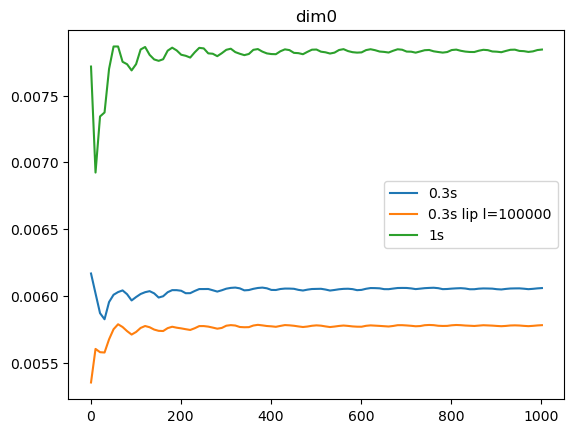

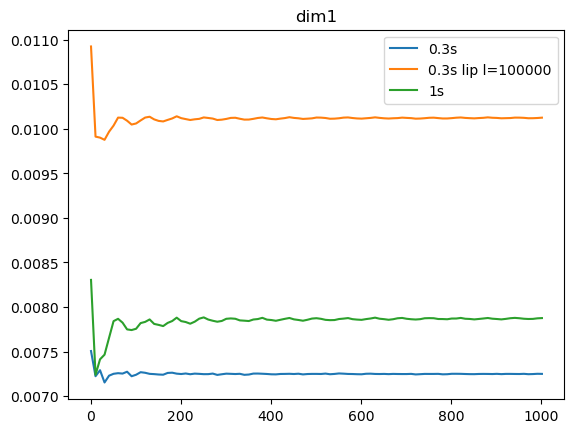

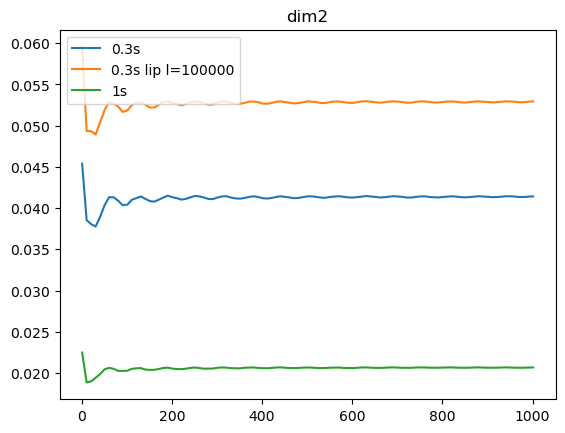

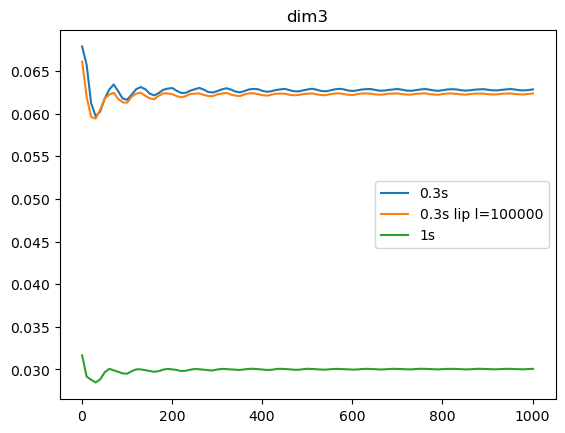

In [481]:
steps = np.arange(1,1002,10)
for i in range(4):
    plt.figure()
    plt.title(f"dim{i}")
    plt.plot(steps,[np.abs(Ftrue_init.reshape(200,1001,4)[:,:time,i]-Ftheta03_init.reshape(200,1001,4)[:,:time, i]).mean() for time in steps], label=f"0.3s")
    plt.plot(steps,[np.abs(Ftrue_init.reshape(200,1001,4)[:,:time,i]-Ftheta03_lipsup_l100000_init.reshape(200,1001,4)[:,:time, i]).mean() for time in steps], label=f"0.3s lip l=100000") 
    #plt.plot(steps,[np.abs(Ftrue_init.reshape(200,1001,4)[:,:time,i]-Ftheta03_lipsup_l100_init.reshape(200,1001,4)[:,:time, i]).mean() for time in steps], label=f"0.3s lip l=100") 
    plt.plot(steps,[np.abs(Ftrue_init.reshape(200,1001,4)[:,:time,i]-Ftheta1_init.reshape(200,1001,4)[:,:time, i]).mean() for time in steps], label=f"1s")
  
    #plt.plot(steps,[np.abs(Ftrue_init.reshape(200,1001,4)[:,:time,i]-Ftheta5_lipsupX_l100_norm_reshape[:,:time, i]).mean() for time in steps], label=f"5s lipsupX norm l100")
    #plt.plot(steps,[np.abs(Ftrue_reshape[:,:time,i]-Ftheta10_reshape[:,:time, i]).mean() for time in steps], label=f"10s")
    plt.legend()

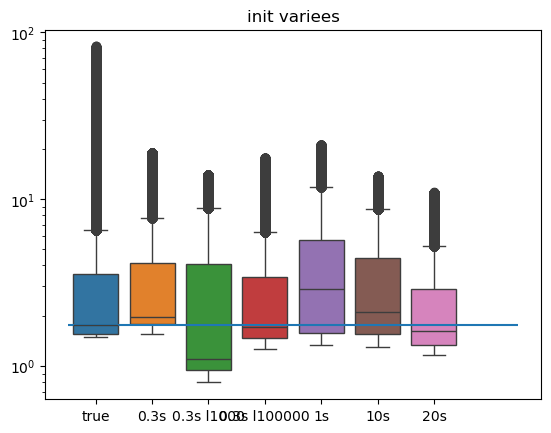

In [455]:
sns.boxplot(pd.DataFrame({
    "true": jacs_true_init,
    #"0.3s init pauvre": jacs_none_aug03,
    "0.3s": jacs_none_aug03_init,
    #"0.3s l10": jacs_lipsupX03_l10_init,
    #"0.3s l100": jacs_lipsupX03_l100_init,
    "0.3s l1000": jacs_lipsupX03_l1000_init,
    "0.3s l100000": jacs_lipsupX03_l100000_init,
    "1s": jacs_none_aug1_init,
    "10s": jacs_none_aug10_oninit,
    "20s": jacs_none_aug20_oninit
}))
plt.hlines(jnp.median(jacs_true_init), -0.5, 7.5)
plt.title("init variees")
plt.yscale("log")

In [115]:
np.mean(np.abs(jacs_none_aug03-jacs_true)),np.mean(np.abs(jacs_none_aug1-jacs_true)), np.mean(np.abs(jacs_none_aug5-jacs_true)), np.mean(np.abs(jacs_none_aug10-jacs_true))

(4.2291136, 4.2008047, 2.0977101, 2.4142816)

In [121]:
Ftheta03.shape, y_np.shape

((200200, 4), (200200, 4))

In [120]:
jacs_true_traj = jacs_true.reshape((200,1001))
jacs_true.shape

(200200,)

Text(0.5, 1.0, 'Jacobian norms on true trajectories')

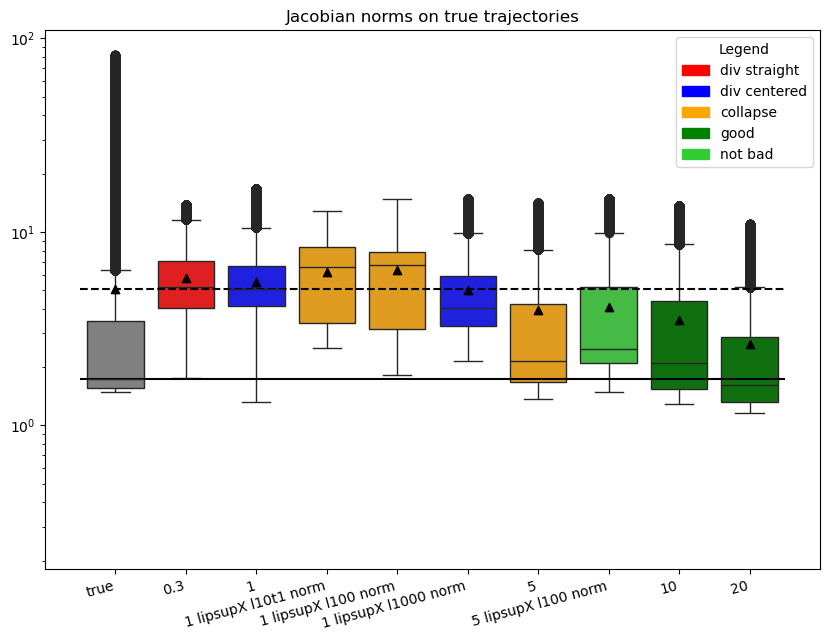

In [100]:
from matplotlib.patches import Patch
plt.figure(figsize=(10,7))
palette = ["grey", "red", "blue", "orange", "orange", "blue", "orange", "limegreen", "green", "green" ]
colors = ["red", "blue", "orange", "green", "limegreen"]
color_labels = ["div straight", "div centered", "collapse", "good", "not bad"]
sns.boxplot(
    pd.DataFrame({
    "true": jacs_true,
    "0.3": jacs_none_aug03,
    "1": jacs_none_aug1,
    "1 lipsupX l10t1 norm": jacs_lipsupX1_l10t1_norm,
    "1 lipsupX l100 norm": jacs_none_aug1_l100_norm,
    "1 lipsupX l1000 norm": jacs_none_aug1_l1000_norm,
    "5": jacs_none_aug5,
    #"5 lipsupX l100": jacs_none_aug5_l100,
    "5 lipsupX l100 norm": jacs_none_aug5_l100_norm,
    "10": jacs_none_aug10,
    "20": jacs_none_aug20
}), palette=palette)
plt.yscale("log")
handles = [Patch(color=color, label=label) for color, label in zip(colors, color_labels)]


# Ajouter la moyenne en triangle rouge
means = [
    jacs_true.mean(),
    jacs_none_aug03.mean(),
    jacs_none_aug1.mean(),
    jacs_lipsupX1_l10t1_norm.mean(),
    jacs_none_aug1_l100_norm.mean(),
    jacs_none_aug1_l1000_norm.mean(),
    jacs_none_aug5.mean(),
    #jacs_none_aug5_l100.mean(),
    jacs_none_aug5_l100_norm.mean(),
    jacs_none_aug10.mean(),
    jacs_none_aug20.mean()
]

plt.scatter(range(len(means)), means, color='black', marker='^', label='Mean', zorder=3)
plt.xticks(rotation=15, ha='right')
plt.hlines(jnp.median(jacs_true), -0.5, len(means)-0.5, color='black', linestyle='-', label='Median true')
plt.hlines(jnp.mean(jacs_true), -0.5, len(means)-0.5, color='black', linestyle='--', label='Mean true')
plt.legend(handles=handles, title="Legend", loc="best")
plt.title("Jacobian norms on true trajectories")

In [55]:
medians = [
    jnp.median(jacs_true),
    jnp.median(jacs_none_aug03),
    jnp.median(jacs_none_aug1),
    jnp.median(jacs_lipsupX1_l10t1_norm),
    jnp.median(jacs_none_aug1_l100_norm),
    jnp.median(jacs_none_aug1_l1000_norm),
    jnp.median(jacs_none_aug5),
    #jnp.median(jacs_none_aug5_l100),
    jnp.median(jacs_none_aug5_l100_norm),
    jnp.median(jacs_none_aug10),
    jnp.median(jacs_none_aug20)
]

In [52]:
means[0], means

(Array(5.063364, dtype=float32),
 [Array(5.063364, dtype=float32),
  Array(5.7606616, dtype=float32),
  Array(5.48988, dtype=float32),
  Array(6.2111974, dtype=float32),
  Array(6.3815036, dtype=float32),
  Array(4.981164, dtype=float32),
  Array(3.9315097, dtype=float32),
  Array(4.088056, dtype=float32),
  Array(3.4945505, dtype=float32),
  Array(2.6325572, dtype=float32)])

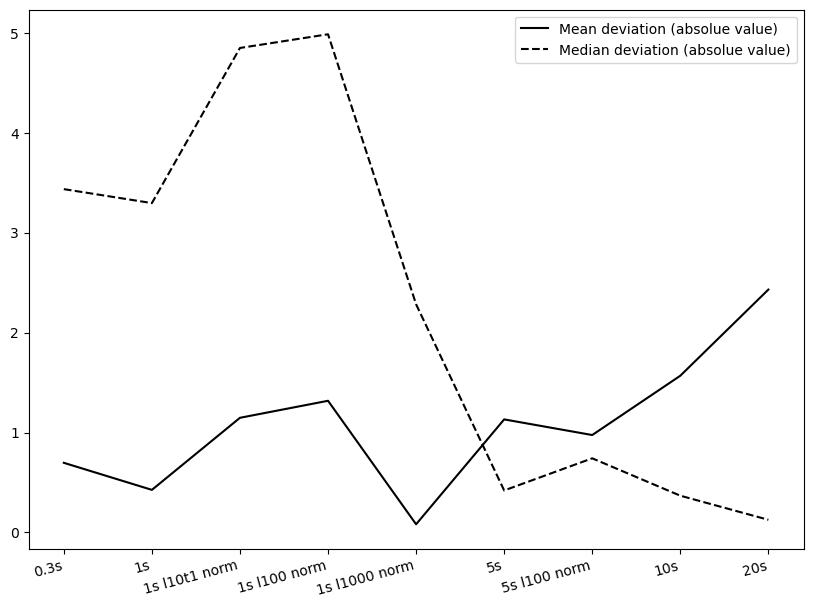

In [63]:
plt.figure(figsize=(10,7))
plt.plot(np.abs(np.array(means)-means[0])[1:], label="Mean deviation (absolue value)", linestyle='-', color='black')
plt.plot(np.abs(np.array(medians)-medians[0])[1:], label="Median deviation (absolue value)", linestyle='--', color='black')
# xticks models
plt.xticks(ticks=range(len(means)-1), labels=[
    "0.3s", "1s", "1s l10t1 norm", "1s l100 norm", "1s l1000 norm",
    "5s", "5s l100 norm", "10s", "20s"
], rotation=15, ha='right')
plt.legend()
plt.show()


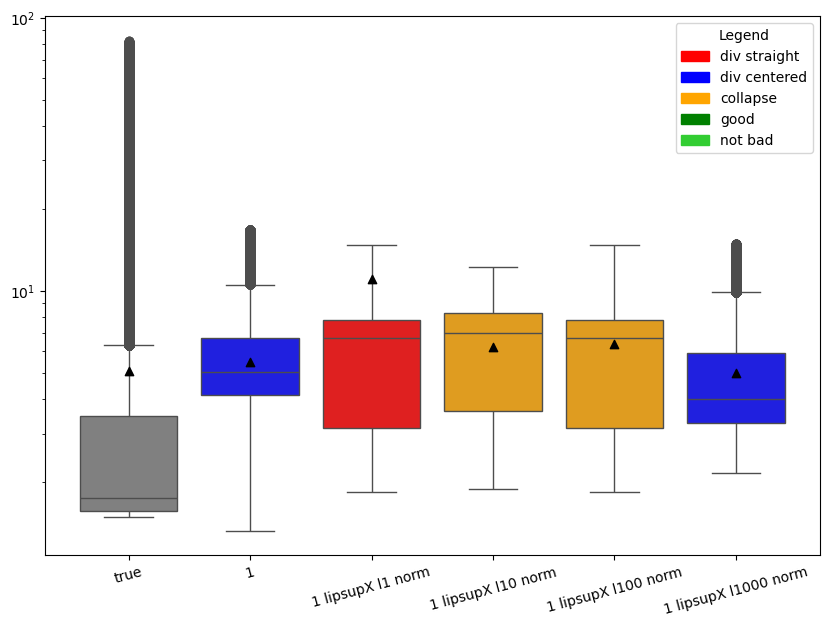

In [35]:
from matplotlib.patches import Patch
plt.figure(figsize=(10,7))
palette = ["grey", "blue", "red",  "orange", "orange", "blue" ]
colors = ["red", "blue", "orange", "green", "limegreen"]
color_labels = ["div straight", "div centered", "collapse", "good", "not bad"]
sns.boxplot(
    pd.DataFrame({
    "true": jacs_true,
    #"0.3": jacs_none_aug03,
    "1": jacs_none_aug1,
    "1 lipsupX l1 norm": jacs_none_aug1_l100_norm,
    "1 lipsupX l10 norm": jacs_none_aug1_l10_norm,
    "1 lipsupX l100 norm": jacs_none_aug1_l100_norm,
    "1 lipsupX l1000 norm": jacs_none_aug1_l1000_norm,
    #"5": jacs_none_aug5,
    #"5 lipsupX l100": jacs_none_aug5_l100,
    #"5 lipsupX l100 norm": jacs_none_aug5_l100_norm,
    #"10": jacs_none_aug10,
    #"20": jacs_none_aug20
}), palette=palette)
plt.yscale("log")
handles = [Patch(color=color, label=label) for color, label in zip(colors, color_labels)]


# Ajouter la moyenne en triangle rouge
means = [
    jacs_true.mean(),
    #jacs_none_aug03.mean(),
    jacs_none_aug1.mean(),
    jacs_none_aug1_l1_norm.mean(),
    jacs_none_aug1_l10_norm.mean(),
    jacs_none_aug1_l100_norm.mean(),
    jacs_none_aug1_l1000_norm.mean(),
    #jacs_none_aug5.mean(),
    #jacs_none_aug5_l100.mean(),
    #jacs_none_aug5_l100_norm.mean(),
    #jacs_none_aug10.mean(),
    #jacs_none_aug20.mean()
]

plt.scatter(range(len(means)), means, color='black', marker='^', label='Mean', zorder=3)
plt.xticks(rotation=15)
plt.legend(handles=handles, title="Legend", loc="best")


/var/folders/hd/6gcp429169ldrntwtps0b1_m0000gp/T/ipykernel_5991/7545547.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/hd/6gcp429169ldrntwtps0b1_m0000gp/T/ipykernel_5991/7545547.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/hd/6gcp429169ldrntwtps0b1_m0000gp/T/ipykernel_5991/7545547.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/hd/6gcp429169ldrntwtps0b1_m0000gp/T/ipykernel_5991/7545547.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be remov

<Figure size 1000x600 with 0 Axes>

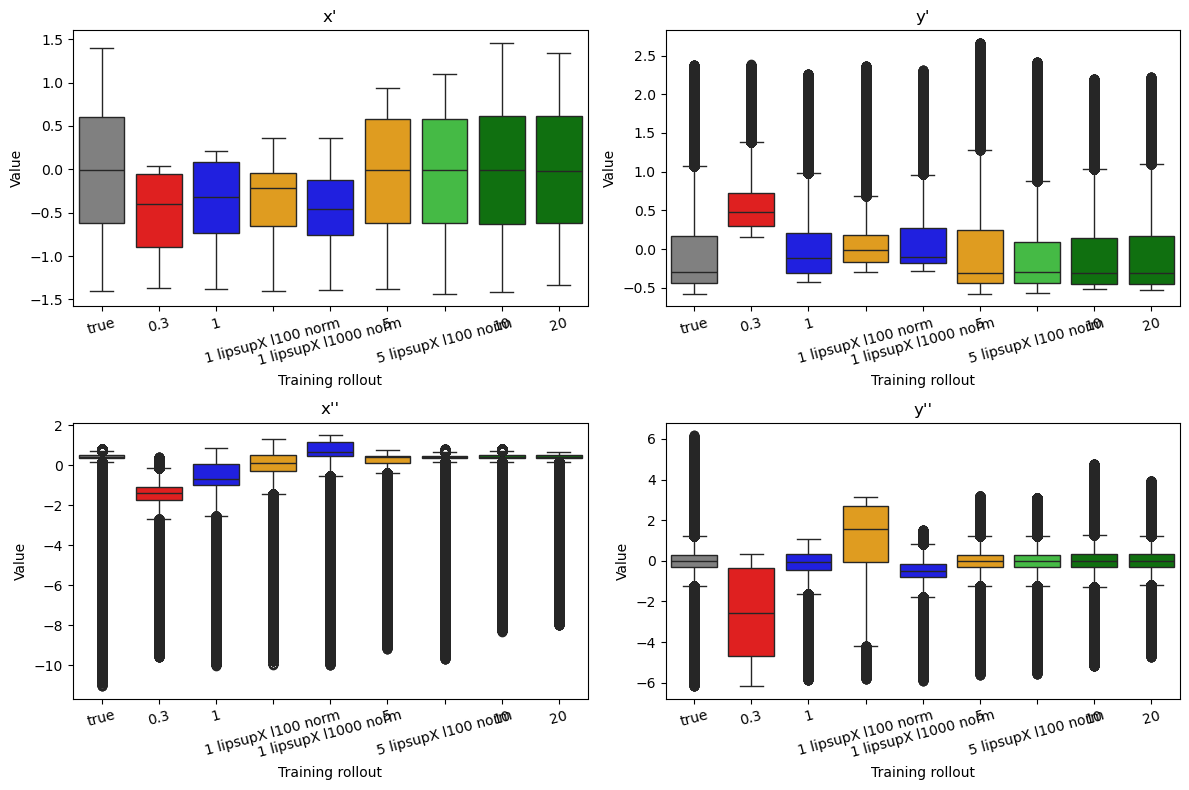

In [95]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
# Create one long DataFrame
df = pd.DataFrame({
    "true": Ftrue[:, 0],
    "0.3": Ftheta03[:, 0],
    "1": Ftheta1[:, 0],
    "1 lipsupX l100 norm": Ftheta1_lipsupX_l100_norm[:,0],
    "1 lipsupX l1000 norm": Ftheta1_lipsupX_l1000_norm[:,0],
    "5": Ftheta5[:, 0],
    #"5 lipsupX l100": Ftheta5_lipsupX_l100[:,0],
    "5 lipsupX l100 norm": Ftheta5_lipsupX_l100_norm[:,0],
    "10": Ftheta10[:, 0],
    "20": Ftheta20[:,0]
})
df['variable'] = "x'"  # First dimension

for i, label in zip([1, 2, 3], ["y'", "x''", "y''"]):
    temp_df = pd.DataFrame({
        "true": Ftrue[:, i],
        "0.3": Ftheta03[:, i],
        "1": Ftheta1[:, i],
        "1 lipsupX l100 norm": Ftheta1_lipsupX_l100_norm[:,i],
        "1 lipsupX l1000 norm": Ftheta1_lipsupX_l1000_norm[:,i],
        "5": Ftheta5[:, i],
        #"5 lipsupX l100": Ftheta5_lipsupX_l100[:,i],
        "5 lipsupX l100 norm": Ftheta5_lipsupX_l100_norm[:,i],
        "10": Ftheta10[:, i],
        "20": Ftheta20[:,i]
    })
    temp_df['variable'] = label
    df = pd.concat([df, temp_df], ignore_index=True)

# Melt to long-form for seaborn
df_melted = df.melt(id_vars="variable", var_name="Training rollout", value_name="Value")

# Plot with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
titles = ["x'", "y'", "x''", "y''"]

for ax, title in zip(axes.flat, titles):
    sns.boxplot(
        data=df_melted[df_melted["variable"] == title],
        x="Training rollout",
        y="Value",
        ax=ax, 
        palette=palette
    )
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


/var/folders/hd/6gcp429169ldrntwtps0b1_m0000gp/T/ipykernel_5991/3719405733.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/hd/6gcp429169ldrntwtps0b1_m0000gp/T/ipykernel_5991/3719405733.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/hd/6gcp429169ldrntwtps0b1_m0000gp/T/ipykernel_5991/3719405733.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/hd/6gcp429169ldrntwtps0b1_m0000gp/T/ipykernel_5991/3719405733.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and w

<Figure size 1000x600 with 0 Axes>

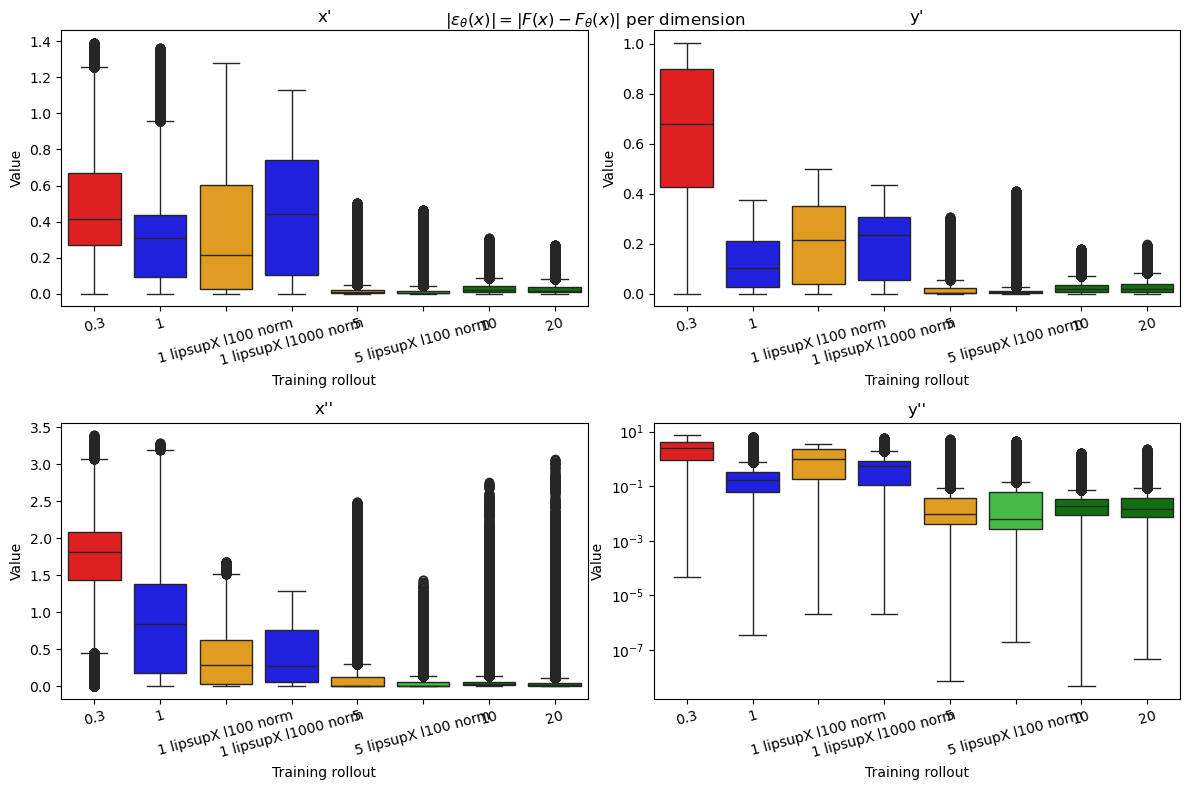

In [104]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
# Create one long DataFrame
palette = ["red", "blue", "orange", "blue", "orange", "limegreen", "green", "green" ]

df = pd.DataFrame({
    #"true": Ftrue[:, 0],
    "0.3": np.abs(Ftrue[:,0]-Ftheta03[:, 0]),
    "1": np.abs(Ftrue[:,0]-Ftheta1[:, 0]),
    "1 lipsupX l100 norm": np.abs(Ftrue[:,0]-Ftheta1_lipsupX_l100_norm[:,0]),
    "1 lipsupX l1000 norm": np.abs(Ftrue[:,0]-Ftheta1_lipsupX_l1000_norm[:,0]),
    "5": np.abs(Ftrue[:,0]-Ftheta5[:, 0]),
    #"5 lipsupX l100": Ftheta5_lipsupX_l100[:,0],
    "5 lipsupX l100 norm": np.abs(Ftrue[:,0]-Ftheta5_lipsupX_l100_norm[:,0]),
    "10": np.abs(Ftrue[:,0]-Ftheta10[:, 0]),
    "20": np.abs(Ftrue[:,0]-Ftheta20[:,0])
})
df['variable'] = "x'"  # First dimension

for i, label in zip([1, 2, 3], ["y'", "x''", "y''"]):
    temp_df = pd.DataFrame({
        #"true": Ftrue[:, i],
        "0.3": np.abs(Ftrue[:,i]-Ftheta03[:, i]),
        "1": np.abs(Ftrue[:,i]-Ftheta1[:, i]),
        "1 lipsupX l100 norm": np.abs(Ftrue[:,i]-Ftheta1_lipsupX_l100_norm[:,i]),
        "1 lipsupX l1000 norm": np.abs(Ftrue[:,i]-Ftheta1_lipsupX_l1000_norm[:,i]),
        "5": np.abs(Ftrue[:,i]-Ftheta5[:, i]),
        #"5 lipsupX l100": Ftheta5_lipsupX_l100[:,i],
        "5 lipsupX l100 norm": np.abs(Ftrue[:,i]-Ftheta5_lipsupX_l100_norm[:,i]),
        "10": np.abs(Ftrue[:,i]-Ftheta10[:, i]),
        "20": np.abs(Ftrue[:,i]-Ftheta20[:,i])
    })
    temp_df['variable'] = label
    df = pd.concat([df, temp_df], ignore_index=True)

# Melt to long-form for seaborn
df_melted = df.melt(id_vars="variable", var_name="Training rollout", value_name="Value")

# Plot with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
titles = ["x'", "y'", "x''", "y''"]

for ax, title in zip(axes.flat, titles):
    sns.boxplot(
        data=df_melted[df_melted["variable"] == title],
        x="Training rollout",
        y="Value",
        ax=ax, 
        palette=palette
    )
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.suptitle(r"$|\epsilon_\theta(x)|=|F(x)-F_\theta(x)|$ per dimension")
plt.yscale('log')
plt.show()


/var/folders/hd/6gcp429169ldrntwtps0b1_m0000gp/T/ipykernel_84610/1600823529.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/hd/6gcp429169ldrntwtps0b1_m0000gp/T/ipykernel_84610/1600823529.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/hd/6gcp429169ldrntwtps0b1_m0000gp/T/ipykernel_84610/1600823529.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/hd/6gcp429169ldrntwtps0b1_m0000gp/T/ipykernel_84610/1600823529.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated a

<Figure size 1000x600 with 0 Axes>

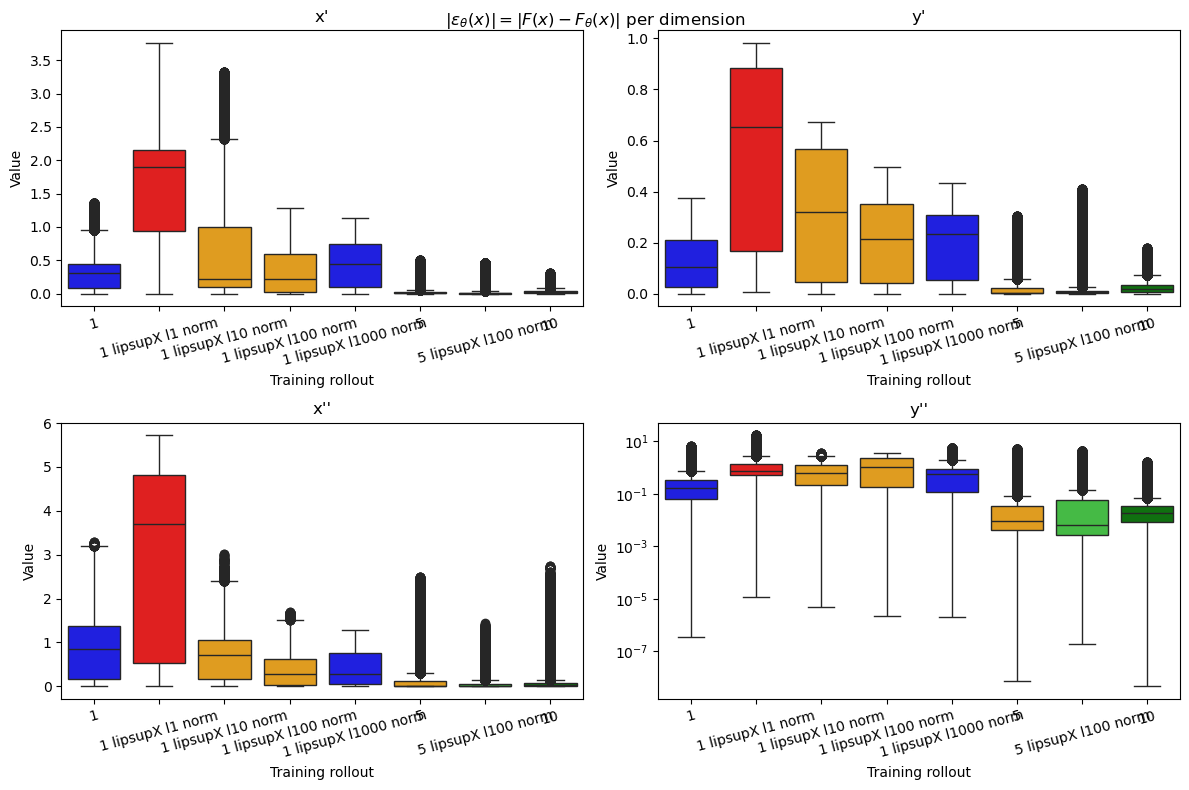

In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
# Create one long DataFrame
palette = [ "blue", "red",  "orange", "orange", "blue", "orange", "limegreen", "green"]
#palette = ["red", "blue", "orange", "blue", "orange", "limegreen", "green", "green" ]

df = pd.DataFrame({
    #"true": Ftrue[:, 0],
    #"0.3": np.abs(Ftrue[:,0]-Ftheta03[:, 0]),
    "1": np.abs(Ftrue[:,0]-Ftheta1[:, 0]),
    "1 lipsupX l1 norm": np.abs(Ftrue[:,0]-Ftheta1_lipsupX_l1_norm[:,0]),
    "1 lipsupX l10 norm": np.abs(Ftrue[:,0]-Ftheta1_lipsupX_l10_norm[:,0]),
    "1 lipsupX l100 norm": np.abs(Ftrue[:,0]-Ftheta1_lipsupX_l100_norm[:,0]),
    "1 lipsupX l1000 norm": np.abs(Ftrue[:,0]-Ftheta1_lipsupX_l1000_norm[:,0]),
    "5": np.abs(Ftrue[:,0]-Ftheta5[:, 0]),
    #"5 lipsupX l100": Ftheta5_lipsupX_l100[:,0],
    "5 lipsupX l100 norm": np.abs(Ftrue[:,0]-Ftheta5_lipsupX_l100_norm[:,0]),
    "10": np.abs(Ftrue[:,0]-Ftheta10[:, 0]),
    #"20": np.abs(Ftrue[:,0]-Ftheta20[:,0])
})
df['variable'] = "x'"  # First dimension

for i, label in zip([1, 2, 3], ["y'", "x''", "y''"]):
    temp_df = pd.DataFrame({
        #"true": Ftrue[:, i],
        #"0.3": np.abs(Ftrue[:,i]-Ftheta03[:, i]),
        "1": np.abs(Ftrue[:,i]-Ftheta1[:, i]),
        "1 lipsupX l1 norm": np.abs(Ftrue[:,i]-Ftheta1_lipsupX_l1_norm[:,i]),
        "1 lipsupX l10 norm": np.abs(Ftrue[:,i]-Ftheta1_lipsupX_l10_norm[:,i]),
        "1 lipsupX l100 norm": np.abs(Ftrue[:,i]-Ftheta1_lipsupX_l100_norm[:,i]),
        "1 lipsupX l1000 norm": np.abs(Ftrue[:,i]-Ftheta1_lipsupX_l1000_norm[:,i]),
        "5": np.abs(Ftrue[:,i]-Ftheta5[:, i]),
        #"5 lipsupX l100": Ftheta5_lipsupX_l100[:,i],
        "5 lipsupX l100 norm": np.abs(Ftrue[:,i]-Ftheta5_lipsupX_l100_norm[:,i]),
        "10": np.abs(Ftrue[:,i]-Ftheta10[:, i]),
        #"20": np.abs(Ftrue[:,i]-Ftheta20[:,i])
    })
    temp_df['variable'] = label
    df = pd.concat([df, temp_df], ignore_index=True)

# Melt to long-form for seaborn
df_melted = df.melt(id_vars="variable", var_name="Training rollout", value_name="Value")

# Plot with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
titles = ["x'", "y'", "x''", "y''"]

for ax, title in zip(axes.flat, titles):
    sns.boxplot(
        data=df_melted[df_melted["variable"] == title],
        x="Training rollout",
        y="Value",
        ax=ax, 
        palette=palette
    )
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.suptitle(r"$|\epsilon_\theta(x)|=|F(x)-F_\theta(x)|$ per dimension")
plt.yscale('log')
plt.show()


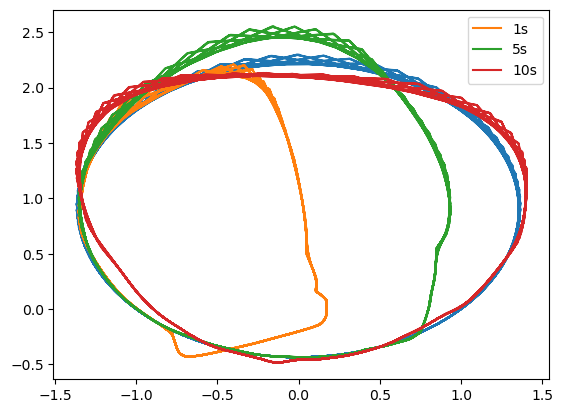

In [171]:
Ftrue_reshape = Ftrue.reshape(200,1001,4)
plt.plot(Ftrue_reshape[0,:,0], Ftrue_reshape[0,:,1])
plt.plot(Ftheta1.reshape(200,1001,4)[0,:,0], Ftheta1.reshape(200,1001,4)[0,:,1], label="1s")
plt.plot(Ftheta5.reshape(200,1001,4)[0,:,0], Ftheta5.reshape(200,1001,4)[0,:,1], label="5s")
plt.plot(Ftheta10.reshape(200,1001,4)[0,:,0], Ftheta10.reshape(200,1001,4)[0,:,1], label="10s")
plt.legend()
#plt.plot(Ftheta1_lipsupX_l10_norm.reshape(200,1001,4)[0,:,0],Ftheta1_lipsupX_l10_norm.reshape(200,1001,4)[0,:,1])
#plt.plot(Ftheta1_lipsupX_l100_norm.reshape(200,1001,4)[0,:,0],Ftheta1_lipsupX_l100_norm.reshape(200,1001,4)[0,:,1])
#plt.plot(Ftheta1_lipsupX_l1000_norm.reshape(200,1001,4)[0,:,0],Ftheta1_lipsupX_l1000_norm.reshape(200,1001,4)[0,:,1])

#plt.plot(Ftheta1_lipsupX_l10t1_norm.reshape(200,1001,4)[0,:,0],Ftheta1_lipsupX_l10t1_norm.reshape(200,1001,4)[0,:,1])

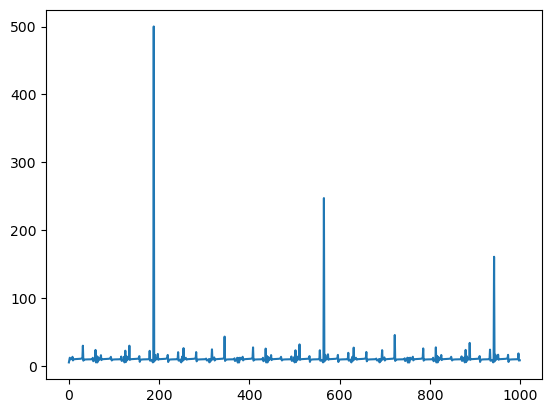

In [177]:
plt.plot(np.abs(Ftrue_reshape[0,1:] - Ftrue_reshape[0,:-1]/np.abs((data_none_aug1["y_true"][0][:,1:]-data_none_aug1["y_true"][0][:,:-1]).T)).mean(axis=1))

In [175]:
(Ftrue_reshape[0,1:] - Ftrue_reshape[0,:-1]).shape, (data_none_aug1["y_true"][0][:,1:]-data_none_aug1["y_true"][0][:,:-1]).shape

((1000, 4), (4, 1000))

In [72]:
# reshape all
def reshape_F(F):
    return(F.reshape(200,1001,4))
Ftheta1_reshape = reshape_F(Ftheta1)
Ftheta10_reshape = reshape_F(Ftheta10)
Ftheta5_reshape = reshape_F(Ftheta5)
Ftheta5_lipsupX_l100_norm_reshape = reshape_F(Ftheta5_lipsupX_l100_norm)

In [50]:
for i in range(4):
    print("theta 1:", i, np.abs(Ftrue_reshape[:,:11,i]-Ftheta1_reshape[:,:11, i]).mean(),np.abs(Ftrue_reshape[:,:,i]-Ftheta1_reshape[:,:, i]).mean())
    print("theta 5:", i, np.abs(Ftrue_reshape[:,:11,i]-Ftheta5_reshape[:,:11, i]).mean(),np.abs(Ftrue_reshape[:,:,i]-Ftheta5_reshape[:,:, i]).mean())
    print("theta 10:", i, np.abs(Ftrue_reshape[:,:11,i]-Ftheta10_reshape[:,:11, i]).mean(),np.abs(Ftrue_reshape[:,:,i]-Ftheta10_reshape[:,:, i]).mean())

theta 1: 0 0.03459928 0.3697884
theta 5: 0 0.019065661 0.054485954
theta 10: 0 0.07292941 0.03312349
theta 1: 1 0.014334859 0.12423774
theta 5: 1 0.03521043 0.02681143
theta 10: 1 0.03696719 0.023242395
theta 1: 2 0.06284511 0.86032957
theta 5: 2 0.12100844 0.19125435
theta 10: 2 0.2592411 0.0792408
theta 1: 3 0.17993632 0.37010732
theta 5: 3 0.14891104 0.12188018
theta 10: 3 0.10895458 0.052503183


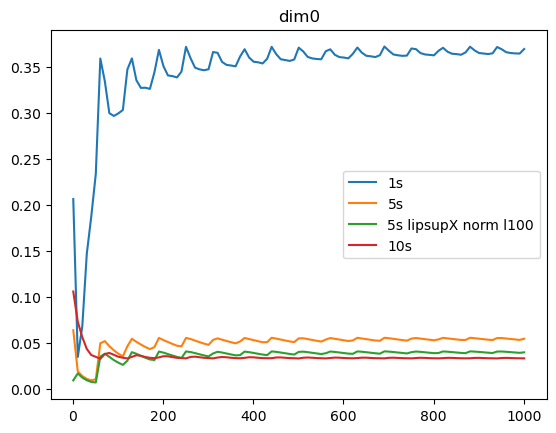

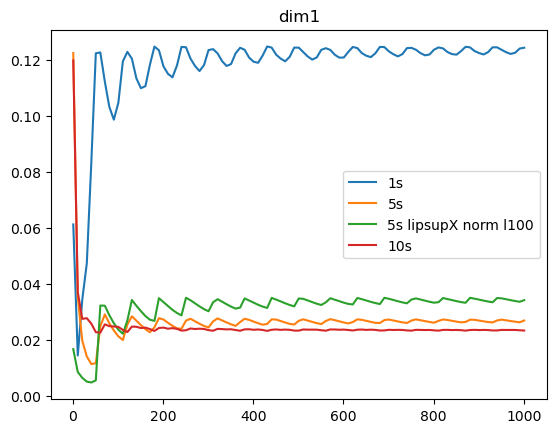

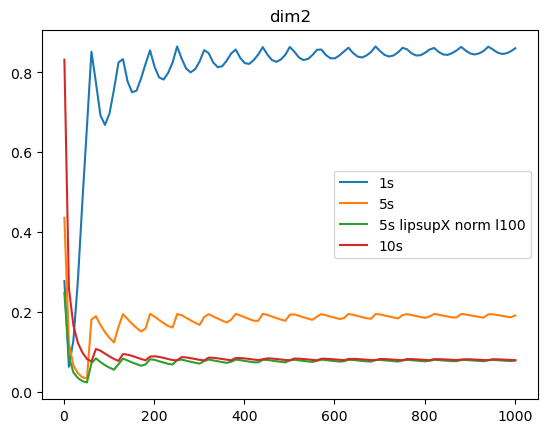

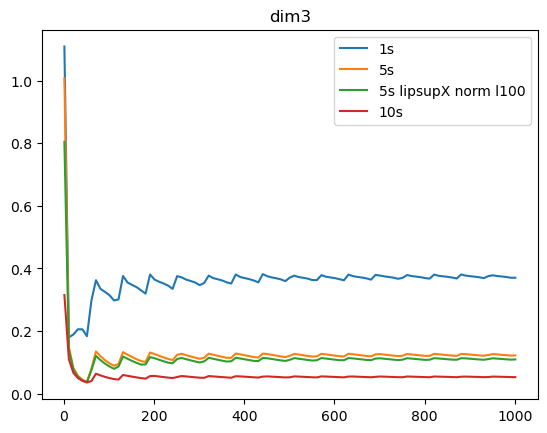

In [73]:
steps = np.arange(1,1002,10)
for i in range(4):
    plt.figure()
    plt.title(f"dim{i}")
    plt.plot(steps,[np.abs(Ftrue_reshape[:,:time,i]-Ftheta1_reshape[:,:time, i]).mean() for time in steps], label=f"1s")
    plt.plot(steps,[np.abs(Ftrue_reshape[:,:time,i]-Ftheta5_reshape[:,:time, i]).mean() for time in steps], label=f"5s")
    plt.plot(steps,[np.abs(Ftrue_reshape[:,:time,i]-Ftheta5_lipsupX_l100_norm_reshape[:,:time, i]).mean() for time in steps], label=f"5s lipsupX norm l100")
    plt.plot(steps,[np.abs(Ftrue_reshape[:,:time,i]-Ftheta10_reshape[:,:time, i]).mean() for time in steps], label=f"10s")
    plt.legend()

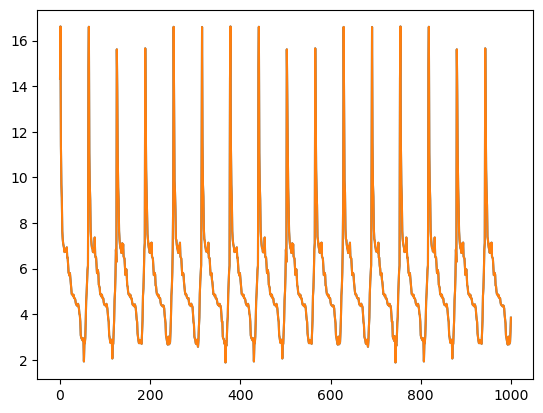

In [68]:
plt.plot(jacs_none_aug1.reshape(200,1001)[0,:])
plt.plot(jacs_none_aug1[:1001])

In [74]:
jacs_none_aug1_reshape = jacs_none_aug1.reshape(200,1001)
jacs_none_aug5_reshape = jacs_none_aug5.reshape(200,1001)
jacs_none_aug10_reshape = jacs_none_aug10.reshape(200,1001)
jacs_true_reshape = jacs_true.reshape(200,1001)
jacs_lipsupX5_l100_norm_reshape = jacs_none_aug5_l100_norm.reshape(200,1001)

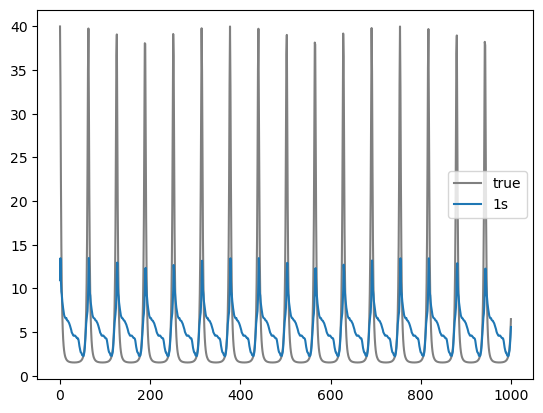

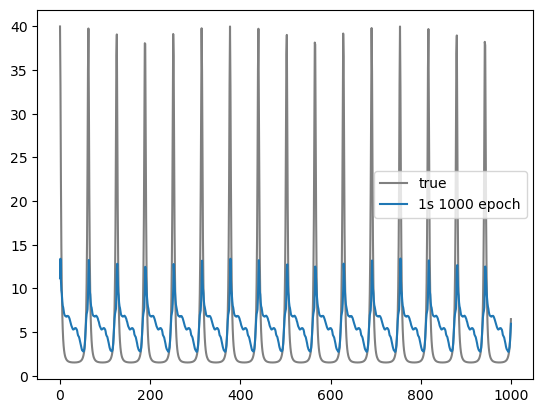

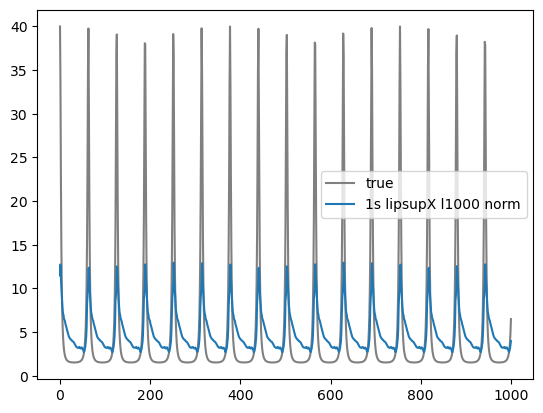

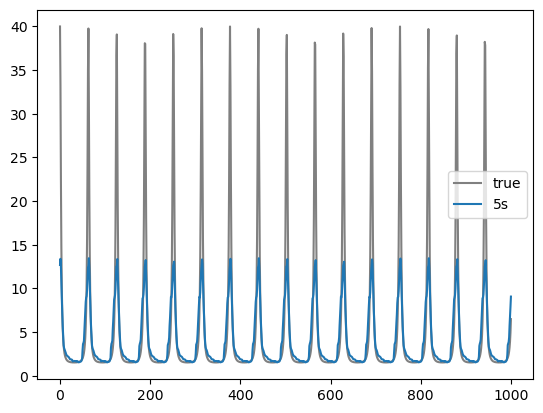

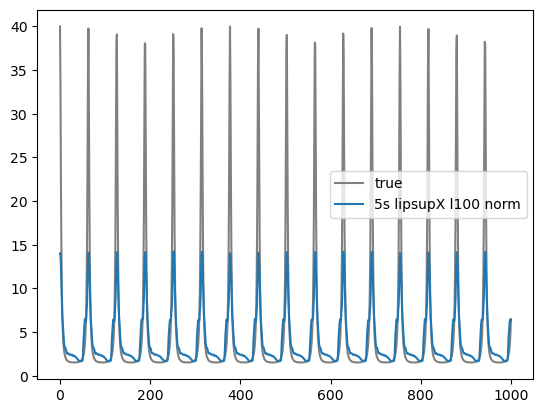

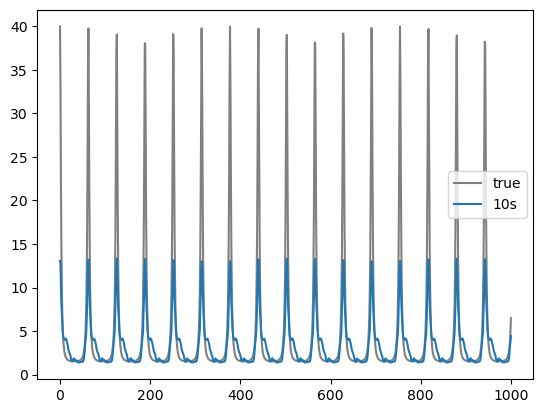

In [120]:
labels = ["1s","1s 1000 epoch", "1s lipsupX l1000 norm", "5s", "5s lipsupX l100 norm","10s"]
for k, jacs in enumerate([jacs_none_aug1_reshape, jacs_none_aug1_epoch.reshape(200,1001), jacs_none_aug1_l1000_norm.reshape(200,1001), jacs_none_aug5_reshape,jacs_lipsupX5_l100_norm_reshape, jacs_none_aug10_reshape]):
    plt.figure()
    plt.plot(jacs_true_reshape.mean(axis=0), label="true", color="grey")
    plt.plot(jacs.mean(axis=0), label=labels[k])
    #plt.plot(jacs_none_aug5_reshape.mean(axis=0), label="5s")
    #plt.plot(jacs_lipsupX5_l100_norm_reshape.mean(axis=0), label="5s lipsupX l100 norm")
    #plt.plot(jacs_none_aug10_reshape.mean(axis=0), label="10s")
    plt.legend()

In [91]:
jacs_none_aug1_reshape.mean()

Array(5.48988, dtype=float32)

/var/folders/hd/6gcp429169ldrntwtps0b1_m0000gp/T/ipykernel_84610/2826351115.py:3: RuntimeWarning: overflow encountered in exp
  plt.plot(steps,[np.abs(Ftrue_reshape[:,:time,:]-Ftheta5_reshape[:,:time, :]).mean()*(np.exp(jacs_none_aug5_reshape.mean()*(time*0.1))) for time in steps], label=f"5s")
/var/folders/hd/6gcp429169ldrntwtps0b1_m0000gp/T/ipykernel_84610/2826351115.py:4: RuntimeWarning: overflow encountered in exp
  plt.plot(steps,[np.abs(Ftrue_reshape[:,:time,:]-Ftheta5_lipsupX_l100_norm_reshape[:,:time, :]).mean()*(np.exp(jacs_lipsupX5_l100_norm_reshape.mean()*(time*0.1))) for time in steps], label=f"5s lipsupX norm l100")
/var/folders/hd/6gcp429169ldrntwtps0b1_m0000gp/T/ipykernel_84610/2826351115.py:5: RuntimeWarning: overflow encountered in exp
  plt.plot(steps,[np.abs(Ftrue_reshape[:,:time,:]-Ftheta10_reshape[:,:time, :]).mean()*(np.exp(jacs_none_aug10_reshape.mean()*(time*0.1))) for time in steps], label=f"10s")


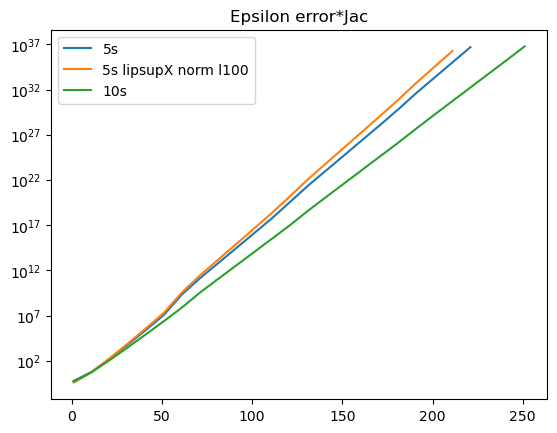

In [98]:
plt.figure()
#plt.plot(steps,[np.abs(Ftrue_reshape[:,:time,:]-Ftheta1_reshape[:,:time, :]).mean()*(np.exp(jacs_none_aug1_reshape.mean()*(time*0.1))) for time in steps], label=f"1s")
plt.plot(steps,[np.abs(Ftrue_reshape[:,:time,:]-Ftheta5_reshape[:,:time, :]).mean()*(np.exp(jacs_none_aug5_reshape.mean()*(time*0.1))) for time in steps], label=f"5s")
plt.plot(steps,[np.abs(Ftrue_reshape[:,:time,:]-Ftheta5_lipsupX_l100_norm_reshape[:,:time, :]).mean()*(np.exp(jacs_lipsupX5_l100_norm_reshape.mean()*(time*0.1))) for time in steps], label=f"5s lipsupX norm l100")
plt.plot(steps,[np.abs(Ftrue_reshape[:,:time,:]-Ftheta10_reshape[:,:time, :]).mean()*(np.exp(jacs_none_aug10_reshape.mean()*(time*0.1))) for time in steps], label=f"10s")
plt.legend()
plt.title("Epsilon error*Jac")
plt.yscale("log")

Text(0.5, 1.0, 'Epsilon error')

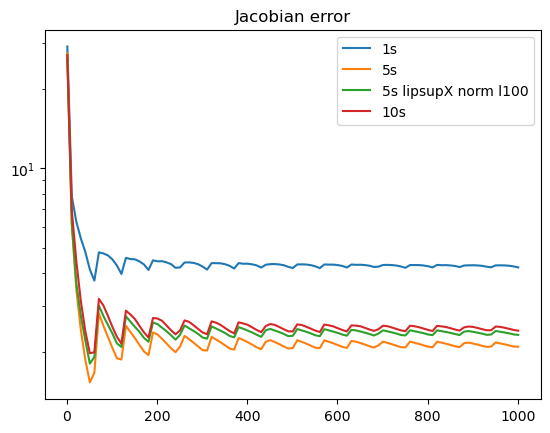

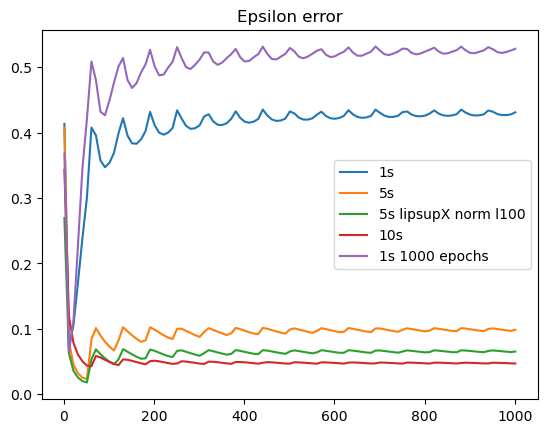

In [121]:
steps = np.arange(1,1002,10)

plt.plot(steps,[np.abs(jacs_true_reshape[:,:time]-jacs_none_aug1_reshape[:,:time]).mean() for time in steps], label=f"1s")
plt.plot(steps,[np.abs(jacs_true_reshape[:,:time]-jacs_none_aug5_reshape[:,:time]).mean() for time in steps], label=f"5s")
plt.plot(steps,[np.abs(jacs_true_reshape[:,:time]-jacs_lipsupX5_l100_norm_reshape[:,:time]).mean() for time in steps], label=f"5s lipsupX norm l100")

plt.plot(steps,[np.abs(jacs_true_reshape[:,:time]-jacs_none_aug10_reshape[:,:time]).mean() for time in steps], label=f"10s")
plt.legend()
plt.yscale("log")
plt.title("Jacobian error")

plt.figure()
plt.plot(steps,[np.abs(Ftrue_reshape[:,:time,:]-Ftheta1_reshape[:,:time, :]).mean() for time in steps], label=f"1s")
plt.plot(steps,[np.abs(Ftrue_reshape[:,:time,:]-Ftheta5_reshape[:,:time, :]).mean() for time in steps], label=f"5s")
plt.plot(steps,[np.abs(Ftrue_reshape[:,:time,:]-Ftheta5_lipsupX_l100_norm_reshape[:,:time, :]).mean() for time in steps], label=f"5s lipsupX norm l100")
plt.plot(steps,[np.abs(Ftrue_reshape[:,:time,:]-Ftheta10_reshape[:,:time, :]).mean() for time in steps], label=f"10s")
plt.plot(steps,[np.abs(Ftrue_reshape[:,:time,:]-Ftheta1_epoch.reshape(200,1001,4)[:,:time, :]).mean() for time in steps], label=f"1s 1000 epochs")
plt.legend()
plt.title("Epsilon error")

In [54]:
[np.abs(Ftrue_reshape[:,:time,i]-Ftheta1_reshape[:,:time, i]).mean() for time in [11,51,101,1001]]

[0.17993632, 0.18333256, 0.31439033, 0.37010732]

In [25]:
for k in range(4):
    print(k)
    print("0.3:", np.mean(np.abs(Ftrue[:,k]-Ftheta03[:,k])))
    print("1:", np.mean(np.abs(Ftrue[:,k]-Ftheta1[:,k])))
    print("5:", np.mean(np.abs(Ftrue[:,k]-Ftheta5[:,k])))
    print("10:", np.mean(np.abs(Ftrue[:,k]-Ftheta10[:,k])))
    print("020:", np.mean(np.abs(Ftrue[:,k]-Ftheta20[:,k])))

0
0.3: 0.49085516
1: 0.3697884
5: 0.054485954
10: 0.03312349
020: 0.028872231
1
0.3: 0.628059
1: 0.12423774
5: 0.02681143
10: 0.023242395
020: 0.026857289
2
0.3: 1.6947618
1: 0.86032957
5: 0.19125435
10: 0.0792408
020: 0.07176504
3
0.3: 2.5538068
1: 0.37010732
5: 0.12188018
10: 0.052503183
020: 0.08288531


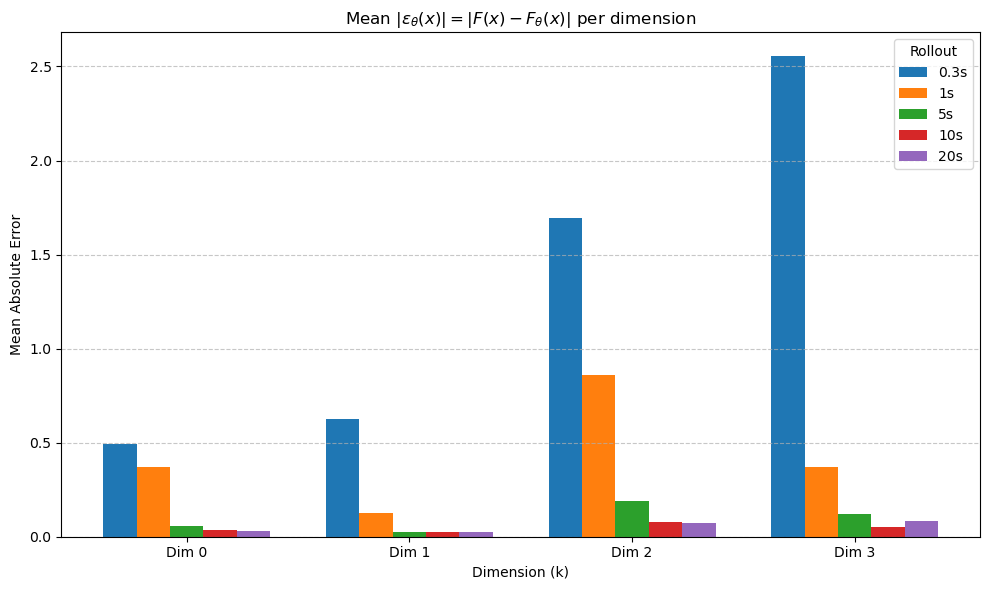

In [100]:
import numpy as np
import matplotlib.pyplot as plt

# Define data
dims = np.arange(4)  # Dimensions k = 0,1,2,3
theta_labels = ["0.3", "1", "5", "10", "20"]

# Compute errors
errors = {
    "0.3": [np.mean(np.abs(Ftrue[:,k] - Ftheta03[:,k])) for k in dims],
    "1":   [np.mean(np.abs(Ftrue[:,k] - Ftheta1[:,k]))  for k in dims],
    "5":   [np.mean(np.abs(Ftrue[:,k] - Ftheta5[:,k]))  for k in dims],
    "10":  [np.mean(np.abs(Ftrue[:,k] - Ftheta10[:,k])) for k in dims],
    "20":  [np.mean(np.abs(Ftrue[:,k] - Ftheta20[:,k])) for k in dims],
}

# Bar plot settings
bar_width = 0.15
offsets = np.linspace(-2, 2, len(theta_labels)) * bar_width

plt.figure(figsize=(10, 6))

for i, label in enumerate(theta_labels):
    plt.bar(dims + offsets[i], errors[label], width=bar_width, label=f"{label}s")

# Styling
plt.xlabel("Dimension (k)")
plt.ylabel("Mean Absolute Error")
plt.title(r"Mean $|\epsilon_\theta(x)|=|F(x)-F_\theta(x)|$ per dimension")
plt.xticks(dims, [f"Dim {k}" for k in dims])
plt.legend(title="Rollout")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Text(0.5, 1.0, 'y second')

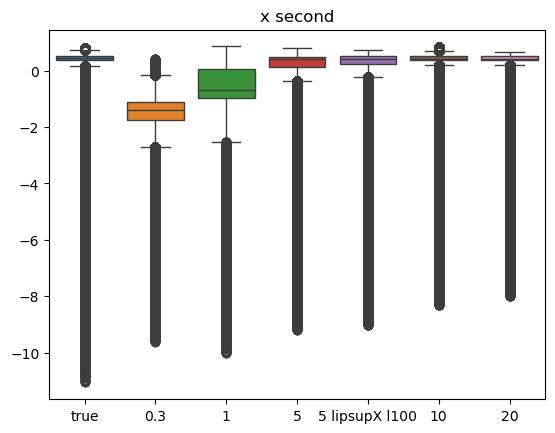

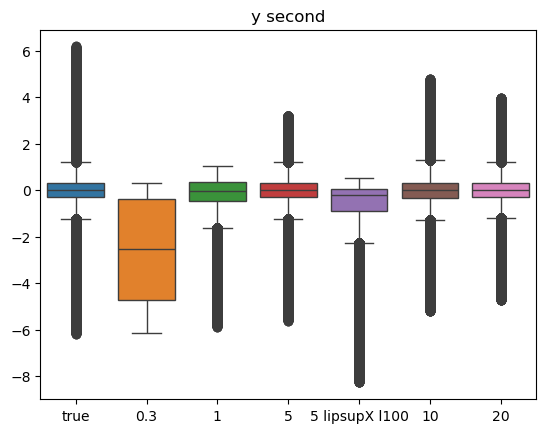

In [29]:
sns.boxplot(pd.DataFrame({
    "true": Ftrue[:,2],
    "0.3": Ftheta03[:,2],
    "1": Ftheta1[:,2],
    "5": Ftheta5[:,2],
    "5 lipsupX l100": Ftheta5_lipsupX_l100[:,2],
    "10": Ftheta10[:,2], 
    "20": Ftheta20[:,2]
}))

plt.title("x second")
plt.figure()

sns.boxplot(pd.DataFrame({
    "true": Ftrue[:,3],
    "0.3": Ftheta03[:,3],
    "1": Ftheta1[:,3],
    "5": Ftheta5[:,3],
    "5 lipsupX l100": Ftheta5_lipsupX_l100[:,3],
    "10": Ftheta10[:,3], 
    "20": Ftheta20[:,3]
}))

plt.title("y second")

## Impact of integration scheme on ground truth


In [7]:
from loss import F_twobody
from solvers.runge_kutta import *

In [8]:
def F_twobody(s,t):
    x,y, xprime, yprime = s
    x_second = -x/ (x**2 + y**2)**(3/2)
    y_second = -y/ (x**2 + y**2)**(3/2)
    return jnp.array([xprime, yprime, x_second,  y_second])


In [15]:
k=10
trajdt0_1,_,_,_ = RK_solver_fixed(F_twobody, data_none_aug1["y_true"][k][:,0], dt=0.1, num_steps=(100)/0.1, tableau=RK_tableaux["RK4"])
trajdt0_01,_,_,_ = RK_solver_fixed(F_twobody, data_none_aug1["y_true"][k][:,0], dt=0.01, num_steps=(100)/0.01, tableau=RK_tableaux["RK4"])

Text(0.5, 1.0, '100s Trajectory of Two-Body Problem')

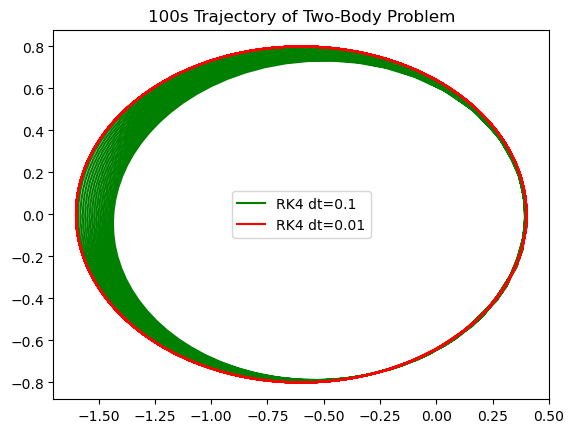

In [16]:
e=0.6
s0 = jnp.array([1-e,0,0, np.sqrt((1+e)/(1-e))])

trajdt0_1,_,_,_ = RK_solver_fixed(F_twobody, s0, dt=0.1, num_steps=(100)/0.1, tableau=RK_tableaux["RK4"])
trajdt0_01,_,_,_ = RK_solver_fixed(F_twobody, s0, dt=0.01, num_steps=(100)/0.01, tableau=RK_tableaux["RK4"])
#trajdopri5_0_1,_,_,_ = RK_solver_fixed(F_twobody, s0, dt=0.1, num_steps=(100)/0.1, tableau=RK_tableaux["DOPRI5"])
#trajdopri5_0_01,_,_,_ = RK_solver_fixed(F_twobody, s0, dt=0.01,  num_steps=(100)/0.01, tableau=RK_tableaux["DOPRI5"])
plt.plot(trajdt0_1[0,:], trajdt0_1[1,:], label='RK4 dt=0.1', color='green')
plt.plot(trajdt0_01[0,:], trajdt0_01[1,:], label='RK4 dt=0.01', color='red')
#plt.plot(trajdopri5_0_1, trajdopri5_0_1[1,:], label='dopri5 dt=0.1', color='blue')
#plt.plot(trajdopri5_0_01[0,:], trajdopri5_0_01[1,:], label='dopri5 dt=0.01', color='orange')

#plt.plot(data_none_aug1["y_true"][k][0,:], data_none_aug1["y_true"][k][2,:], label='True Trajectory', color='blue')
plt.legend()
plt.title("100s Trajectory of Two-Body Problem")

Clairement dt=0.1 pas assez stable pour nous pour le long terme (100s) -> 0.01

In [220]:
for i, batch in enumerate(test):
    print(batch["states"].shape)
    break

torch.Size([1, 4, 10001])


In [225]:
1001*0.1

100.10000000000001

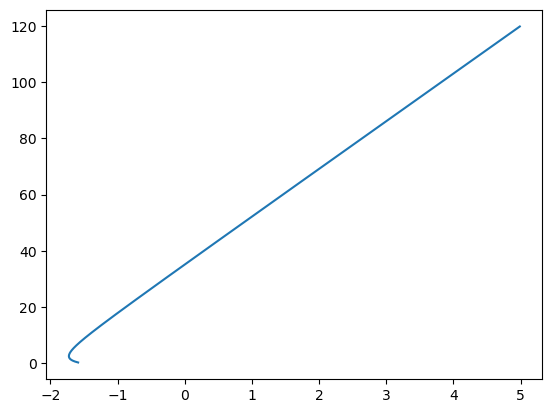

In [309]:
e=0.6
s0 = data_lipsupX1_l1000_norm["y_true"][0][:,87]+[0,0,0,2] #jnp.array([1-e,1,0, np.sqrt((1+e)/(1-e))])
traj,_,_,_ = RK_solver_fixed(F_twobody, s0, dt=0.01, num_steps=(100)/0.01, tableau=RK_tableaux["RK4"])
plt.plot(traj[0,:], traj[1,:])

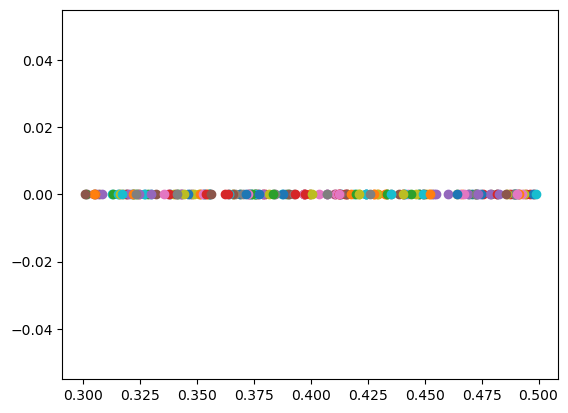

In [40]:
# init points
for k in range(200):
    plt.scatter(data_none_aug1["y_true"][k][0,0], data_none_aug1["y_true"][k][1,0])

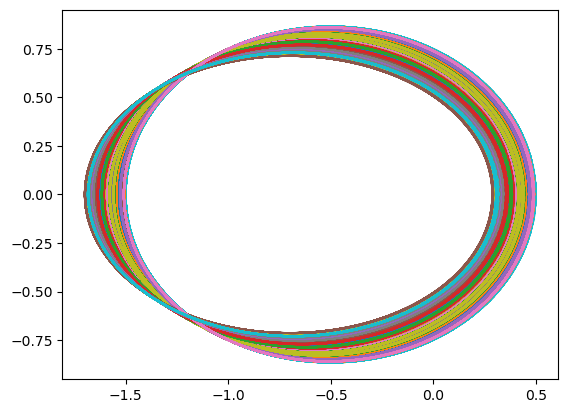

In [194]:
for k in range(200):
    plt.plot(data_none_aug1["y_true"][k][0,:], data_none_aug1["y_true"][k][1,:])

314
251
710
291
12
187
777
644
543
503
316
275
233
574
47
580
450
825
101
121
947
830
624
712
526
279
969
665
828
576
357
131
294
119
172
364
687
643
190
653
108
740
335
453
304
615
495
641
94
224
566
472
507
313
693
333
865
124
46
706
713
267
670
885
775
582
969
52
686
692
956
622
828
723
106
788
645
853
895
541
902
1000
668
638
608
754
760
121
551
430
413
334
142
827
580
15
437
748
215
659
122
821
833
797
901
670
50
460
744
773
183
860
411
984
165
872
598
48
964
585
797
433
816
987
592
113
974
688
252
294
819
975
269
867
989
741
773
442
777
347
127
382
525
465
561
174
239
244
769
118
30
742
339
347
201
831
977
740
103
868
417
531
143
242
391
183
854
392
665
338
427
904
402
452
726
488
427
868
495
209
357
246
726
178
299
139
501
29
519
283
561
637
521
73
678
359
120
242
563
221


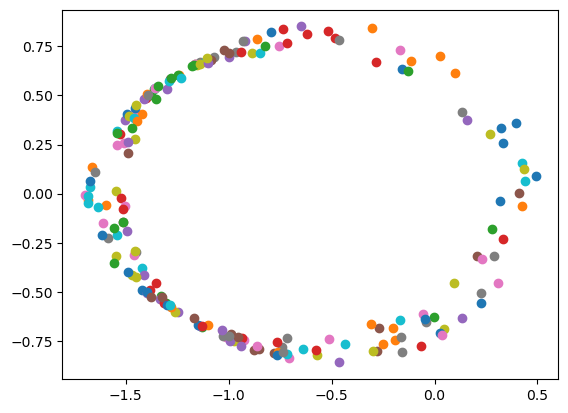

In [228]:
for k in range(200):
    key = int(np.random.uniform(0,1001))
    print(key)
    s0 =data_none_aug1["y_true"][k][:,key]
    plt.scatter(s0[0], s0[1])
    #plt.plot(data_none_aug1["y_true"][k][0,:], data_none_aug1["y_true"][k][1,:])

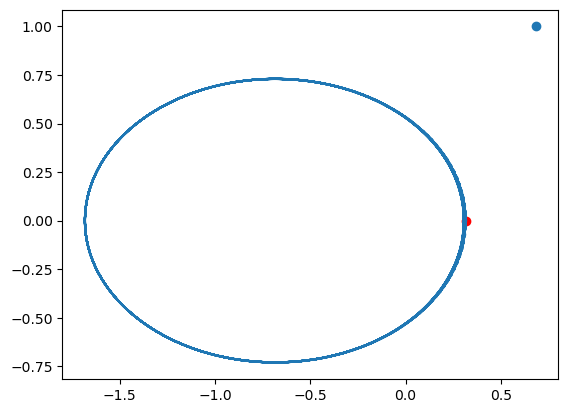

In [201]:
plt.plot(data_none_aug1["y_true"][k][0,:], data_none_aug1["y_true"][k][1,:])
plt.scatter(data_none_aug1["y_true"][k][0,0],data_none_aug1["y_true"][k][1,0], color="red")
e=1-data_none_aug1["y_true"][k][0,0]
e
plt.scatter(e, 1)

(array([336., 133., 101.,  81.,  69.,  61.,  54.,  49.,  44.,  73.]),
 array([-1.68283713, -1.48283751, -1.28283789, -1.08283827, -0.88283865,
        -0.68283904, -0.48283942, -0.2828398 , -0.08284018,  0.11715944,
         0.31715906]),
 <BarContainer object of 10 artists>)

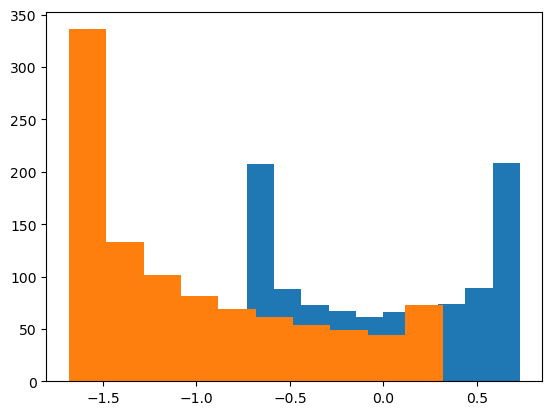

In [205]:
plt.hist(data_none_aug1["y_true"][k][1,:])
plt.hist(data_none_aug1["y_true"][k][0,:])

### Build init files
- get 10s trajectories (dt=0.01)
- sample dt=0.1
- get one point from each trajectiry randomly chosen
- save
- generate train/val/test trajectories from these points using dataloader

In [229]:
dataset_name = 'twobody'
data_path = './data/twobody_curriculum/'
data_integration_method = "RK4"
duration = 100
dt_num = 0.01
train, val, test = init_dataloaders(dataset_name, data_integration_method, os.path.join(data_path, dataset_name+str(duration)), dt_num=dt_num, duration=duration)


In [283]:
from jax import random
MAX = np.iinfo(np.int32).max
def get_init_points(data, type="train"):
    # sample dt=0.1 
    s0_list = []
    for i, batch in enumerate(data):
        trajectories = batch["states"][:,:,::10] # sample at dt=0.1 (dt_factor=10)
        if type in ["train", "val"]:
            for seed in range(trajectories.shape[0]):
                if type == "train":
                    key = random.PRNGKey(seed)
                elif type == "val":
                    key = random.PRNGKey(MAX//2 - seed)

                index = int(jax.random.randint(key, shape=(), minval=0, maxval=1001))
                s0 = trajectories[seed,:,index]
                s0_list.append(s0)

        elif type == "test":
            seed = i
            key = random.PRNGKey(MAX - seed)
            index = int(jax.random.randint(key, shape=(), minval=0, maxval=1001))
            s0 = trajectories[0,:,index]
            s0_list.append(s0)
    return(jnp.array(s0_list))



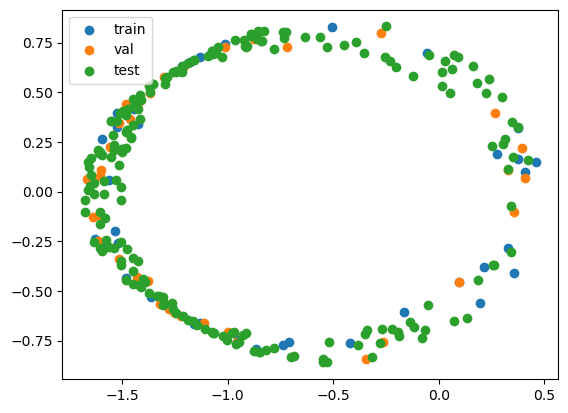

In [284]:
init_train = get_init_points(train, "train")
init_val = get_init_points(val, "val")
init_test = get_init_points(test, "test")
plt.scatter(init_train[:,0], init_train[:,1], label="train")
plt.scatter(init_val[:,0], init_val[:,1], label="val")
plt.scatter(init_test[:,0], init_test[:,1], label="test")
plt.legend()
#plt.scatter(init_train[:,2], init_train[:,3])

In [290]:
init_test[0]

Array([ 0.05175091,  0.49780497, -1.3589044 ,  1.0721397 ], dtype=float32)

In [289]:
# save init points
data_folder = "/Users/mayajanvier/jax-phynity/datasets"
np.save(data_folder+"/2body_init_test.npy", init_test)
np.save(data_folder+"/2body_init_train.npy", init_train)
np.save(data_folder+"/2body_init_val.npy", init_val)

# Impact of dt inference

In [19]:
def load_model_dt(model_name,exp_name, data_path, model_phy_option, model_aug_option, dataset_name, integration_method, dt,  data_integration_method="RK4", dt_num=0.5, duration=40):
    """Compute trajectory losses and Fa loss for a given model, on its duration of training data."""
    # load test data 
    _, _, test = init_dataloaders(dataset_name, data_integration_method, os.path.join(data_path, dataset_name+str(duration)+"_"+str(dt_num)), dt_num=dt_num, duration=duration)

    # load model
    model_path = os.path.join(data_path, f"{exp_name}/{model_name}")
    print(model_path)
    dt = dt
    dt_factor = int(dt/test.dataset.dt)
    print(dt, dt_factor)
    if dataset_name == 'pendulum':
        if model_phy_option == 'true': # true damped pendulum
            model_phy = PendulumParamPDE(is_damped=True, params=test.dataset.params, is_true=True)
        elif model_phy_option == 'complete': # damped pendulum
            model_phy = PendulumParamPDE(is_damped=True)
        else: 
            model_phy = PendulumParamPDE(is_damped=False)
    
        with open(model_path, "rb") as f:
            hyperparams = json.loads(f.readline().decode())
            mkey = jax.random.PRNGKey(0)
            model_aug = MLP(key=mkey, state_c=2, hidden=200)
            net = Forecaster(
                model_phy=model_phy,
                model_aug=model_aug,
                is_augmented=model_aug_option,
                is_phy=model_phy_option,
                dt=dt,
                num_steps=int(test.dataset.num_steps/dt_factor),
                integration_method=integration_method, # error scheme exp
            )
            model = eqx.tree_deserialise_leaves(f, net)
    elif dataset_name == "lorenz":
        model_phy = None # Neural ODE 
        with open(model_path, "rb") as f:
            hyperparams = json.loads(f.readline().decode())
            mkey, ikey = jax.random.split(jax.random.PRNGKey(0))
            model_aug = MLP(key=mkey, state_c=3, hidden=200)
            net = Forecaster(
                model_phy=model_phy,
                model_aug=model_aug,
                is_augmented=model_aug_option,
                is_phy=model_phy_option,
                dt=dt_factor * test.dataset.dt, # enabling comparison with GT for error scheme experiment 
                num_steps=int(test.dataset.num_steps / dt_factor), 
                integration_method=integration_method, # RK2 for error scheme experiment
            )
            model = eqx.tree_deserialise_leaves(f, net)
    elif dataset_name == "twobody":
        model_phy = None
        with open(model_path, "rb") as f:
            hyperparams = json.loads(f.readline().decode())
            mkey, ikey = jax.random.split(jax.random.PRNGKey(0))
            model_aug = MLP(key=mkey, state_c=4, hidden=200)
            net = Forecaster(
                model_phy=model_phy,
                model_aug=model_aug,
                is_augmented=model_aug_option,
                is_phy=model_phy_option,
                dt=dt_factor * test.dataset.dt, # enabling comparison with GT for error scheme experiment 
                num_steps=int(test.dataset.num_steps / dt_factor), 
                integration_method=integration_method, # RK2 for error scheme experiment
            )
            model = eqx.tree_deserialise_leaves(f, net)
    return model

In [38]:
model_lipsupX1_l10t1_norm_dt0001 = load_model_dt("model_9.140e-04.eqx", "none_Fa_prime_supX_aug_1.0_33_hve7onu4", data_path, "none", True, "twobody", "RK4", dt=0.001, dt_num=0.001, duration=100)
model_lipsupX1_l10t1_norm_dt001 = load_model_dt("model_9.140e-04.eqx", "none_Fa_prime_supX_aug_1.0_33_hve7onu4", data_path, "none", True, "twobody", "RK4", dt=0.01, dt_num=0.01, duration=100)


./data/twobody_curriculum/none_Fa_prime_supX_aug_1.0_33_hve7onu4/model_9.140e-04.eqx
0.001 1
./data/twobody_curriculum/none_Fa_prime_supX_aug_1.0_33_hve7onu4/model_9.140e-04.eqx
0.01 1


In [54]:
none_aug5_nocurr_dt001 = load_model_dt("model_4.262e-05.eqx", "none_aug_5.0_9_zg4ol5lo", data_path, "none", True, "twobody", "RK4", dt=0.01, dt_num=0.01, duration=100)
none_aug5_nocurr_dt0001 = load_model_dt("model_4.262e-05.eqx", "none_aug_5.0_9_zg4ol5lo", data_path, "none", True, "twobody", "RK4", dt=0.001, dt_num=0.001, duration=100)
none_aug5_nocurr_dt00001 = load_model_dt("model_4.262e-05.eqx", "none_aug_5.0_9_zg4ol5lo", data_path, "none", True, "twobody", "RK4", dt=0.0001, dt_num=0.0001, duration=20)

./data/twobody_curriculum/none_aug_5.0_9_zg4ol5lo/model_4.262e-05.eqx
0.01 1
./data/twobody_curriculum/none_aug_5.0_9_zg4ol5lo/model_4.262e-05.eqx
0.001 1
./data/twobody_curriculum/none_aug_5.0_9_zg4ol5lo/model_4.262e-05.eqx
0.0001 1


In [55]:
# out_dt0001 = model_lipsupX1_l10t1_norm_dt0001(data_none_aug1["y_true"][k][:,0])
# out_dt001 = model_lipsupX1_l10t1_norm_dt001(data_none_aug1["y_true"][k][:,0])

out_dt0001 = none_aug5_nocurr_dt0001(data_none_aug1["y_true"][k][:,0])
out_dt001 = none_aug5_nocurr_dt001(data_none_aug1["y_true"][k][:,0])
out_dt00001 = none_aug5_nocurr_dt00001(data_none_aug1["y_true"][k][:,0])

In [46]:
out_dt0001.shape

(4, 100001)

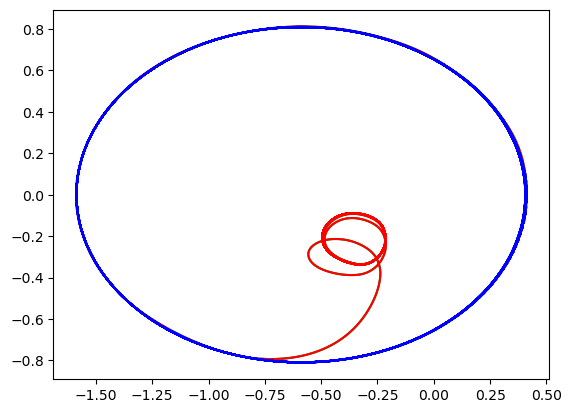

In [56]:
tlim = -1
plt.plot(out_dt0001[0,:tlim], out_dt0001[1,:tlim], label='lipsupX l1 norm dt=0.001', color='green')
plt.plot(out_dt001[0,:tlim], out_dt001[1,:tlim], label='lipsupX l1 norm dt=0.01', color='red')
#plt.plot(out_dt00001[0,:tlim], out_dt00001[1,:tlim], label='lipsupX l1 norm dt=0.0001', color='green')

plt.plot(data_none_aug1["y_true"][k][0,:tlim], data_none_aug1["y_true"][k][1,:tlim], label='True Trajectory', color='blue')